# Modelos Não-Supervisionados — Detecção de Anomalias 

Abordagem semi-supervisionada / detecção de anomalias:
- Treina **apenas** com conversas legítimas (label=0 / Ham).
- Detecta conversas de scam (label=1 / Scam) como anomalias ou *outliers*.
- Algoritmos sobre embeddings + PCA/UMAP: **OCSVM**, **Isolation Forest**, **LOF**, **LUNAR**, **Deep SVDD**.
- Algoritmos sobre texto bruto + BGE: **CVDD**, **DATE**.
- Avaliação em **todos os 5 embeddings**: `voyage`, `openai`, `bge`, `e5`, `minilm` (exceto CVDD/DATE, que usam somente `bge`).
- Split 3-way (`train`/`val`/`test`) dentro de `dataset_train` + validação externa (`dataset_validation`, "vida real") — ver `machine_learning/unsupervised/README.md`.
- Métricas principais: `accuracy`, `f1_macro`/`f1_scam`, `precision_scam`, `recall_scam`, `roc_auc`, `pr_auc`, `TP`/`TN`/`FP`/`FN`.
- Inclui **Estudo de Dimensionalidade (PCA)** variando de 25 a 1000 dimensões (seção 3).



In [1]:
import sys, os

# Localiza e adiciona o diretório 'backend' ao sys.path
notebook_dir = os.path.dirname(os.path.abspath('__file__')) if '__file__' in globals() else os.getcwd()
backend_dir = os.path.abspath(os.path.join(notebook_dir, '..')) if os.path.basename(notebook_dir) == 'notebooks' else notebook_dir
if not os.path.exists(os.path.join(backend_dir, 'machine_learning')):
    backend_dir = '/home/andrei.pinto/HorusEmbbedingPlusML/backend'

if backend_dir not in sys.path:
    sys.path.insert(0, backend_dir)

os.chdir(backend_dir)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from machine_learning import (
    train_anomaly,
    train_all_anomaly,
    compare_dimensions_anomaly,
    grid_search_anomaly,
    learning_curve_anomaly,
    train_cvdd,
    train_date,
    load_ham_only,
    load_single_embedding,
    plot_umap_2d,
    plot_pca_variance,
    plot_dimension_study,
)

EMBEDDINGS = ["voyage", "openai", "bge", "e5", "minilm"]
DIMENSIONS_TEST = [25, 60, 100, 150, 200, 250, 300, 500, 750, 1000]
PATH_DATA = "all_data"

# Controle de execução: False reutiliza o cache; True força o treinamento/tuning.
FORCE_RETRAIN = False
FORCE_GRID_SEARCH = False


## 1. Exploração Visual — UMAP (Todos os Embeddings)

/home/andrei.pinto/miniconda3/envs/env_py_3_12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[data] Carregando: voyage_chunks.parquet
  [data] Filtro sem augmentação -> 6822 amostras.
  [data] Shape: X=(6822, 1024), y=(6822,)


/home/andrei.pinto/miniconda3/envs/env_py_3_12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[data] Carregando: openai_chunks.parquet
  [data] Filtro sem augmentação -> 6822 amostras.
  [data] Shape: X=(6822, 3072), y=(6822,)


/home/andrei.pinto/miniconda3/envs/env_py_3_12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


...

/home/andrei.pinto/miniconda3/envs/env_py_3_12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[data] Carregando: e5_chunks.parquet
  [data] Filtro sem augmentação -> 6822 amostras.
  [data] Shape: X=(6822, 1024), y=(6822,)


/home/andrei.pinto/miniconda3/envs/env_py_3_12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[data] Carregando: minilm_chunks.parquet
  [data] Filtro sem augmentação -> 6822 amostras.
  [data] Shape: X=(6822, 384), y=(6822,)


/home/andrei.pinto/miniconda3/envs/env_py_3_12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


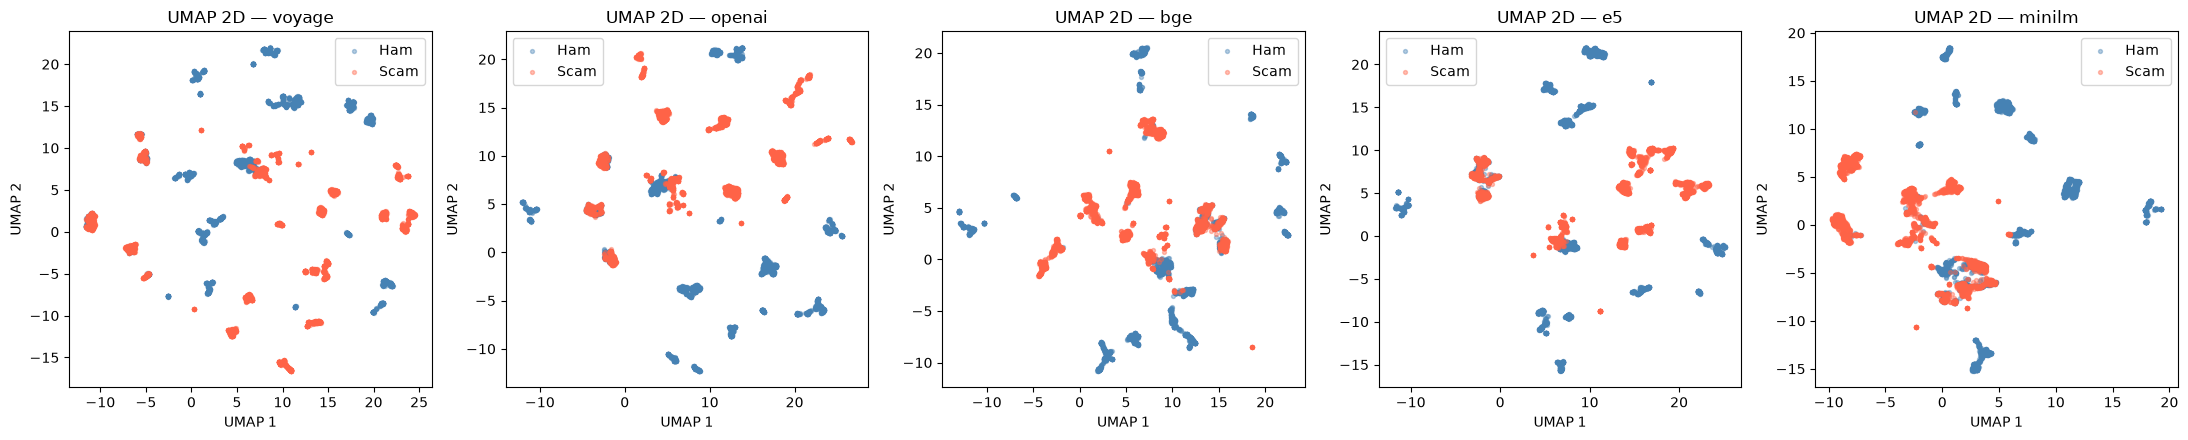

In [2]:
# Visualização UMAP 2D para entender a separabilidade Ham vs Scam em cada embedding
import umap

fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))
for i, emb in enumerate(EMBEDDINGS):
    X_tr, y_tr = load_single_embedding("train", PATH_DATA, emb, with_augmented=False)
    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
    coords = reducer.fit_transform(X_tr)
    ax = axes[i]
    plot_umap_2d(coords, y_tr, title=f"UMAP 2D — {emb}", ax=ax)

plt.tight_layout()
plt.show()


## 2. Análise de Variância PCA (Todos os Embeddings)

[data] Carregando: voyage_chunks.parquet


  [data] Filtro sem augmentação -> 6822 amostras.
  [data] Filtro label=0 -> 3228 amostras.
  [data] Shape: X=(3228, 1024), y=(3228,)
[data] Carregando: openai_chunks.parquet
  [data] Filtro sem augmentação -> 6822 amostras.
  [data] Filtro label=0 -> 3228 amostras.
  [data] Shape: X=(3228, 3072), y=(3228,)
[data] Carregando: bge_chunks.parquet
  [data] Filtro sem augmentação -> 6822 amostras.
  [data] Filtro label=0 -> 3228 amostras.
  [data] Shape: X=(3228, 1024), y=(3228,)
[data] Carregando: e5_chunks.parquet
  [data] Filtro sem augmentação -> 6822 amostras.
  [data] Filtro label=0 -> 3228 amostras.
  [data] Shape: X=(3228, 1024), y=(3228,)
[data] Carregando: minilm_chunks.parquet
  [data] Filtro sem augmentação -> 6822 amostras.
  [data] Filtro label=0 -> 3228 amostras.
  [data] Shape: X=(3228, 384), y=(3228,)


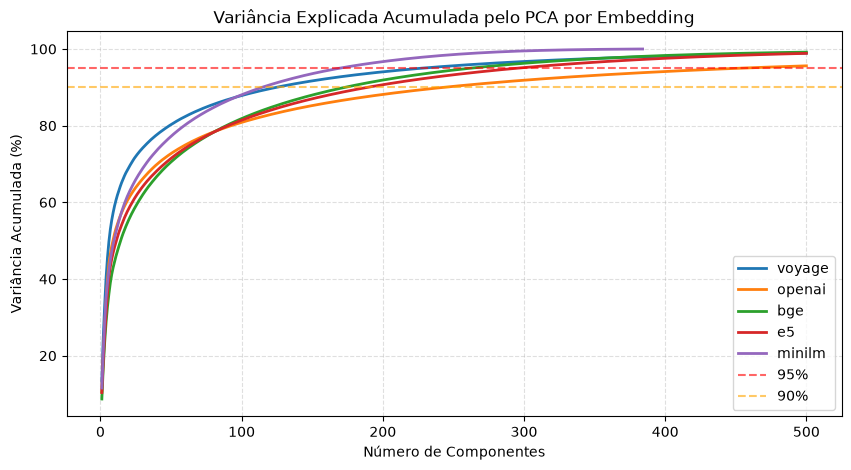

In [3]:
# Analisa a variância explicada acumulada do PCA para cada embedding
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

plt.figure(figsize=(10, 5))
for emb in EMBEDDINGS:
    X_ham = load_ham_only("train", PATH_DATA, emb)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_ham)
    pca = PCA(n_components=min(500, X_scaled.shape[1]), random_state=42)
    pca.fit(X_scaled)
    cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
    plt.plot(range(1, len(cumvar) + 1), cumvar, label=emb, lw=2)

plt.axhline(95, color="red", linestyle="--", alpha=0.6, label="95%")
plt.axhline(90, color="orange", linestyle="--", alpha=0.6, label="90%")
plt.title("Variância Explicada Acumulada pelo PCA por Embedding")
plt.xlabel("Número de Componentes")
plt.ylabel("Variância Acumulada (%)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


## 3. Estudo de Dimensionalidade (PCA vs Desempenho)

Avaliação do impacto da redução de dimensionalidade (de 25 a 1000 dimensões) no desempenho dos algoritmos OCSVM e Isolation Forest para todos os embeddings.

[unsupervised] Cache hit: voyage_ocsvm_25 (params=default)
[cache] Carregando OCSVM + PCA (25d): voyage
[unsupervised] Cache hit: voyage_ocsvm_60 (params=default)
[cache] Carregando OCSVM + PCA (60d): voyage
[unsupervised] Cache hit: voyage_ocsvm_100 (params=default)
[cache] Carregando OCSVM + PCA (100d): voyage
[unsupervised] Cache hit: voyage_ocsvm_150 (params=default)
[cache] Carregando OCSVM + PCA (150d): voyage
[unsupervised] Cache hit: voyage_ocsvm_200 (params=default)
[cache] Carregando OCSVM + PCA (200d): voyage
[unsupervised] Cache hit: voyage_ocsvm_250 (params=default)
[cache] Carregando OCSVM + PCA (250d): voyage
[unsupervised] Cache hit: voyage_ocsvm_300 (params=default)
[cache] Carregando OCSVM + PCA (300d): voyage
[unsupervised] Cache hit: voyage_ocsvm_500 (params=default)
[cache] Carregando OCSVM + PCA (500d): voyage
[unsupervised] Cache hit: voyage_ocsvm_750 (params=default)
[cache] Carregando OCSVM + PCA (750d): voyage
[unsupervised] Cache hit: voyage_ocsvm_1000 (param

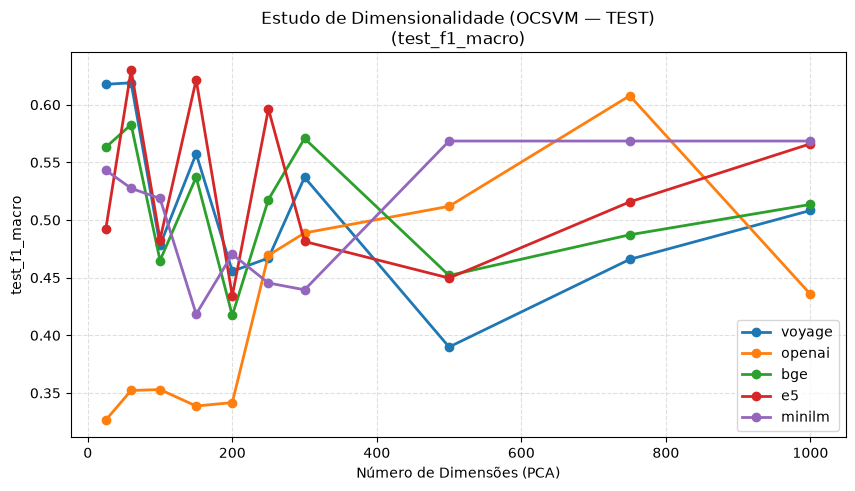

,embedding,dim,test_acc,test_f1_macro,test_recall_scam,test_precision_scam
31,e5,60,0.6352,0.6301,0.7135,0.6373
33,e5,150,0.6220,0.6216,0.6189,0.6477
1,voyage,60,0.6227,0.6190,0.6843,0.6308
0,voyage,25,0.6183,0.6177,0.5480,0.6678
18,openai,750,0.6088,0.6078,0.6245,0.6297
35,e5,250,0.5963,0.5963,0.5647,0.6304
21,bge,60,0.5839,0.5828,0.6022,0.6056
26,bge,300,0.5707,0.5707,0.5355,0.6044
48,minilm,750,0.5685,0.5685,0.5466,0.5991
47,minilm,500,0.5685,0.5685,0.5466,0.5991


In [4]:
# Estudo de dimensionalidade OCSVM (Métricas do Teste Interno - 20% Holdout)
df_dim_ocsvm = compare_dimensions_anomaly(
    model_type="ocsvm",
    embeddings=EMBEDDINGS,
    dimensions=DIMENSIONS_TEST,
    path_data=PATH_DATA,
    split="test",
    force_retrain=FORCE_RETRAIN
)

df_dim_ocsvm = df_dim_ocsvm.sort_values(by="test_f1_macro", ascending=False)
display(df_dim_ocsvm[["embedding", "dim", "test_acc", "test_f1_macro", "test_recall_scam", "test_precision_scam"]].head(15))


[unsupervised] Cache hit: voyage_iforest_25 (params=default)
[cache] Carregando IFOREST + PCA (25d): voyage
[unsupervised] Cache hit: voyage_iforest_60 (params=default)
[cache] Carregando IFOREST + PCA (60d): voyage
[unsupervised] Cache hit: voyage_iforest_100 (params=default)
[cache] Carregando IFOREST + PCA (100d): voyage
[unsupervised] Cache hit: voyage_iforest_150 (params=default)
[cache] Carregando IFOREST + PCA (150d): voyage
[unsupervised] Cache hit: voyage_iforest_200 (params=default)
[cache] Carregando IFOREST + PCA (200d): voyage
[unsupervised] Cache hit: voyage_iforest_250 (params=default)
[cache] Carregando IFOREST + PCA (250d): voyage
[unsupervised] Cache hit: voyage_iforest_300 (params=default)
[cache] Carregando IFOREST + PCA (300d): voyage
[unsupervised] Cache hit: voyage_iforest_500 (params=default)
[cache] Carregando IFOREST + PCA (500d): voyage
[unsupervised] Cache hit: voyage_iforest_750 (params=default)
[cache] Carregando IFOREST + PCA (750d): voyage
[unsupervised]

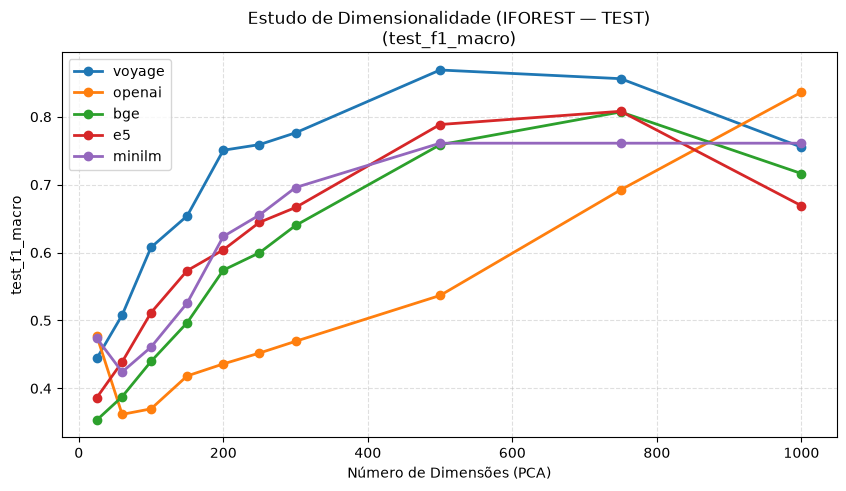

,embedding,dim,test_acc,test_f1_macro,test_recall_scam,test_precision_scam
0,voyage,25,0.5121,0.4442,0.1544,0.6568
1,voyage,60,0.5560,0.5079,0.2309,0.7580
2,voyage,100,0.6315,0.6077,0.3658,0.8484
3,voyage,150,0.6681,0.6540,0.4423,0.8595
4,voyage,200,0.7538,0.7507,0.6092,0.8884
5,voyage,250,0.7612,0.7590,0.6328,0.8801
6,voyage,300,0.7773,0.7764,0.6787,0.8699
7,voyage,500,0.8696,0.8689,0.8943,0.8631
8,voyage,750,0.8608,0.8561,0.9889,0.7962
9,voyage,1000,0.7744,0.7553,1.0000,0.7001


In [5]:
# Estudo de dimensionalidade Isolation Forest (Métricas do Teste Interno - 20% Holdout)
df_dim_iforest = compare_dimensions_anomaly(
    model_type="iforest",
    embeddings=EMBEDDINGS,
    dimensions=DIMENSIONS_TEST,
    path_data=PATH_DATA,
    split="test",
    force_retrain=FORCE_RETRAIN,
)
display(df_dim_iforest[["embedding", "dim", "test_acc", "test_f1_macro", "test_recall_scam", "test_precision_scam"]].head(15))


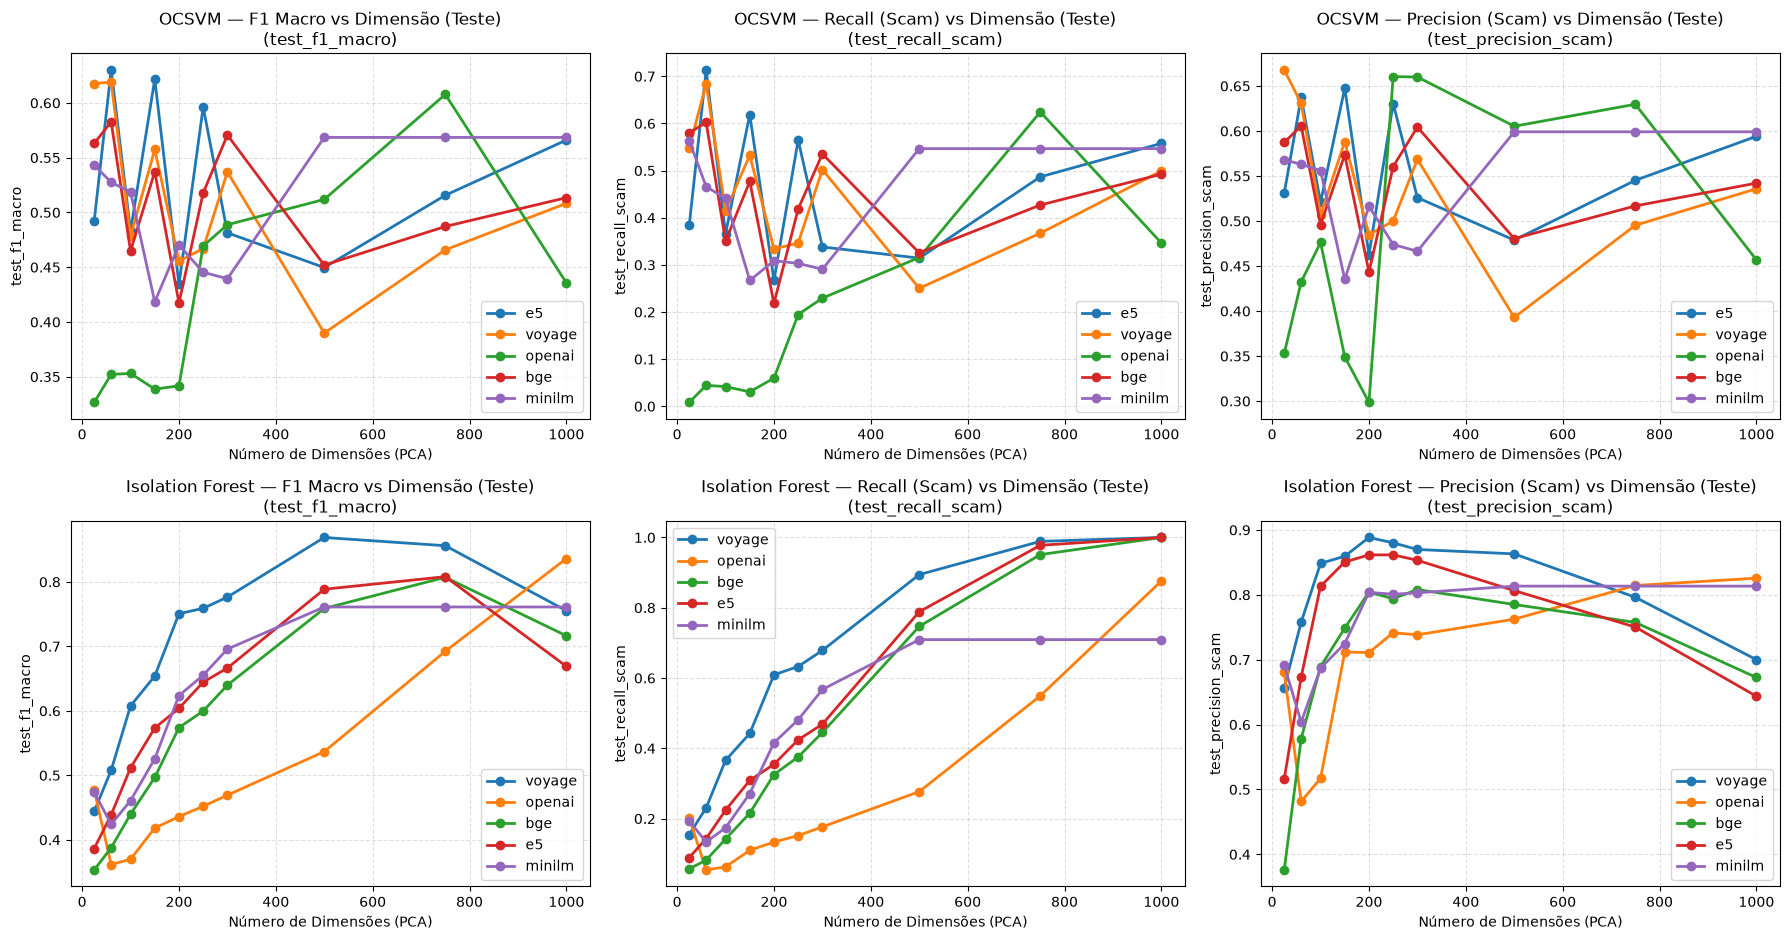

In [6]:
# Comparação visual do impacto da dimensão em F1 Macro, Recall e Precision (TESTE INTERNO)
fig, axes = plt.subplots(2, 3, figsize=(18, 9.5))

# OCSVM
plot_dimension_study(df_dim_ocsvm, metric="test_f1_macro", title="OCSVM — F1 Macro vs Dimensão (Teste)", ax=axes[0, 0])
plot_dimension_study(df_dim_ocsvm, metric="test_recall_scam", title="OCSVM — Recall (Scam) vs Dimensão (Teste)", ax=axes[0, 1])
plot_dimension_study(df_dim_ocsvm, metric="test_precision_scam", title="OCSVM — Precision (Scam) vs Dimensão (Teste)", ax=axes[0, 2])

# Isolation Forest
plot_dimension_study(df_dim_iforest, metric="test_f1_macro", title="Isolation Forest — F1 Macro vs Dimensão (Teste)", ax=axes[1, 0])
plot_dimension_study(df_dim_iforest, metric="test_recall_scam", title="Isolation Forest — Recall (Scam) vs Dimensão (Teste)", ax=axes[1, 1])
plot_dimension_study(df_dim_iforest, metric="test_precision_scam", title="Isolation Forest — Precision (Scam) vs Dimensão (Teste)", ax=axes[1, 2])

plt.tight_layout()
plt.show()


In [7]:
# Grid Search de hiperparâmetros OCSVM no embedding voyage
# Seleção do melhor combo pela validação INTERNA (internal_val_*, holdout de dataset_train).
gs_ocsvm = grid_search_anomaly(
    embedding="voyage",
    model_type="ocsvm",
    pca_dim=1000,
    param_grid={
        "kernel": ["linear", "rbf", "poly"],
        "nu": [0.05, 0.10, 0.15, 0.20],
        "gamma": ["scale", "auto", 0.01, 0.001],
    },
    force_recompute=FORCE_GRID_SEARCH,
)
display(gs_ocsvm.df_history.sort_values("internal_val_f1", ascending=False).head(10))


[data] Carregando: voyage_chunks.parquet
  [data] Filtro sem augmentação -> 6822 amostras.
  [data] Shape: X=(6822, 1024), y=(6822,)
[data] Carregando: voyage_chunks.parquet
  [data] Shape: X=(1083, 1024), y=(1083,)
  [gs] 5/48 | {'kernel': 'linear', 'nu': 0.1, 'gamma': 'scale'} -> internal_val_f1=0.4575 internal_val_pr_auc=0.516
  [gs] 10/48 | {'kernel': 'linear', 'nu': 0.15, 'gamma': 'auto'} -> internal_val_f1=0.5507 internal_val_pr_auc=0.6574
  [gs] 15/48 | {'kernel': 'linear', 'nu': 0.2, 'gamma': 0.01} -> internal_val_f1=0.4182 internal_val_pr_auc=0.4745
  [gs] 20/48 | {'kernel': 'rbf', 'nu': 0.05, 'gamma': 0.001} -> internal_val_f1=0.8004 internal_val_pr_auc=0.9122
  [gs] 25/48 | {'kernel': 'rbf', 'nu': 0.15, 'gamma': 'scale'} -> internal_val_f1=0.8237 internal_val_pr_auc=0.8958
  [gs] 30/48 | {'kernel': 'rbf', 'nu': 0.2, 'gamma': 'auto'} -> internal_val_f1=0.8072 internal_val_pr_auc=0.8916
  [gs] 35/48 | {'kernel': 'poly', 'nu': 0.05, 'gamma': 0.01} -> internal_val_f1=0.7911 inte

,kernel,nu,gamma,internal_val_f1,internal_val_recall_scam,internal_val_roc_auc,internal_val_pr_auc,test_f1,test_recall_scam,test_roc_auc,test_pr_auc,external_val_f1,external_val_recall_scam,external_val_roc_auc,external_val_pr_auc
0,rbf,0.15,0.001,0.8266,0.8417,0.8977,0.8971,0.8335,0.8275,0.9080,0.9095,0.0712,1.0,0.5333,0.1147
1,rbf,0.15,auto,0.8266,0.8417,0.8977,0.8971,0.8335,0.8275,0.9080,0.9095,0.0712,1.0,0.5333,0.1147
2,rbf,0.15,scale,0.8237,0.8361,0.8965,0.8958,0.8306,0.8220,0.9069,0.9082,0.0712,1.0,0.5335,0.1148
3,rbf,0.10,0.001,0.8228,0.7917,0.9048,0.9068,0.8212,0.7691,0.9119,0.9170,0.0712,1.0,0.5396,0.1179
4,rbf,0.10,auto,0.8228,0.7917,0.9048,0.9068,0.8212,0.7691,0.9119,0.9170,0.0712,1.0,0.5396,0.1179
5,rbf,0.10,scale,0.8170,0.7806,0.9035,0.9054,0.8153,0.7566,0.9108,0.9158,0.0712,1.0,0.5397,0.1179
6,rbf,0.20,auto,0.8072,0.8750,0.8949,0.8916,0.8404,0.8873,0.9078,0.9051,0.0712,1.0,0.5242,0.1085
7,rbf,0.20,0.001,0.8072,0.8750,0.8949,0.8916,0.8404,0.8873,0.9078,0.9051,0.0712,1.0,0.5242,0.1085
8,rbf,0.20,scale,0.8072,0.8750,0.8937,0.8905,0.8405,0.8846,0.9069,0.9039,0.0712,1.0,0.5243,0.1086
9,rbf,0.05,0.001,0.8004,0.7139,0.9054,0.9122,0.7894,0.6815,0.9085,0.9178,0.0712,1.0,0.5322,0.1154


In [8]:
# Treino de OCSVM para todos os embeddings (dim = 500)
df_ocsvm_all = train_all_anomaly(
    model_type="ocsvm",
    pca_dim=500,
    embeddings=EMBEDDINGS,
    path_data=PATH_DATA,
    force_retrain=FORCE_RETRAIN,
)
print("=== OCSVM (500d) — Métricas de Teste Interno e Validação Externa ===")
display(df_ocsvm_all[[
    "embedding", "test_acc", "test_f1_macro", "test_recall_scam", "test_precision_scam", "test_roc_auc", "test_pr_auc",
    "val_acc", "val_f1_macro", "val_recall_scam", "val_precision_scam", "val_roc_auc", "val_pr_auc",
]])


[unsupervised] Cache hit: voyage_ocsvm_500 (params=default)
[cache] Carregando OCSVM + PCA (500d): voyage
[unsupervised] Cache hit: openai_ocsvm_500 (params=default)
[cache] Carregando OCSVM + PCA (500d): openai
[unsupervised] Cache hit: bge_ocsvm_500 (params=default)
[cache] Carregando OCSVM + PCA (500d): bge
[unsupervised] Cache hit: e5_ocsvm_500 (params=default)
[cache] Carregando OCSVM + PCA (500d): e5
[unsupervised] Cache hit: minilm_ocsvm_500 (params=default)
[cache] Carregando OCSVM + PCA (500d): minilm
=== OCSVM (500d) — Métricas de Teste Interno e Validação Externa ===


,embedding,test_acc,test_f1_macro,test_recall_scam,test_precision_scam,test_roc_auc,test_pr_auc,val_acc,val_f1_macro,val_recall_scam,val_precision_scam,val_roc_auc,val_pr_auc
0,voyage,0.4015,0.3899,0.2503,0.3930,0.3313,0.4613,0.9317,0.5800,0.1084,1.0000,0.9777,0.8221
1,openai,0.5311,0.5119,0.3157,0.6053,0.5285,0.5682,0.9151,0.4884,0.0120,0.0909,0.2518,0.0540
2,bge,0.4593,0.4519,0.3255,0.4805,0.4560,0.5233,0.4598,0.3332,0.1566,0.0246,0.3337,0.0536
3,e5,0.4586,0.4497,0.3143,0.4788,0.4185,0.5021,0.7535,0.4541,0.0843,0.0354,0.5580,0.0787
4,minilm,0.5685,0.5685,0.5466,0.5991,0.5826,0.6140,0.6953,0.5597,0.9157,0.1905,0.8190,0.1758


In [9]:
# Treino de Isolation Forest para todos os embeddings (dim = 1000)
df_iforest_all = train_all_anomaly(
    model_type="iforest",
    pca_dim=1000,
    embeddings=EMBEDDINGS,
    path_data=PATH_DATA,
    force_retrain=FORCE_RETRAIN,
)
print("=== Isolation Forest (1000d) — Métricas de Teste Interno e Validação Externa ===")
display(df_iforest_all[[
    "embedding", "test_acc", "test_f1_macro", "test_recall_scam", "test_precision_scam", "test_roc_auc", "test_pr_auc",
    "val_acc", "val_f1_macro", "val_recall_scam", "val_precision_scam", "val_roc_auc", "val_pr_auc",
]])


[unsupervised] Cache hit: voyage_iforest_1000 (params=default)
[cache] Carregando IFOREST + PCA (1000d): voyage
[unsupervised] Cache hit: openai_iforest_1000 (params=default)
[cache] Carregando IFOREST + PCA (1000d): openai
[unsupervised] Cache hit: bge_iforest_1000 (params=default)
[cache] Carregando IFOREST + PCA (1000d): bge
[unsupervised] Cache hit: e5_iforest_1000 (params=default)
[cache] Carregando IFOREST + PCA (1000d): e5
[unsupervised] Cache hit: minilm_iforest_1000 (params=default)
[cache] Carregando IFOREST + PCA (1000d): minilm
=== Isolation Forest (1000d) — Métricas de Teste Interno e Validação Externa ===


,embedding,test_acc,test_f1_macro,test_recall_scam,test_precision_scam,test_roc_auc,test_pr_auc,val_acc,val_f1_macro,val_recall_scam,val_precision_scam,val_roc_auc,val_pr_auc
0,voyage,0.7744,0.7553,1.0000,0.7001,0.9435,0.9407,0.0766,0.0712,1.0000,0.0766,0.6920,0.2226
1,openai,0.8374,0.8362,0.8762,0.8257,0.8760,0.8283,0.0766,0.0712,1.0000,0.0766,0.4049,0.0620
2,bge,0.7436,0.7164,1.0000,0.6726,0.8726,0.8405,0.0766,0.0712,1.0000,0.0766,0.0245,0.0401
3,e5,0.7084,0.6690,1.0000,0.6437,0.9047,0.8990,0.0766,0.0712,1.0000,0.0766,0.0106,0.0399
4,minilm,0.7612,0.7611,0.7093,0.8134,0.8311,0.7771,0.0249,0.0245,0.3012,0.0244,0.0216,0.0400


In [10]:
# Tabela comparativa geral OCSVM vs Isolation Forest por Embedding (Métricas do Teste Interno)
df_all_comp = pd.concat([
    df_ocsvm_all.assign(model="OCSVM_500d"),
    df_iforest_all.assign(model="IForest_1000d"),
]).sort_values("test_f1_macro", ascending=False).reset_index(drop=True)

display(df_all_comp[["model", "embedding", "test_acc", "test_f1_macro", "test_recall_scam", "test_precision_scam", "val_f1_macro", "val_recall_scam"]])


,model,embedding,test_acc,test_f1_macro,test_recall_scam,test_precision_scam,val_f1_macro,val_recall_scam
0,IForest_1000d,openai,0.8374,0.8362,0.8762,0.8257,0.0712,1.0000
1,IForest_1000d,minilm,0.7612,0.7611,0.7093,0.8134,0.0245,0.3012
2,IForest_1000d,voyage,0.7744,0.7553,1.0000,0.7001,0.0712,1.0000
3,IForest_1000d,bge,0.7436,0.7164,1.0000,0.6726,0.0712,1.0000
4,IForest_1000d,e5,0.7084,0.6690,1.0000,0.6437,0.0712,1.0000
5,OCSVM_500d,minilm,0.5685,0.5685,0.5466,0.5991,0.5597,0.9157
6,OCSVM_500d,openai,0.5311,0.5119,0.3157,0.6053,0.4884,0.0120
7,OCSVM_500d,bge,0.4593,0.4519,0.3255,0.4805,0.3332,0.1566
8,OCSVM_500d,e5,0.4586,0.4497,0.3143,0.4788,0.4541,0.0843
9,OCSVM_500d,voyage,0.4015,0.3899,0.2503,0.3930,0.5800,0.1084


### 5.1 Métricas completas (train/val/test/validação externa) do melhor embedding — OCSVM e IForest


In [11]:
# Melhor embedding por modelo (por val_f1_macro) — reusa o cache do treino acima
best_emb_ocsvm = df_ocsvm_all.sort_values("val_f1_macro", ascending=False).iloc[0]["embedding"]
best_emb_iforest = df_iforest_all.sort_values("val_f1_macro", ascending=False).iloc[0]["embedding"]
print(f"Melhor embedding — OCSVM: {best_emb_ocsvm} | Isolation Forest: {best_emb_iforest}")

res_ocsvm = train_anomaly(
    embedding=best_emb_ocsvm,
    model_type="ocsvm",
    pca_dim=500,
    path_data=PATH_DATA,
    force_retrain=FORCE_RETRAIN,
)
res_ocsvm.print_metrics()
res_ocsvm.plot_confusion_matrix(title=f"OCSVM ({best_emb_ocsvm}) — Validação Externa")
res_ocsvm.plot_roc_curve()
res_ocsvm.plot_precision_recall_curve()

res_iforest = train_anomaly(
    embedding=best_emb_iforest,
    model_type="iforest",
    pca_dim=1000,
    path_data=PATH_DATA,
    force_retrain=FORCE_RETRAIN,
)
res_iforest.print_metrics()
res_iforest.plot_confusion_matrix(title=f"Isolation Forest ({best_emb_iforest}) — Validação Externa")
res_iforest.plot_roc_curve()
res_iforest.plot_precision_recall_curve()


Melhor embedding — OCSVM: voyage | Isolation Forest: voyage
[unsupervised] Cache hit: voyage_ocsvm_500 (params=default)
[cache] Carregando OCSVM + PCA (500d): voyage
  model_name        dataset_name  accuracy  f1_macro  f1_scam  recall_scam  precision_scam  roc_auc  pr_auc  TP   TN   FP   FN
OCSVM_voyage               train    0.4070    0.3993   0.3312       0.2787          0.4080   0.3578  0.5005 701 1242 1017 1814
OCSVM_voyage                 val    0.4202    0.4161   0.3674       0.3194          0.4323   0.3855  0.4973 115  172  151  245
OCSVM_voyage                test    0.4015    0.3899   0.3059       0.2503          0.3930   0.3313  0.4613 180  368  278  539
OCSVM_voyage validation_external    0.9317    0.5800   0.1957       0.1084          1.0000   0.9777  0.8221   9 1000    0   74
Sem predições para plotar.
Sem probabilidades para plotar curva ROC.
Sem probabilidades para plotar curva PR.
[unsupervised] Cache hit: voyage_iforest_1000 (params=default)
[cache] Carregando IFOREST

In [12]:
_GS_METRIC_COLS = {
    "internal_val_f1", "internal_val_recall_scam", "internal_val_roc_auc", "internal_val_pr_auc",
    "test_f1", "test_recall_scam", "test_roc_auc", "test_pr_auc",
    "external_val_f1", "external_val_recall_scam", "external_val_roc_auc", "external_val_pr_auc",
}


def _normalize_model_params(model_type, params):
    """Converte parâmetros inteiros recuperados do pandas para int antes do fit."""
    integer_params = {
        "lof": {"n_neighbors"},
        "lunar": {"n_neighbors", "n_epochs"},
        "svdd": {"latent_dim", "n_epochs", "batch_size", "warmup_epochs"},
        "ocsvm": set(),
        "iforest": {"n_estimators"},
    }
    normalized = dict(params)
    for name in integer_params.get(model_type, set()):
        if name in normalized and normalized[name] is not None:
            normalized[name] = int(normalized[name])
    return normalized


def train_all_tuned(
    model_type,
    pca_dim=300,
    embeddings=None,
    path_data=PATH_DATA,
    force_retrain=FORCE_RETRAIN,
    force_grid_search=FORCE_GRID_SEARCH,
):
    """Executa tuning e treino final, com controle explícito de cache."""
    embeddings = embeddings or EMBEDDINGS
    rows, results = [], {}
    for emb in embeddings:
        gs = grid_search_anomaly(
            embedding=emb,
            model_type=model_type,
            pca_dim=pca_dim,
            path_data=path_data,
            force_recompute=force_grid_search,
        )
        best = gs.df_metrics.iloc[0].to_dict()
        best_params = {k: v for k, v in best.items() if k not in _GS_METRIC_COLS}
        best_params = _normalize_model_params(model_type, best_params)
        res = train_anomaly(
            embedding=emb,
            model_type=model_type,
            pca_dim=pca_dim,
            path_data=path_data,
            force_retrain=force_retrain,
            **best_params,
        )
        results[emb] = res
        test_m = res.df_metrics[res.df_metrics["dataset_name"] == "test"].iloc[0]
        val_m = res.df_metrics[res.df_metrics["dataset_name"] == "validation_external"].iloc[0]
        rows.append({
            "embedding": emb,
            "best_params": best_params,
            "test_acc": test_m["accuracy"],
            "test_f1_macro": test_m["f1_macro"],
            "test_recall_scam": test_m["recall_scam"],
            "test_precision_scam": test_m["precision_scam"],
            "test_roc_auc": test_m["roc_auc"],
            "test_pr_auc": test_m["pr_auc"],
            "val_acc": val_m["accuracy"],
            "val_f1_macro": val_m["f1_macro"],
            "val_recall_scam": val_m["recall_scam"],
            "val_precision_scam": val_m["precision_scam"],
            "val_roc_auc": val_m["roc_auc"],
            "val_pr_auc": val_m["pr_auc"],
        })
    return pd.DataFrame(rows), results


## 6. Curvas de Aprendizado e Matrizes de Confusão por Fração do Dataset

Análise do aprendizado à medida que variamos o tamanho do dataset de treino benigno (5% a 100%) para todos os embeddings.


==================== Isolation Forest — VOYAGE ====================
[unsupervised_lc] Cache hit — curva de aprendizado
  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=voyage__model_type=iforest__pca_dim=1000__reducer=pca__strat_58cc6c23/dataset_size_curve.png


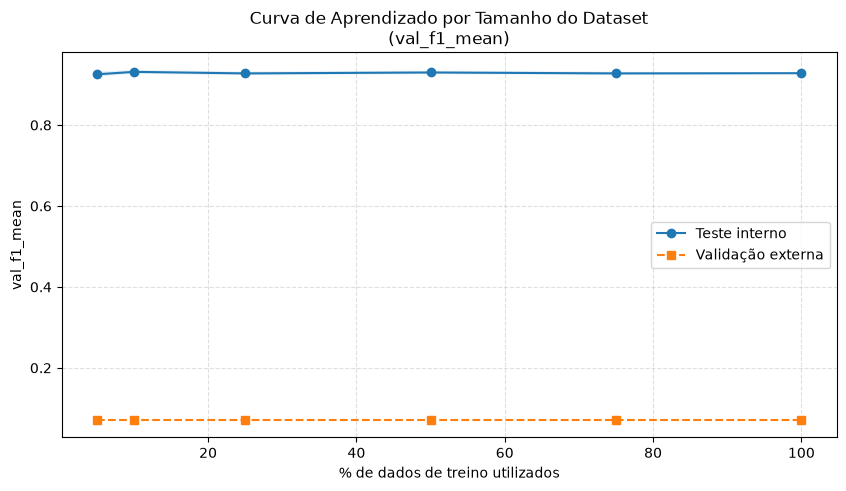

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=voyage__model_type=iforest__pca_dim=1000__reducer=pca__strat_58cc6c23/confusion_matrix_evolution.png


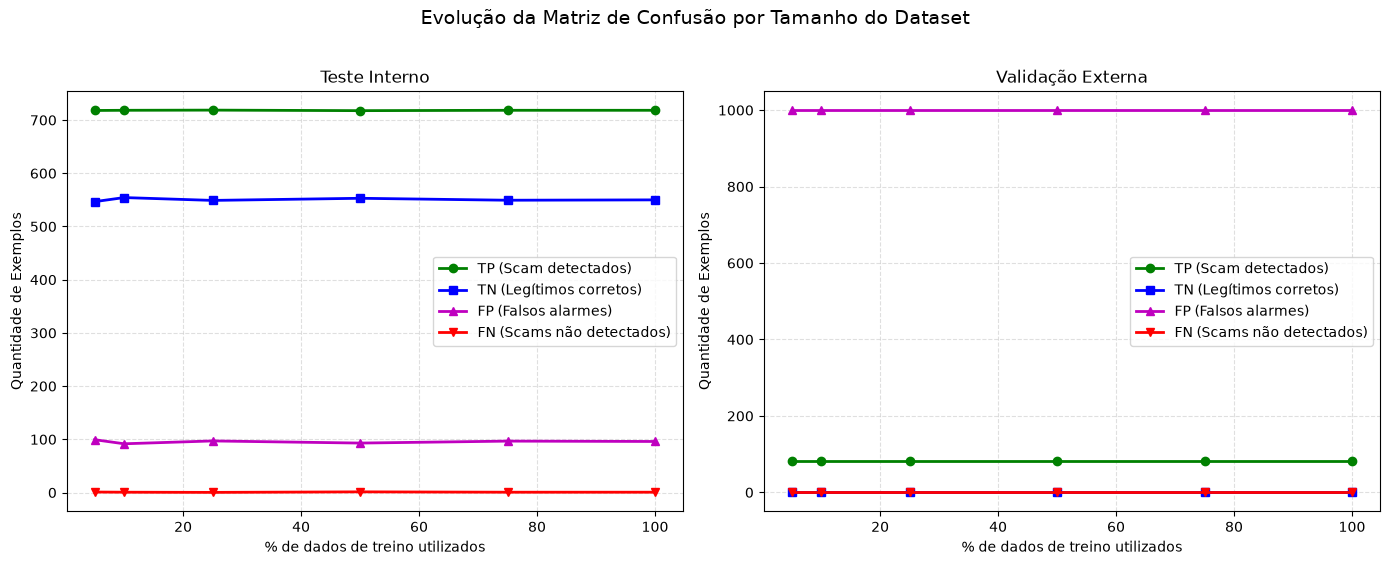

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=voyage__model_type=iforest__pca_dim=1000__reducer=pca__strat_58cc6c23/confusion_matrices_by_fraction.png


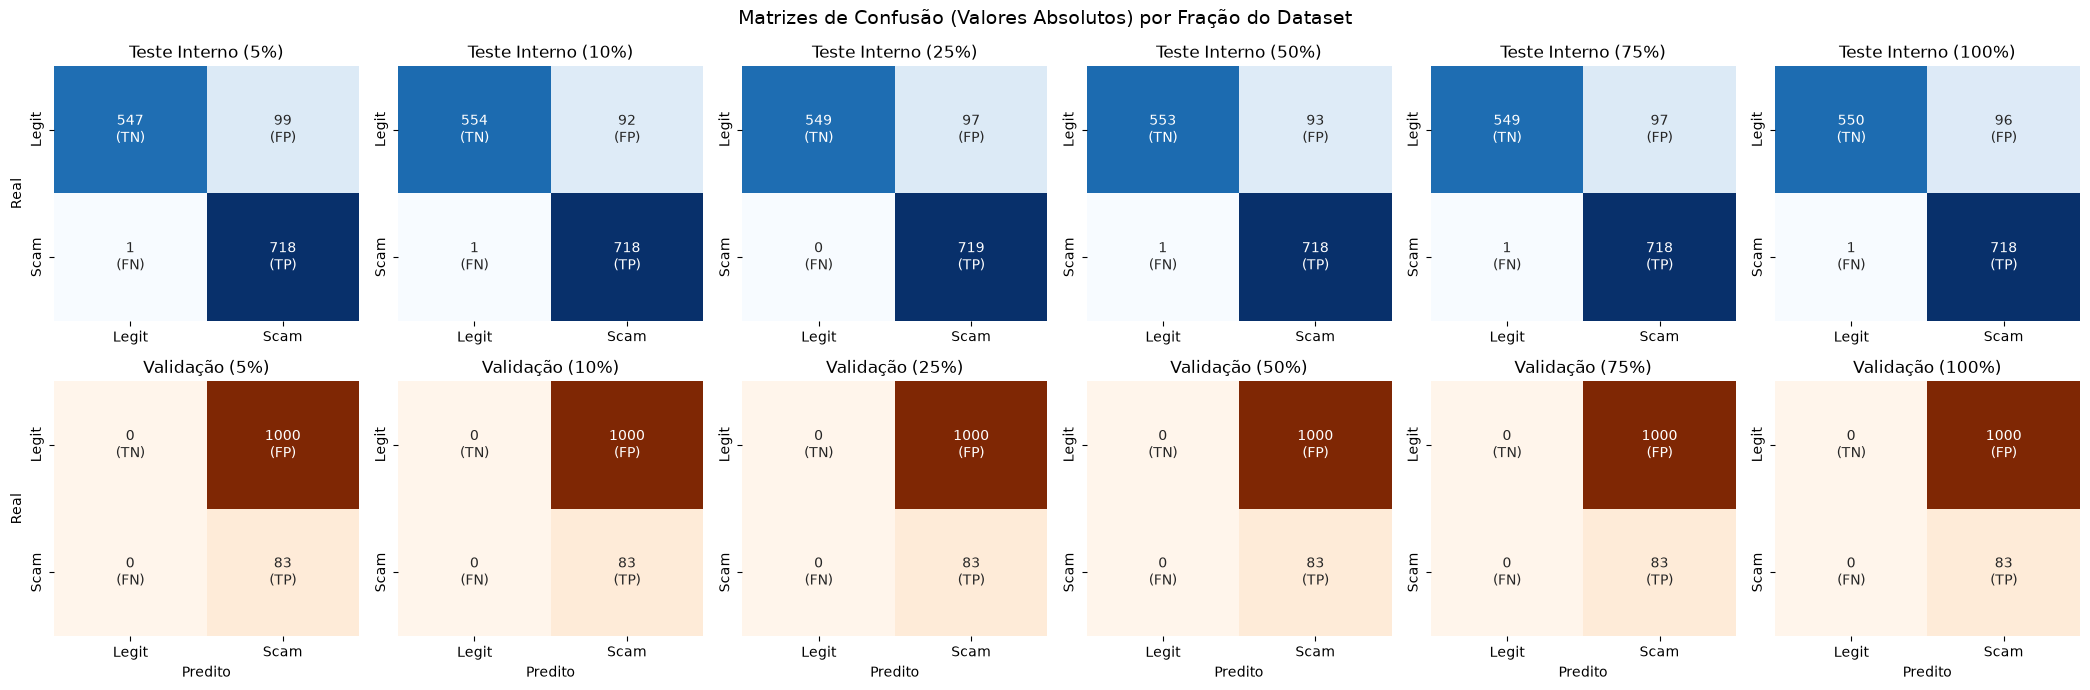


==================== Isolation Forest — OPENAI ====================
[unsupervised_lc] Cache hit — curva de aprendizado
  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=openai__model_type=iforest__pca_dim=1000__reducer=pca__strat_08e9e7e7/dataset_size_curve.png


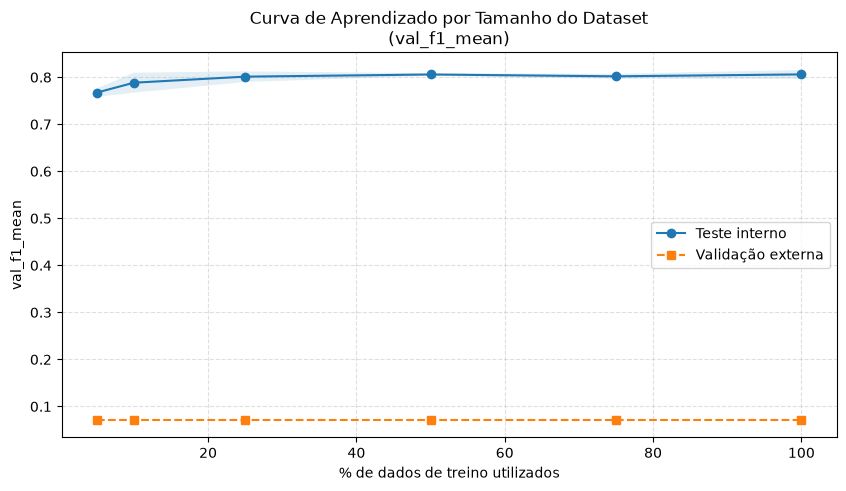

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=openai__model_type=iforest__pca_dim=1000__reducer=pca__strat_08e9e7e7/confusion_matrix_evolution.png


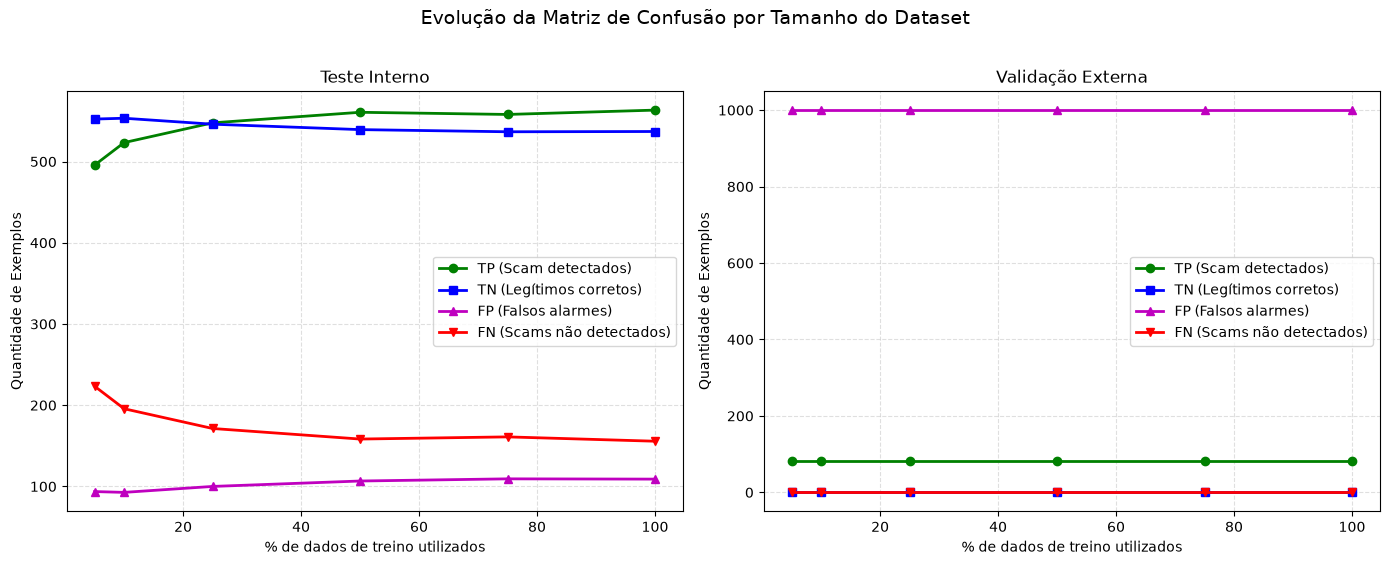

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=openai__model_type=iforest__pca_dim=1000__reducer=pca__strat_08e9e7e7/confusion_matrices_by_fraction.png


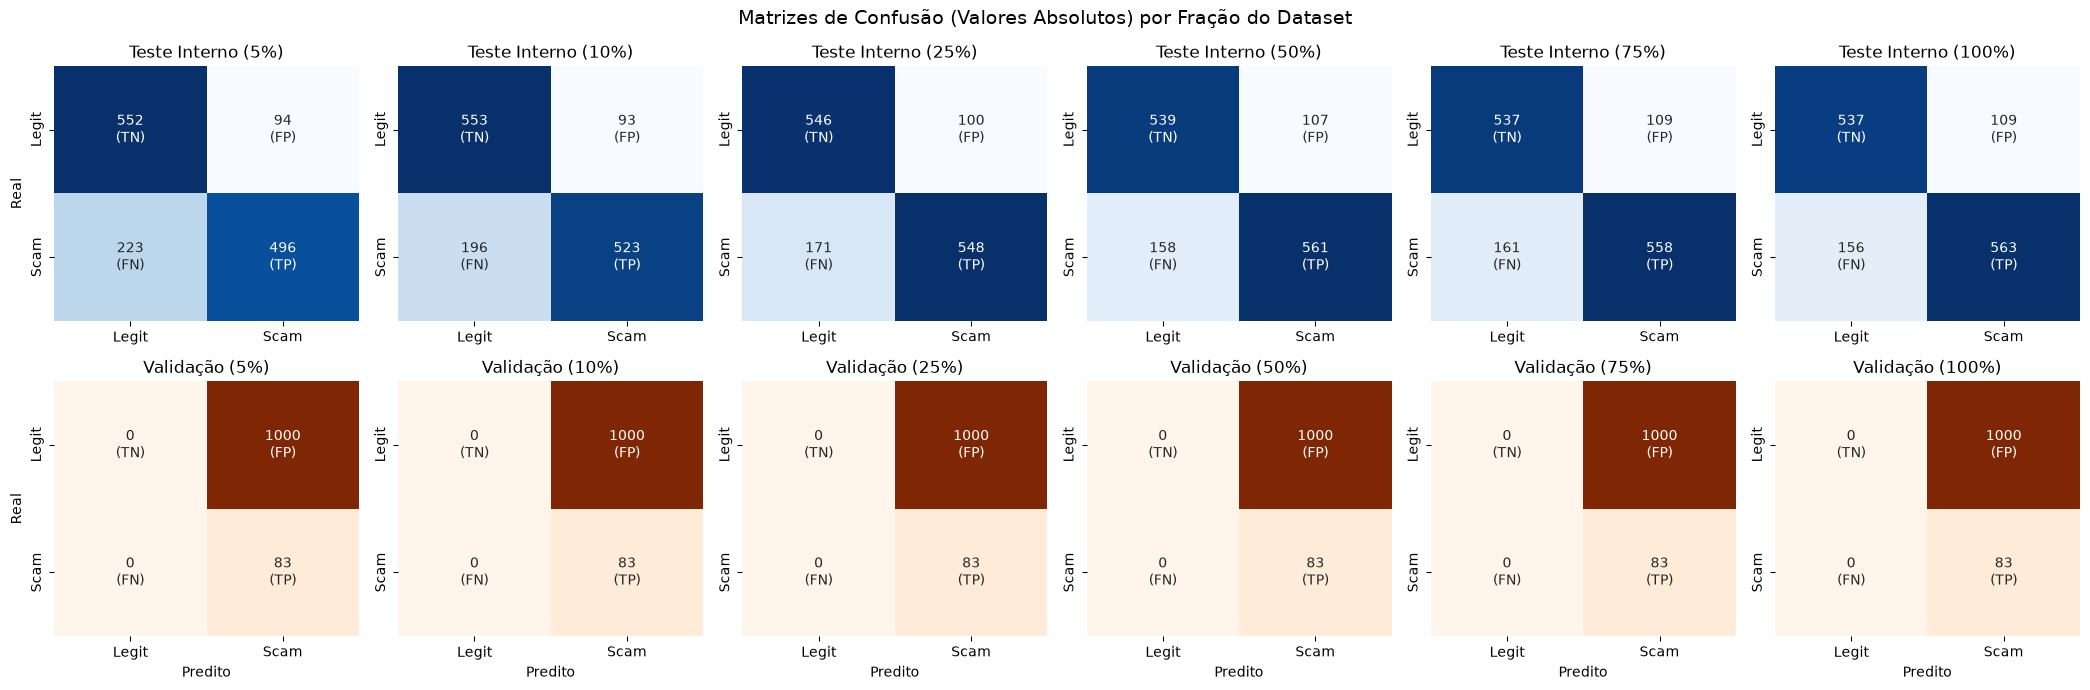


==================== Isolation Forest — BGE ====================
[unsupervised_lc] Cache hit — curva de aprendizado
  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=bge__model_type=iforest__pca_dim=1000__reducer=pca__strategy_757d5bbd/dataset_size_curve.png


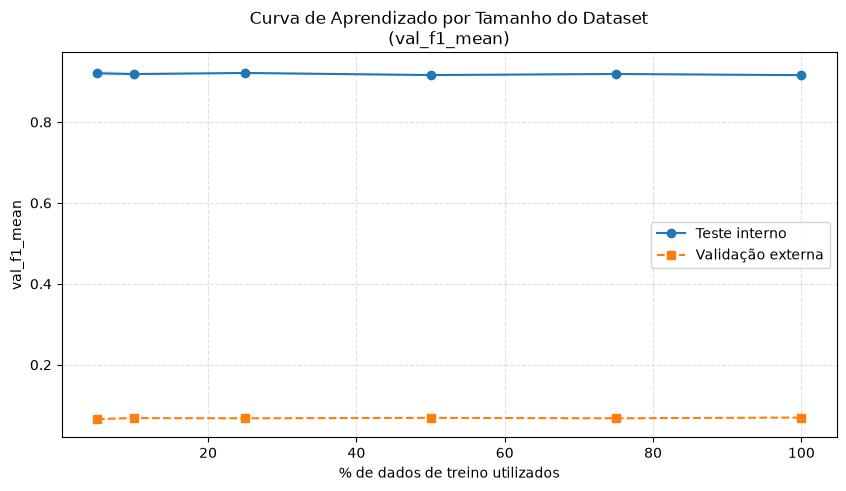

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=bge__model_type=iforest__pca_dim=1000__reducer=pca__strategy_757d5bbd/confusion_matrix_evolution.png


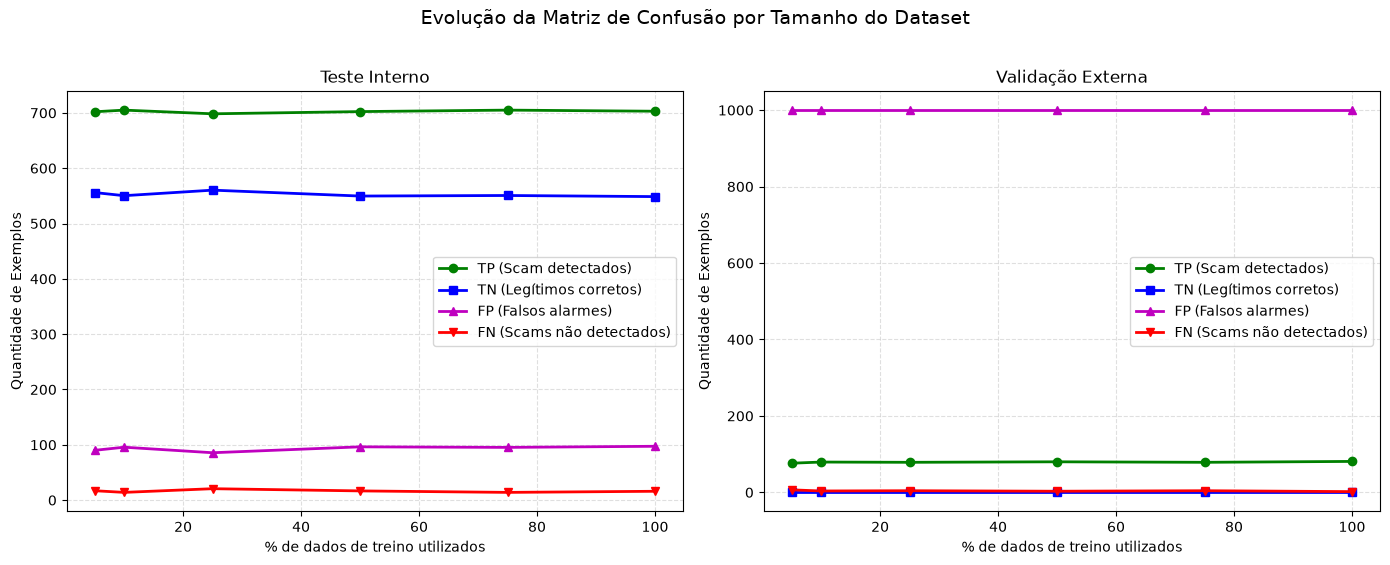

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=bge__model_type=iforest__pca_dim=1000__reducer=pca__strategy_757d5bbd/confusion_matrices_by_fraction.png


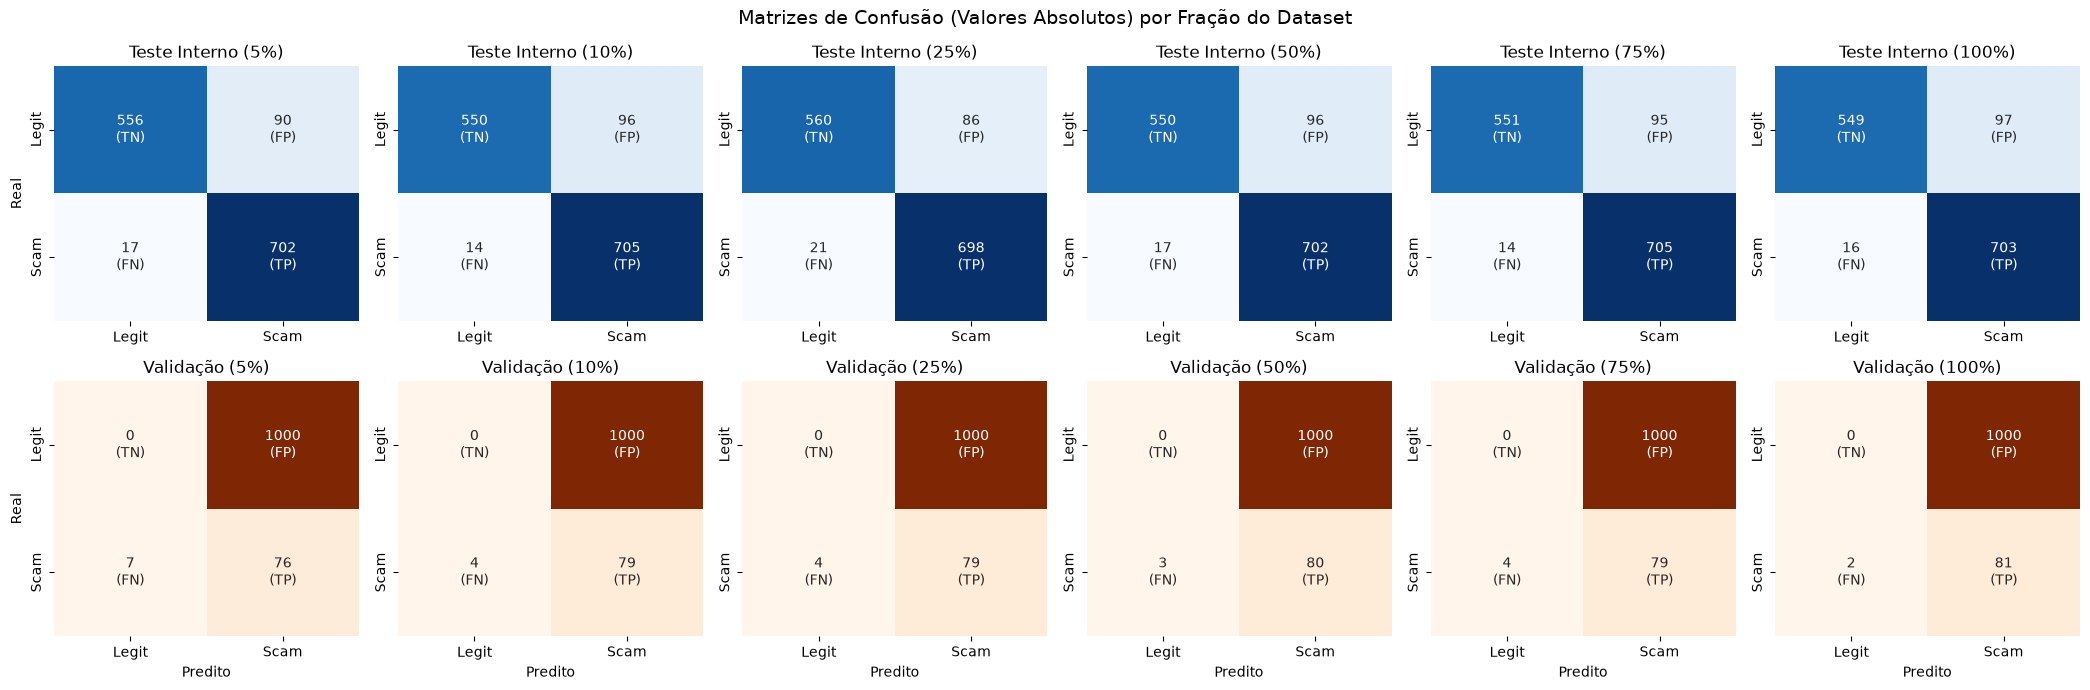


==================== Isolation Forest — E5 ====================
[unsupervised_lc] Cache hit — curva de aprendizado
  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=e5__model_type=iforest__pca_dim=1000__reducer=pca__strategy=_1e42d4bb/dataset_size_curve.png


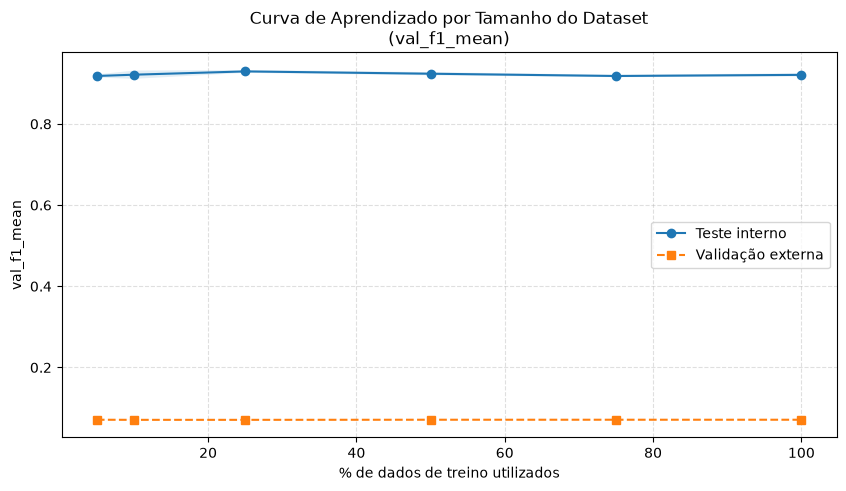

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=e5__model_type=iforest__pca_dim=1000__reducer=pca__strategy=_1e42d4bb/confusion_matrix_evolution.png


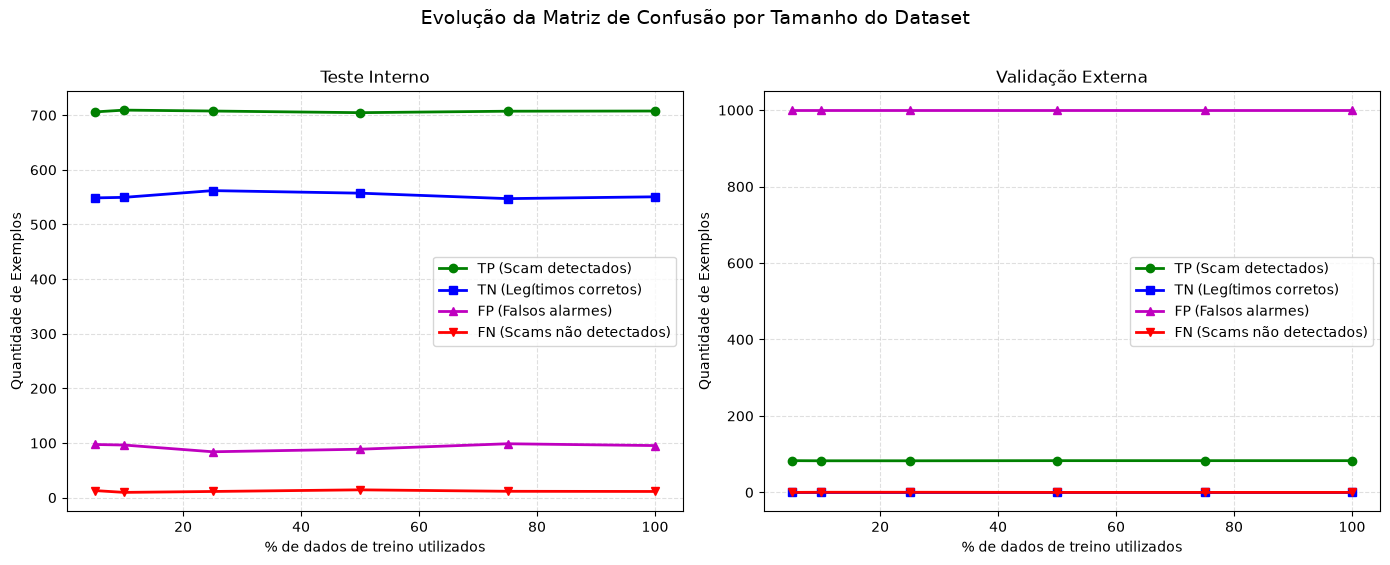

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=e5__model_type=iforest__pca_dim=1000__reducer=pca__strategy=_1e42d4bb/confusion_matrices_by_fraction.png


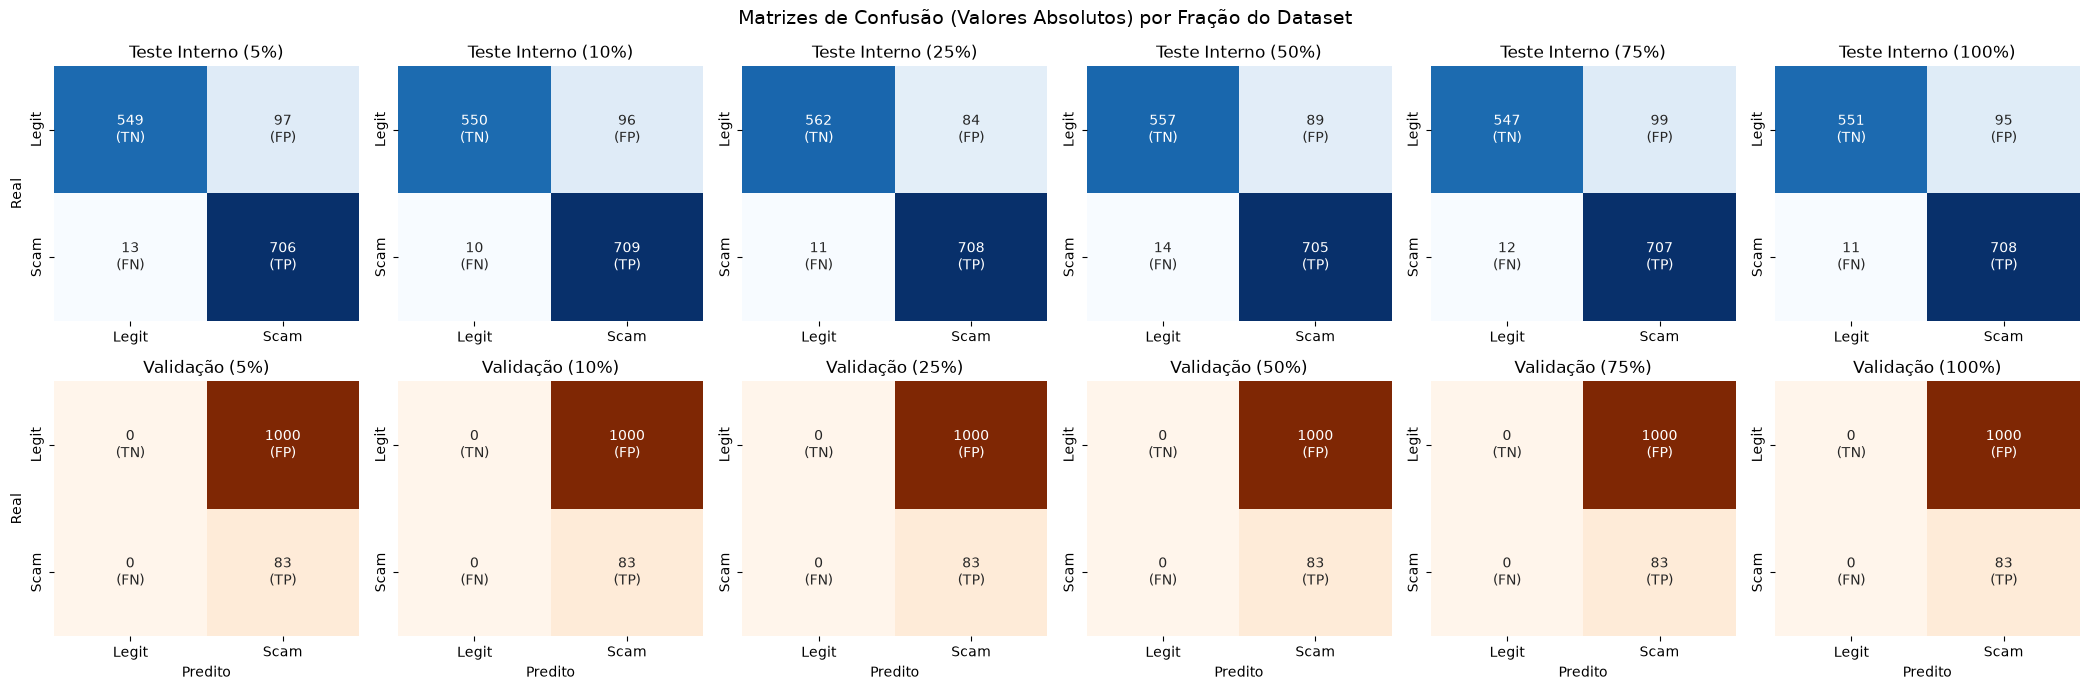


==================== Isolation Forest — MINILM ====================
[unsupervised_lc] Cache hit — curva de aprendizado
  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=minilm__model_type=iforest__pca_dim=1000__reducer=pca__strat_cb2e6412/dataset_size_curve.png


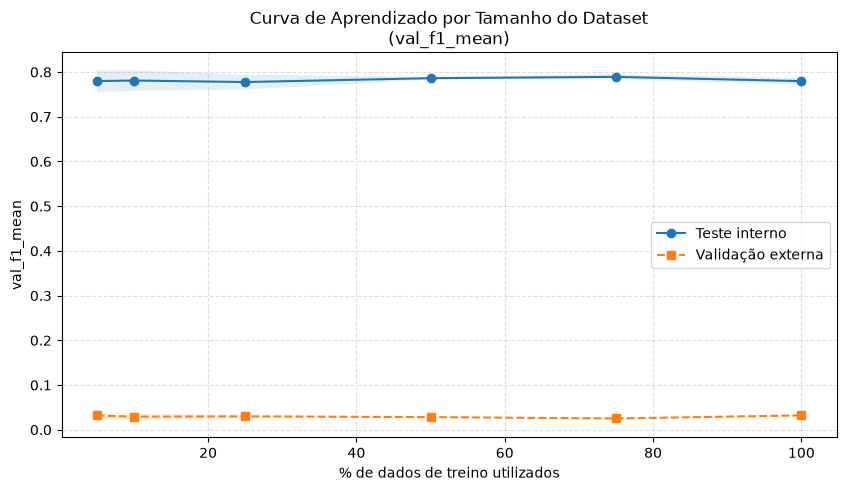

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=minilm__model_type=iforest__pca_dim=1000__reducer=pca__strat_cb2e6412/confusion_matrix_evolution.png


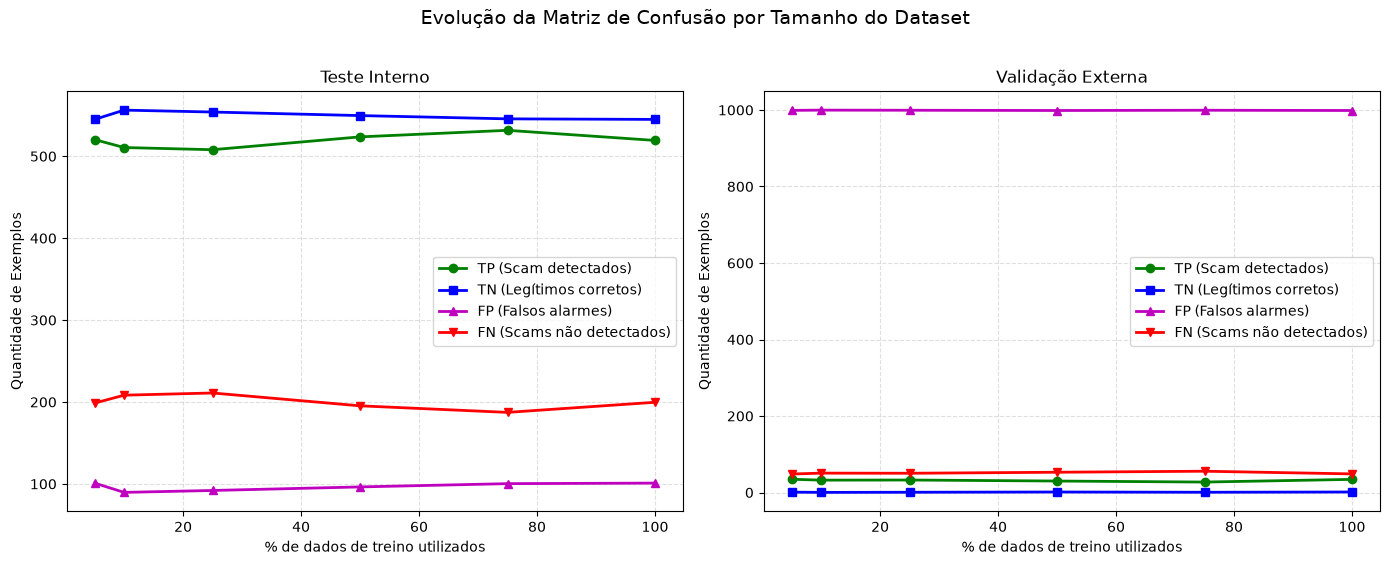

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=minilm__model_type=iforest__pca_dim=1000__reducer=pca__strat_cb2e6412/confusion_matrices_by_fraction.png


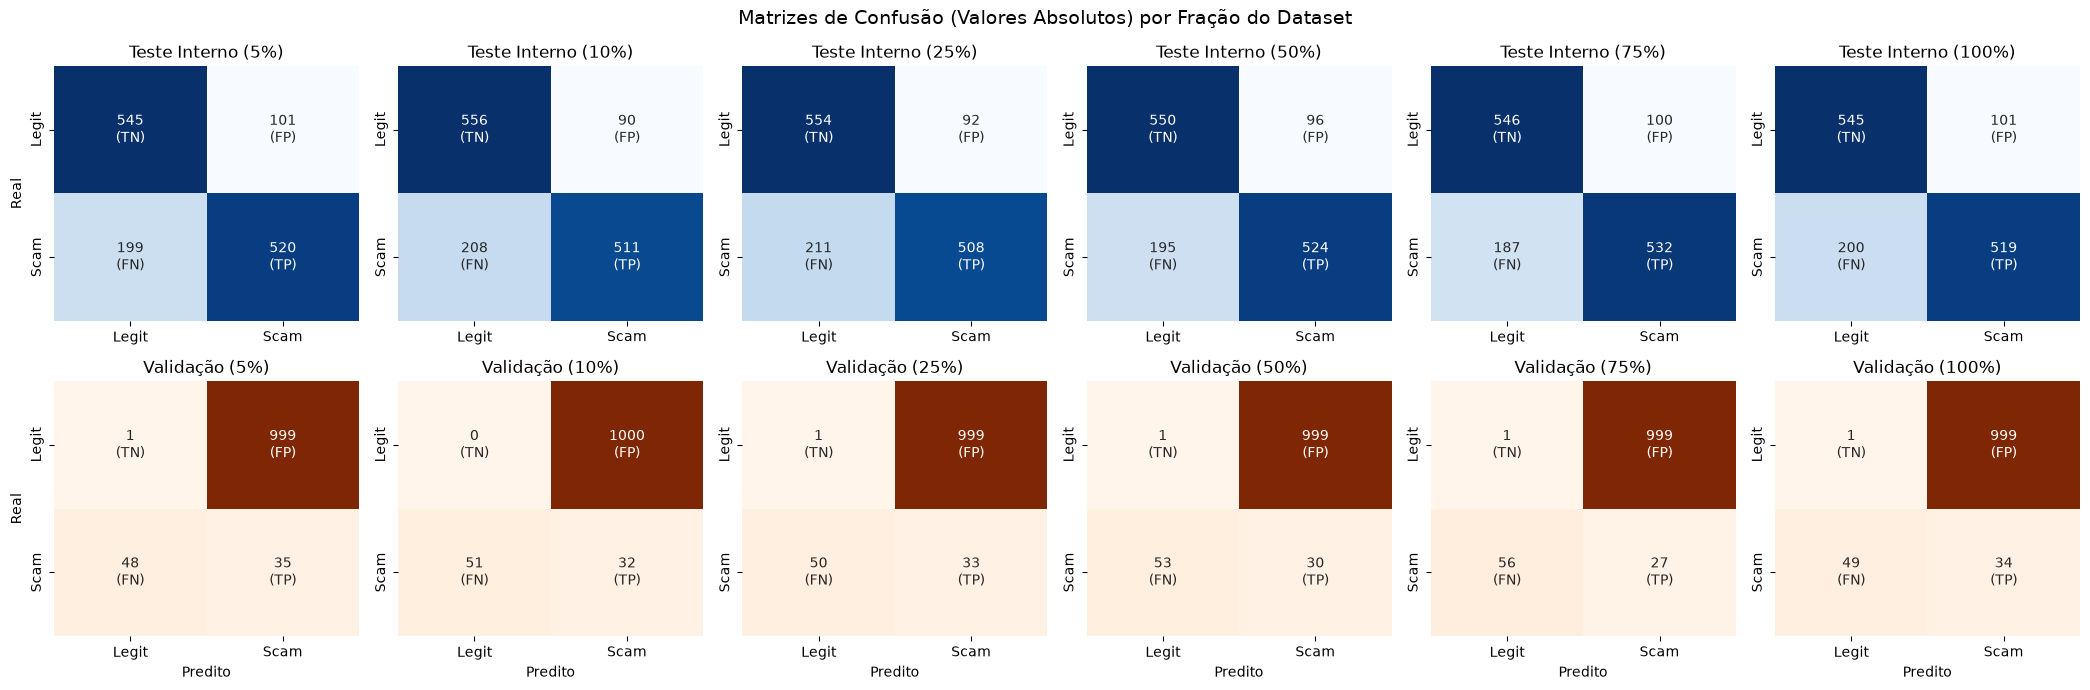

In [13]:
# Curva de aprendizado Isolation Forest para todos os embeddings
for emb in EMBEDDINGS:
    print(f"\n==================== Isolation Forest — {emb.upper()} ====================")
    lc = learning_curve_anomaly(
        embedding=emb,
        model_type="iforest",
        pca_dim=1000,
        train_sizes=[0.05, 0.10, 0.25, 0.50, 0.75, 1.00],
        n_repeats=3,
    )
    lc.plot_dataset_size_curve(metric="val_f1_mean")
    lc.plot_confusion_matrix_evolution()
    lc.plot_confusion_matrices_by_fraction()


## 6.1 Helper — Pipeline "tuning + treino final" (mesma lógica do `submit_full_pipeline.sh`)

Para os modelos com hiperparâmetros ajustáveis (LOF, LUNAR, Deep SVDD), em vez de treinar direto com hiperparâmetros
padrão, replicamos aqui a mesma lógica de 2 etapas usada no SLURM: 1) `grid_search_anomaly` escolhe os melhores
hiperparâmetros por embedding (validação **interna**); 2) `train_anomaly` treina o modelo final com esses hiperparâmetros.

Como `grid_search_anomaly`/`train_anomaly` são cacheados por config (incluindo agora os hiperparâmetros — via
`params_hash`), se você já rodou `submit_full_pipeline.sh` no cluster, as células abaixo **não retreinam nada**:
elas só recarregam os resultados do cache, desde que usem os MESMOS hiperparâmetros (por isso passamos os
`best_params` do grid search explicitamente para `train_anomaly`, em vez de usar os valores padrão).


## 7. LOF — Local Outlier Factor

Mede a densidade local de cada ponto relativa aos `n_neighbors` vizinhos mais próximos (PyOD, modo *novelty*). Ver `machine_learning/unsupervised/README.md` seção 2.3.

### 7.1 Grid Search de hiperparâmetros (validação interna)


In [14]:
# Grid Search de hiperparâmetros LOF no embedding bge (validação interna escolhe o melhor combo)
gs_lof = grid_search_anomaly(
    embedding="bge",
    model_type="lof",
    pca_dim=300,
    param_grid={
        "n_neighbors": [10, 20, 35, 50],
        "contamination": [0.05, 0.10, 0.15, 0.20],
    },
    force_recompute=FORCE_GRID_SEARCH,
)
display(gs_lof.df_history.sort_values("internal_val_f1", ascending=False).head(10))


[unsupervised_gs] Cache hit — grid search


,n_neighbors,contamination,internal_val_f1,internal_val_recall_scam,internal_val_roc_auc,internal_val_pr_auc,test_f1,test_recall_scam,test_roc_auc,test_pr_auc,external_val_f1,external_val_recall_scam,external_val_roc_auc,external_val_pr_auc
0,10,0.10,0.8316,0.7750,0.8797,0.9154,0.8093,0.7010,0.8579,0.8751,0.0272,0.3253,0.0043,0.0399
1,10,0.15,0.8257,0.8056,0.8797,0.9154,0.8123,0.7399,0.8579,0.8751,0.0400,0.5301,0.0043,0.0399
2,10,0.20,0.8210,0.8222,0.8797,0.9154,0.8000,0.7594,0.8579,0.8751,0.0533,0.7349,0.0043,0.0399
3,10,0.05,0.8167,0.6833,0.8797,0.9154,0.7607,0.5911,0.8579,0.8751,0.0194,0.1325,0.0043,0.0399
4,20,0.20,0.8017,0.8167,0.8508,0.8866,0.7839,0.7469,0.8415,0.8743,0.0433,0.5904,0.0033,0.0398
5,20,0.15,0.7935,0.7639,0.8508,0.8866,0.7776,0.6968,0.8415,0.8743,0.0322,0.4337,0.0033,0.0398
6,20,0.10,0.7898,0.6917,0.8508,0.8866,0.7500,0.6092,0.8415,0.8743,0.0248,0.2410,0.0033,0.0398
7,35,0.15,0.7671,0.7111,0.8232,0.8525,0.7571,0.6537,0.8259,0.8544,0.0270,0.3614,0.0030,0.0398
8,35,0.20,0.7653,0.7694,0.8232,0.8525,0.7589,0.7065,0.8259,0.8544,0.0356,0.4819,0.0030,0.0398
9,50,0.20,0.7318,0.7222,0.7971,0.8210,0.7448,0.6787,0.8118,0.8351,0.0287,0.3855,0.0026,0.0398


### 7.2 Treino em todos os embeddings (métricas de treino e validação)


In [15]:
# Treino de LOF para todos os embeddings (dim = 300), já com os melhores hiperparâmetros por embedding
# (grid_search_anomaly + train_anomaly — cache-hit se já rodado via submit_full_pipeline.sh)
df_lof_all, results_lof = train_all_tuned(model_type="lof", pca_dim=300, embeddings=EMBEDDINGS, path_data=PATH_DATA)
print("=== LOF (300d, hiperparâmetros tunados) — Teste Interno (holdout) e Validação Externa (vida real) ===")
display(df_lof_all[[
    "embedding", "best_params", "test_acc", "test_f1_macro", "test_recall_scam", "test_precision_scam", "test_roc_auc", "test_pr_auc",
    "val_acc", "val_f1_macro", "val_recall_scam", "val_precision_scam", "val_roc_auc", "val_pr_auc",
]])


[unsupervised_gs] Cache hit — grid search
[unsupervised] Cache hit: voyage_lof_300 (params=8e96b1b4)
[cache] Carregando LOF + PCA (300d): voyage
[unsupervised_gs] Cache hit — grid search
[unsupervised] Cache hit: openai_lof_300 (params=1bbf0fe0)
[cache] Carregando LOF + PCA (300d): openai
[unsupervised_gs] Cache hit — grid search
[unsupervised] Cache hit: bge_lof_300 (params=a7835e51)
[cache] Carregando LOF + PCA (300d): bge
[unsupervised_gs] Cache hit — grid search
[unsupervised] Cache hit: e5_lof_300 (params=a7835e51)
[cache] Carregando LOF + PCA (300d): e5
[unsupervised_gs] Cache hit — grid search
[unsupervised] Cache hit: minilm_lof_300 (params=8e96b1b4)
[cache] Carregando LOF + PCA (300d): minilm
=== LOF (300d, hiperparâmetros tunados) — Teste Interno (holdout) e Validação Externa (vida real) ===


,embedding,best_params,test_acc,test_f1_macro,test_recall_scam,test_precision_scam,test_roc_auc,test_pr_auc,val_acc,val_f1_macro,val_recall_scam,val_precision_scam,val_roc_auc,val_pr_auc
0,voyage,"{'n_neighbors': 10, 'contamination': 0.15}",0.8293,0.8292,0.7677,0.8932,0.9070,0.9308,0.0766,0.0712,1.0000,0.0766,0.1080,0.0419
1,openai,"{'n_neighbors': 10, 'contamination': 0.05}",0.8125,0.8103,0.6690,0.9639,0.8487,0.9010,0.0766,0.0712,1.0000,0.0766,0.0006,0.0398
2,bge,"{'n_neighbors': 10, 'contamination': 0.1}",0.8103,0.8093,0.7010,0.9197,0.8579,0.8751,0.0277,0.0272,0.3253,0.0264,0.0043,0.0399
3,e5,"{'n_neighbors': 10, 'contamination': 0.1}",0.8044,0.8032,0.6898,0.9185,0.8540,0.8851,0.0794,0.0755,0.9398,0.0729,0.0148,0.0403
4,minilm,"{'n_neighbors': 10, 'contamination': 0.15}",0.8366,0.8366,0.8067,0.8735,0.8741,0.8907,0.0286,0.0278,0.3735,0.0301,0.0025,0.0398


In [16]:
# Melhor embedding para LOF (por val_f1_macro) — reusa o resultado (e o cache) já calculado acima
best_emb_lof = df_lof_all.sort_values("val_f1_macro", ascending=False).iloc[0]["embedding"]
print(f"Melhor embedding para LOF: {best_emb_lof}")

res_lof = results_lof[best_emb_lof]
res_lof.print_metrics()  # accuracy, f1_macro, f1_scam, precision_scam, recall_scam, roc_auc, pr_auc, TP/TN/FP/FN
res_lof.plot_confusion_matrix(title=f"LOF ({best_emb_lof}) — Validação Externa")
res_lof.plot_roc_curve()
res_lof.plot_precision_recall_curve()


Melhor embedding para LOF: e5
model_name        dataset_name  accuracy  f1_macro  f1_scam  recall_scam  precision_scam  roc_auc  pr_auc   TP   TN  FP  FN
    LOF_e5               train    0.8058    0.8049   0.7911       0.6978          0.9131   0.8520  0.8916 1755 2092 167 760
    LOF_e5                 val    0.8360    0.8359   0.8313       0.7667          0.9079   0.8781  0.9135  276  295  28  84
    LOF_e5                test    0.8044    0.8032   0.7879       0.6898          0.9185   0.8540  0.8851  496  602  44 223
    LOF_e5 validation_external    0.0794    0.0755   0.1353       0.9398          0.0729   0.0148  0.0403   78    8 992   5
Sem predições para plotar.
Sem probabilidades para plotar curva ROC.
Sem probabilidades para plotar curva PR.


### 7.4 Curva de aprendizado (todos os embeddings)



==================== LOF — VOYAGE ====================
[unsupervised_lc] Cache hit — curva de aprendizado


  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=voyage__model_type=lof__pca_dim=300__reducer=pca__strategy=u_9f442a42/dataset_size_curve.png


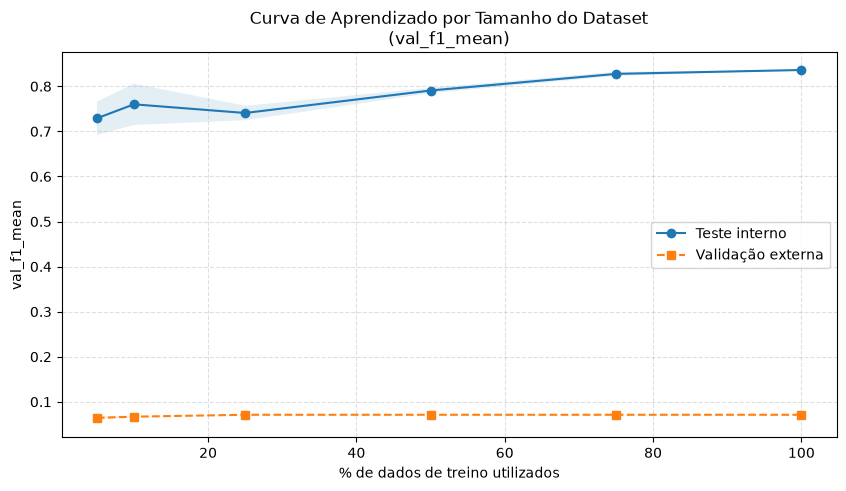

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=voyage__model_type=lof__pca_dim=300__reducer=pca__strategy=u_9f442a42/confusion_matrix_evolution.png


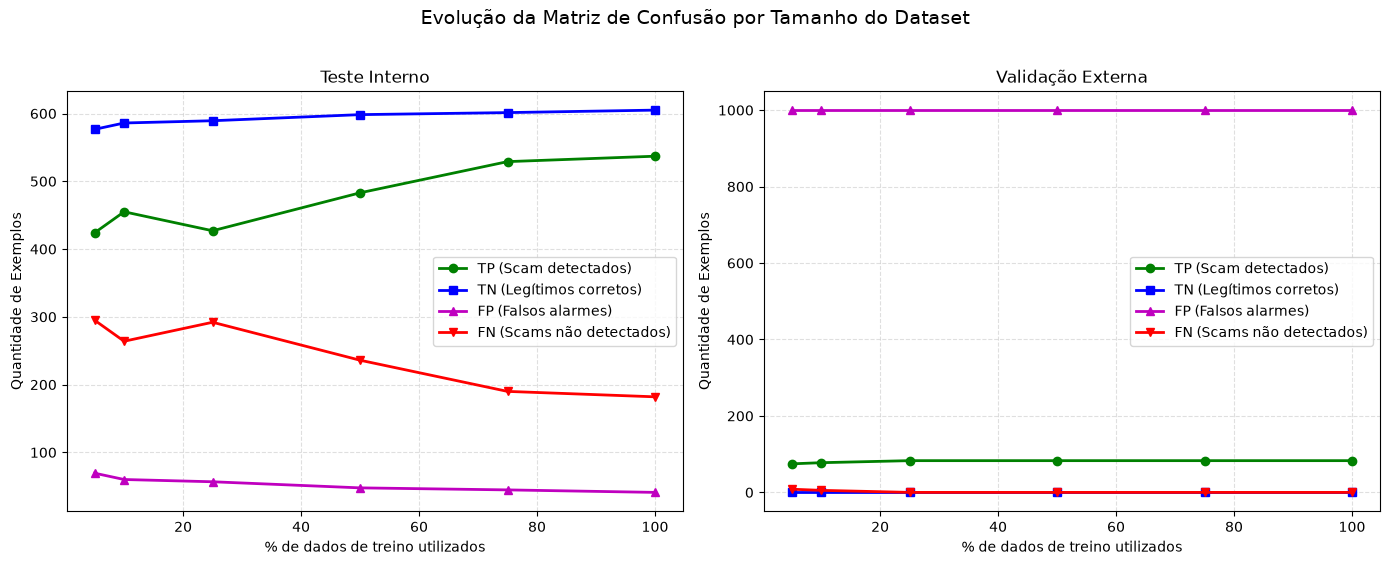

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=voyage__model_type=lof__pca_dim=300__reducer=pca__strategy=u_9f442a42/confusion_matrices_by_fraction.png


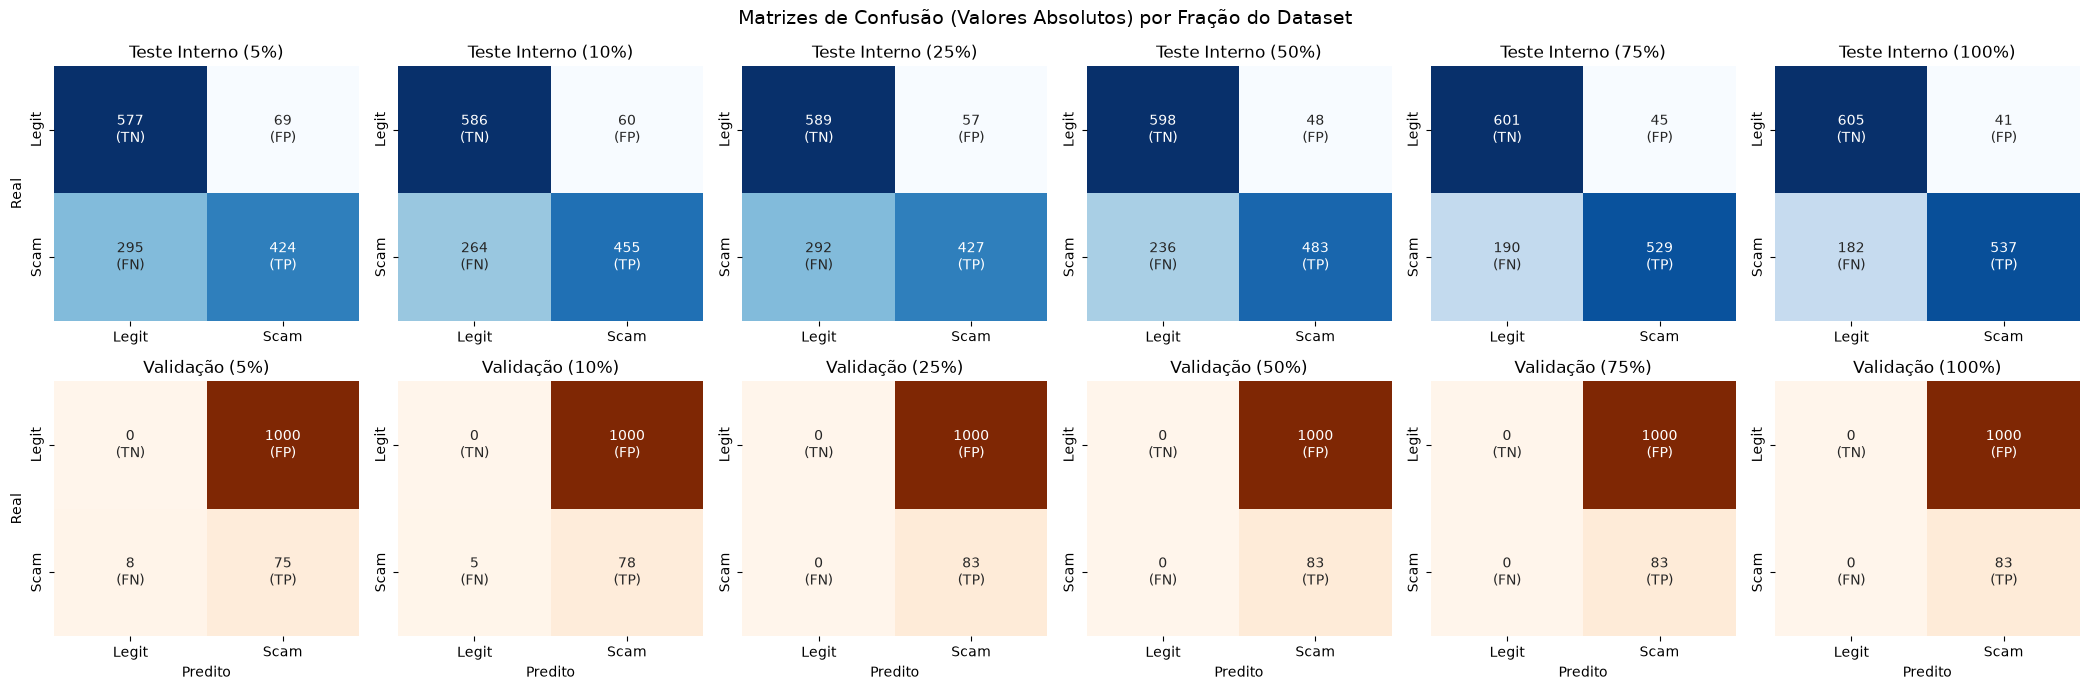


==================== LOF — OPENAI ====================
[unsupervised_lc] Cache hit — curva de aprendizado
  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=openai__model_type=lof__pca_dim=300__reducer=pca__strategy=u_7ceef200/dataset_size_curve.png


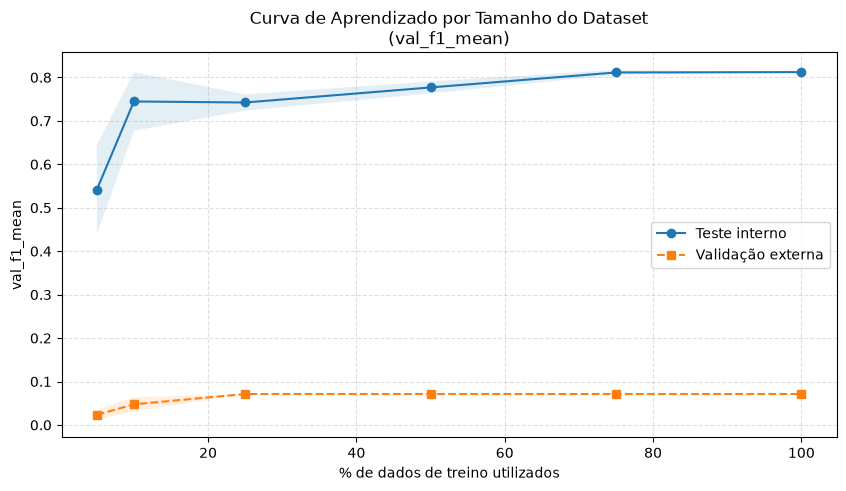

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=openai__model_type=lof__pca_dim=300__reducer=pca__strategy=u_7ceef200/confusion_matrix_evolution.png


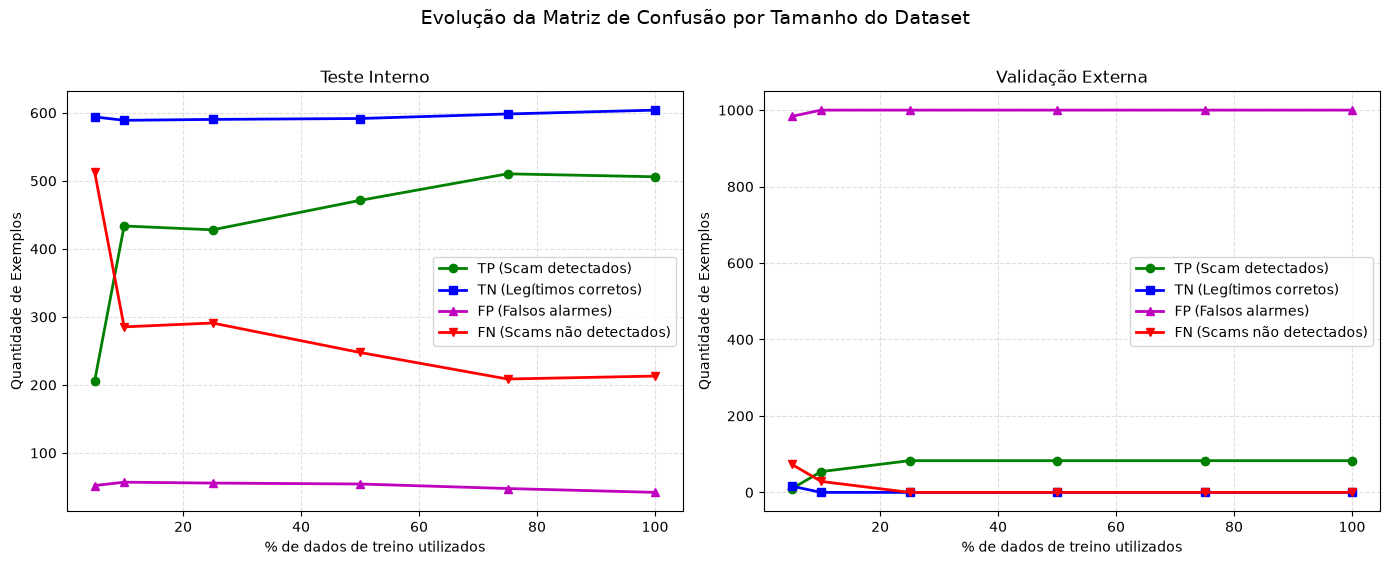

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=openai__model_type=lof__pca_dim=300__reducer=pca__strategy=u_7ceef200/confusion_matrices_by_fraction.png


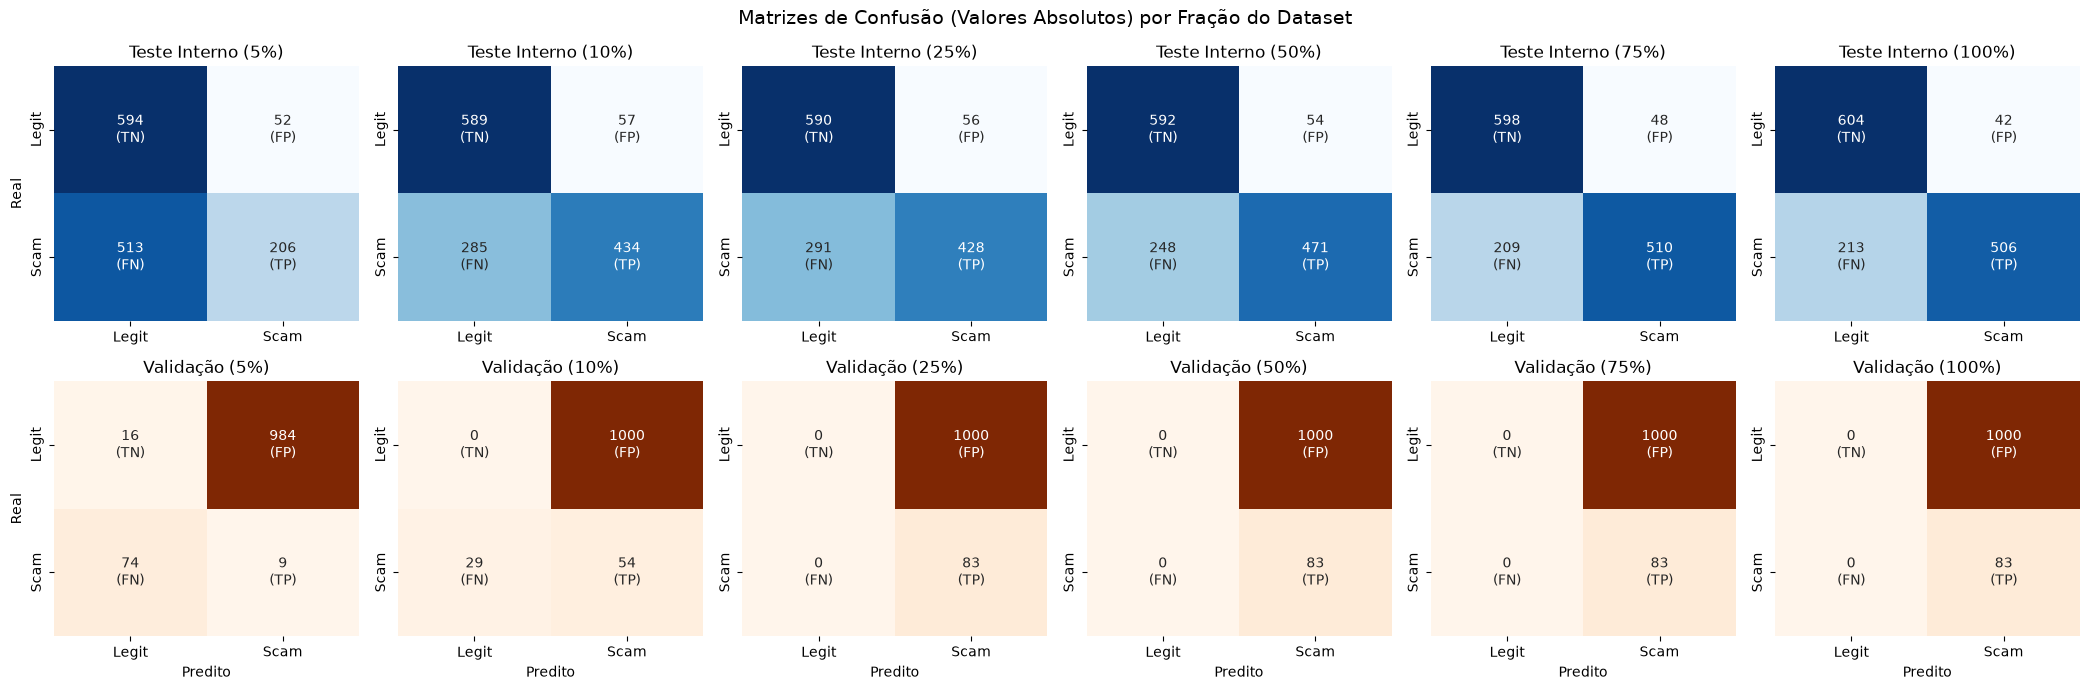


==================== LOF — BGE ====================
[unsupervised_lc] Cache hit — curva de aprendizado
  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=bge__model_type=lof__pca_dim=300__reducer=pca__strategy=unsu_5e70bb87/dataset_size_curve.png


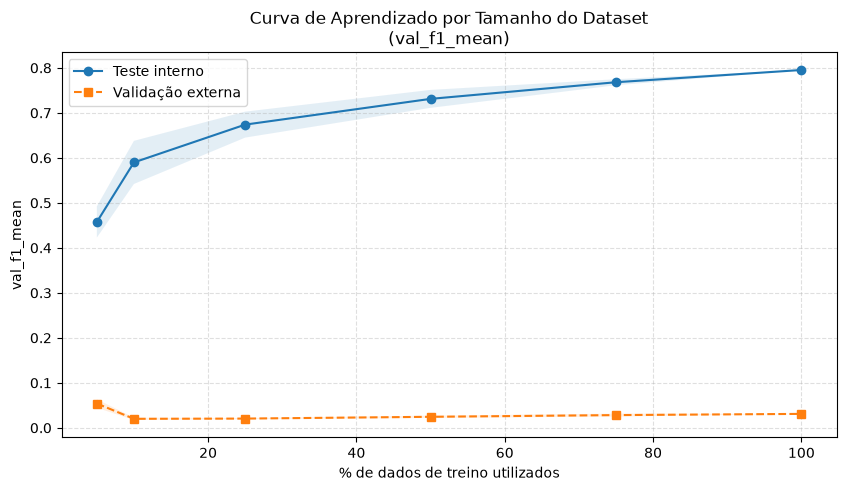

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=bge__model_type=lof__pca_dim=300__reducer=pca__strategy=unsu_5e70bb87/confusion_matrix_evolution.png


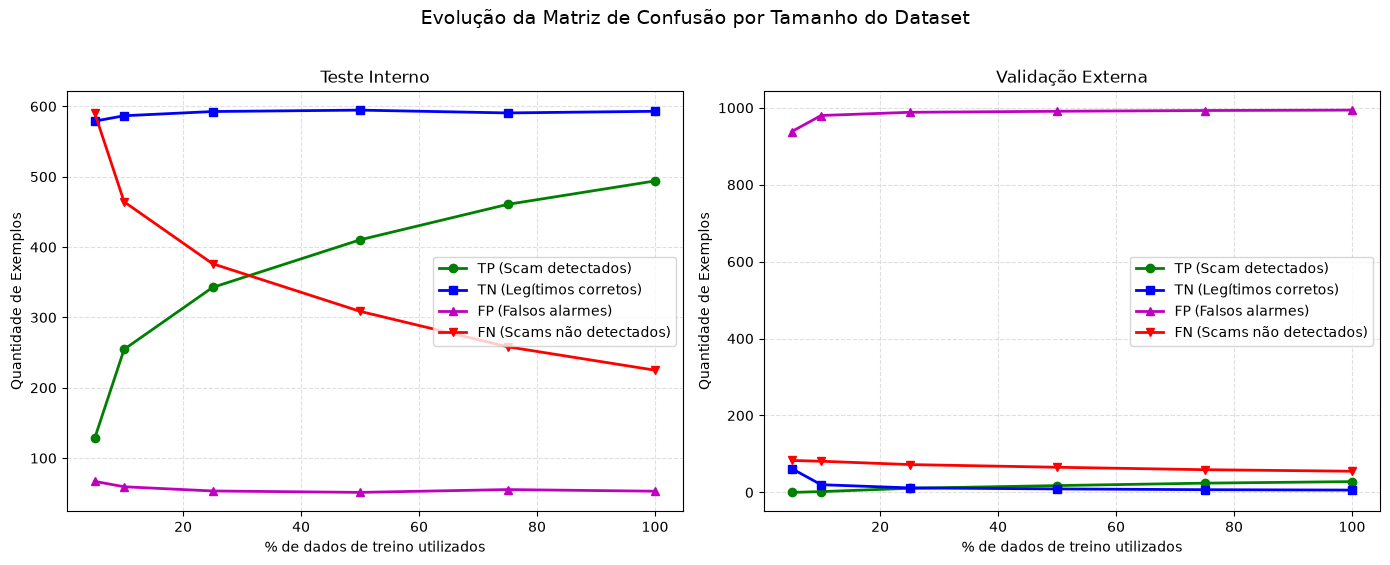

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=bge__model_type=lof__pca_dim=300__reducer=pca__strategy=unsu_5e70bb87/confusion_matrices_by_fraction.png


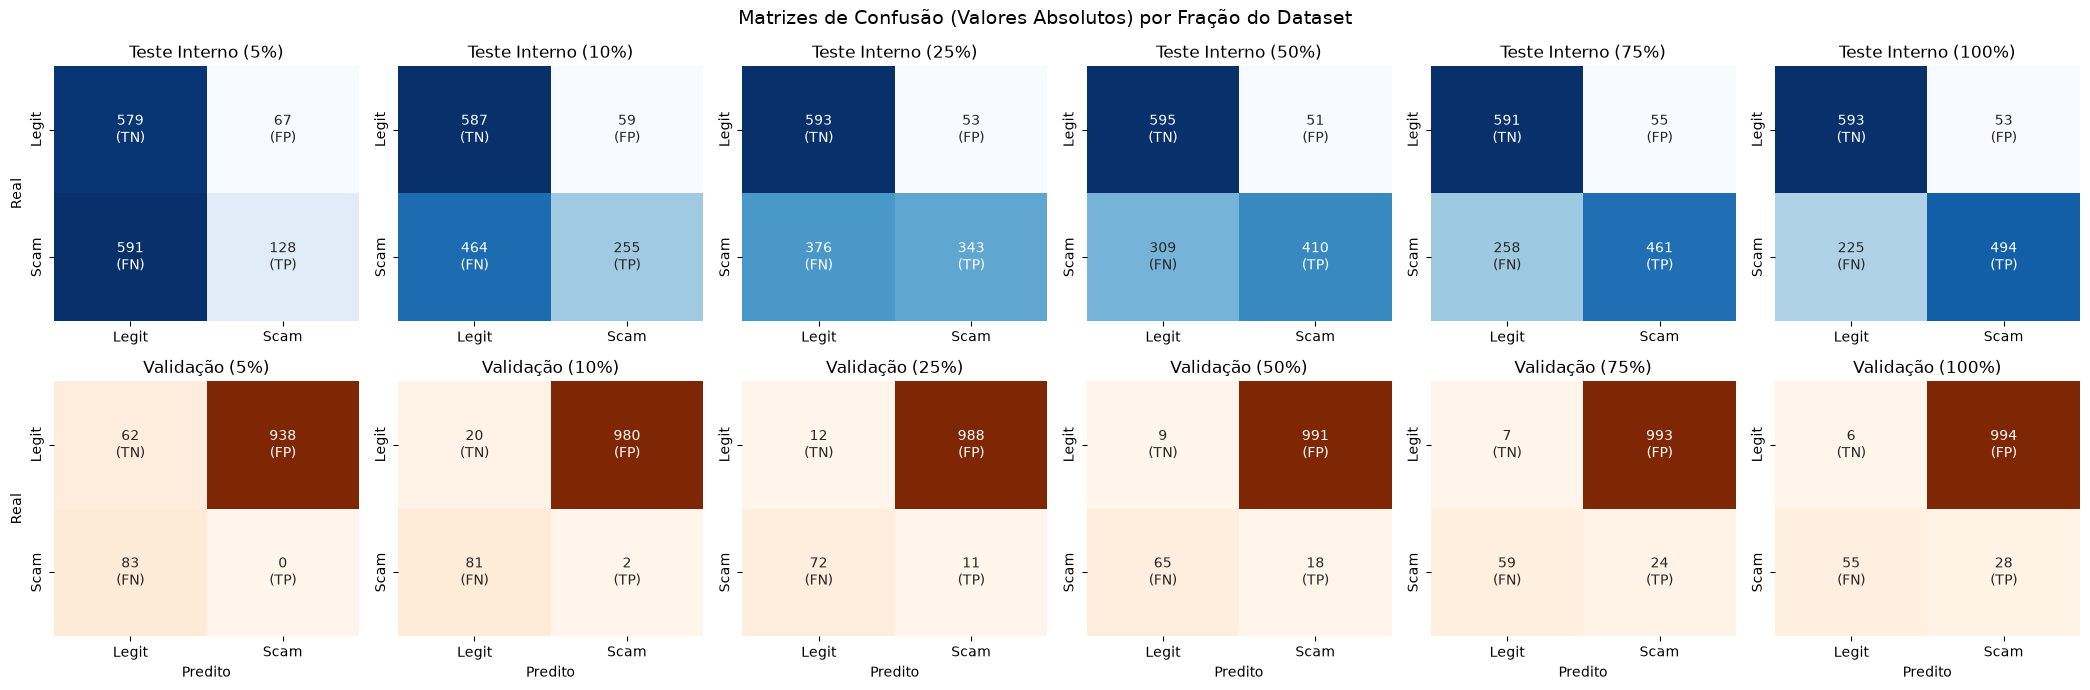


==================== LOF — E5 ====================
[unsupervised_lc] Cache hit — curva de aprendizado
  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=e5__model_type=lof__pca_dim=300__reducer=pca__strategy=unsup_89f5cf8b/dataset_size_curve.png


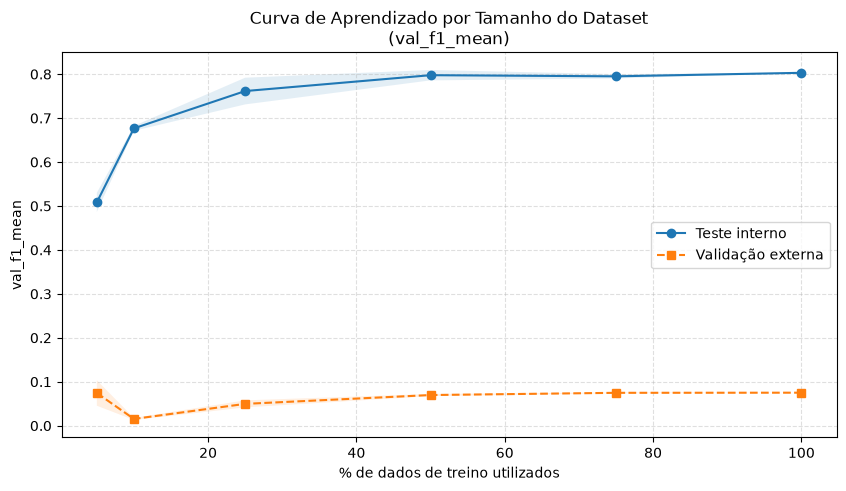

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=e5__model_type=lof__pca_dim=300__reducer=pca__strategy=unsup_89f5cf8b/confusion_matrix_evolution.png


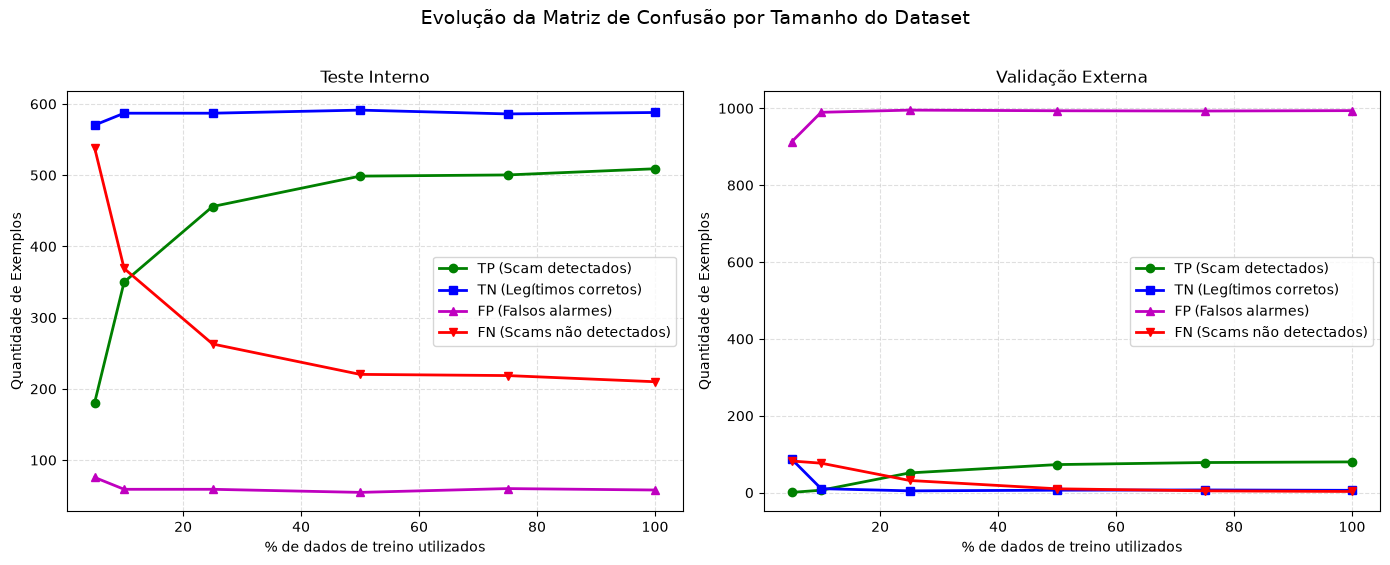

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=e5__model_type=lof__pca_dim=300__reducer=pca__strategy=unsup_89f5cf8b/confusion_matrices_by_fraction.png


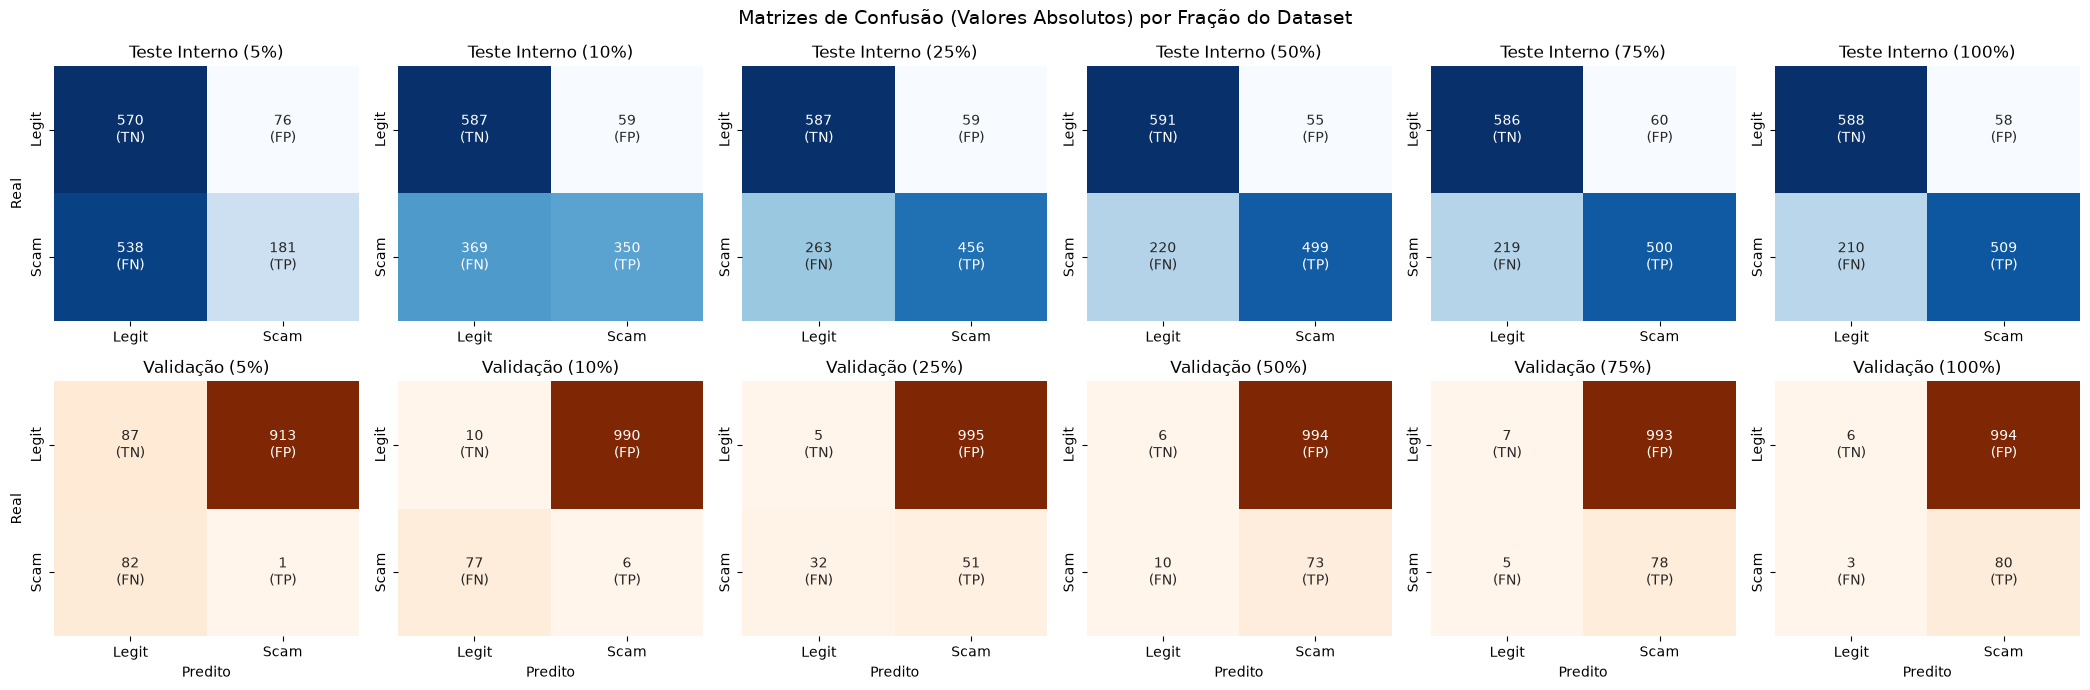


==================== LOF — MINILM ====================
[unsupervised_lc] Cache hit — curva de aprendizado
  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=minilm__model_type=lof__pca_dim=300__reducer=pca__strategy=u_c457cd1b/dataset_size_curve.png


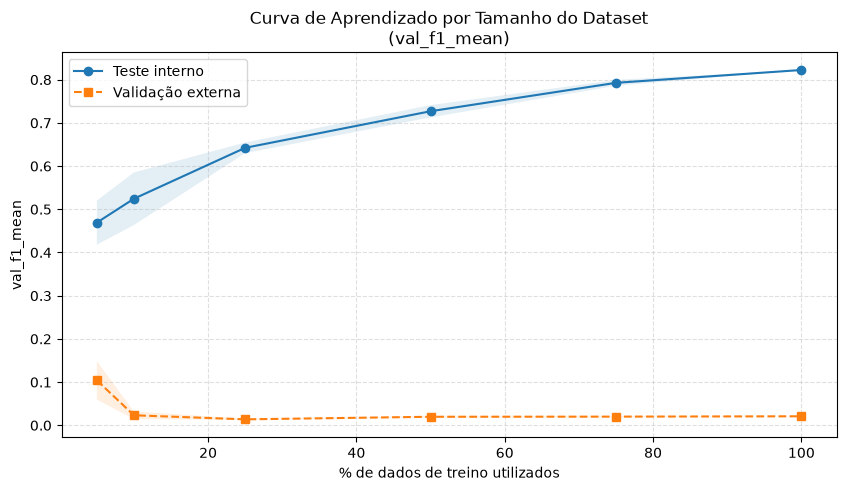

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=minilm__model_type=lof__pca_dim=300__reducer=pca__strategy=u_c457cd1b/confusion_matrix_evolution.png


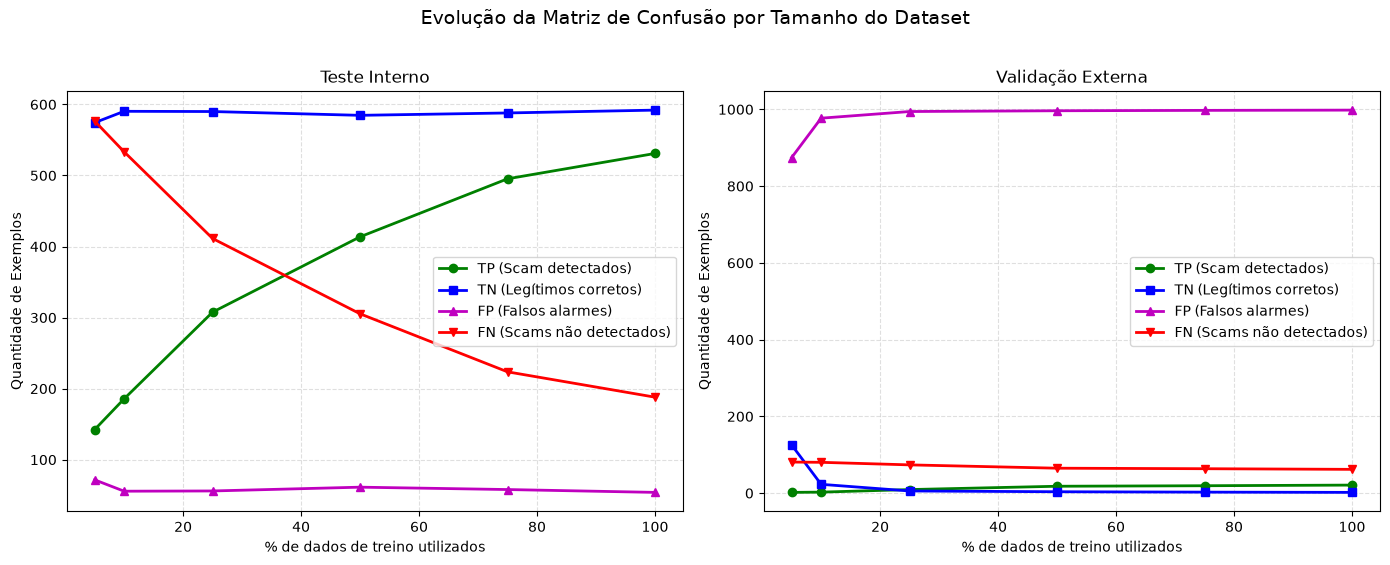

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=minilm__model_type=lof__pca_dim=300__reducer=pca__strategy=u_c457cd1b/confusion_matrices_by_fraction.png


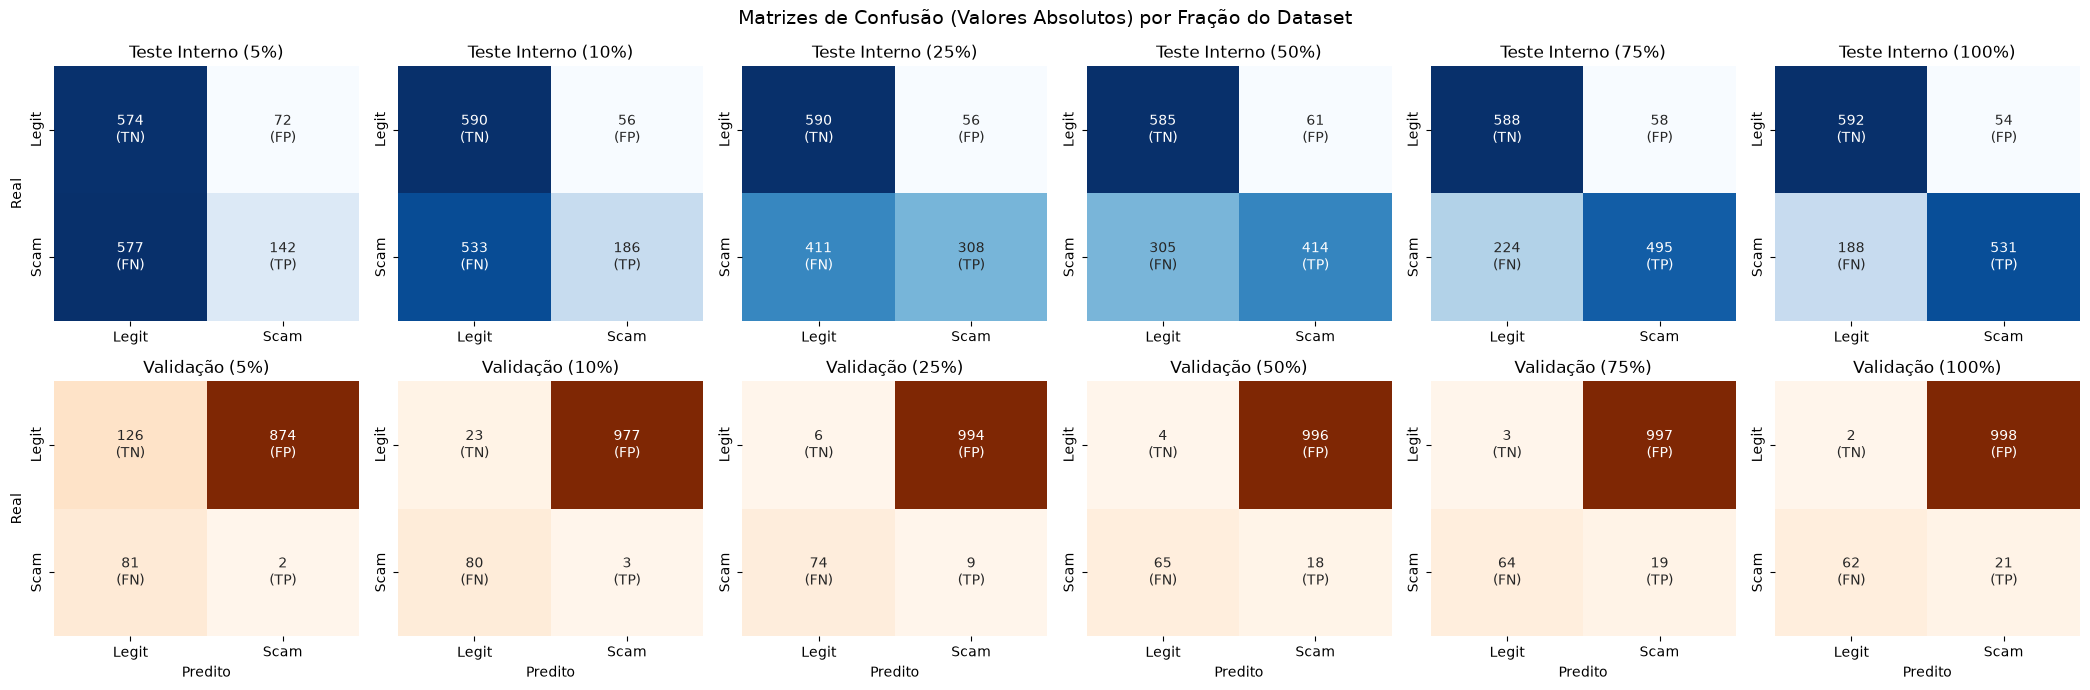

In [17]:
# Curva de aprendizado LOF para todos os embeddings
for emb in EMBEDDINGS:
    print(f"\n==================== LOF — {emb.upper()} ====================")
    lc = learning_curve_anomaly(
        embedding=emb,
        model_type="lof",
        pca_dim=300,
        train_sizes=[0.05, 0.10, 0.25, 0.50, 0.75, 1.00],
        n_repeats=3,
    )
    lc.plot_dataset_size_curve(metric="val_f1_mean")
    lc.plot_confusion_matrix_evolution()
    lc.plot_confusion_matrices_by_fraction()


## 8. LUNAR — Unifying Local Outlier Detection Methods via GNN

Aprende (via rede neural) a combinar distâncias aos vizinhos mais próximos, generalizando kNN/LOF (PyOD). Ver README seção 2.4.

### 8.1 Grid Search de hiperparâmetros (validação interna)


In [18]:
# Grid Search de hiperparâmetros LUNAR no embedding bge (validação interna escolhe o melhor combo)
gs_lunar = grid_search_anomaly(
    embedding="bge",
    model_type="lunar",
    pca_dim=300,
    param_grid={
        "n_neighbors": [5, 10, 20],
        "epsilon": [0.05, 0.1, 0.2],
        "contamination": [0.05, 0.10, 0.15],
    },
    force_recompute=FORCE_GRID_SEARCH,
)
display(gs_lunar.df_history.sort_values("internal_val_f1", ascending=False).head(10))


[unsupervised_gs] Cache hit — grid search


,n_neighbors,epsilon,contamination,internal_val_f1,internal_val_recall_scam,internal_val_roc_auc,internal_val_pr_auc,test_f1,test_recall_scam,test_roc_auc,test_pr_auc,external_val_f1,external_val_recall_scam,external_val_roc_auc,external_val_pr_auc
0,5,0.05,0.15,0.7526,0.7194,0.8520,0.7807,0.7619,0.7274,0.8587,0.8008,0.0325,0.3976,0.0064,0.0399
1,10,0.10,0.05,0.7276,0.6722,0.8452,0.7760,0.7315,0.6579,0.8552,0.8016,0.0254,0.3133,0.0059,0.0399
2,20,0.05,0.10,0.7193,0.5944,0.8758,0.8059,0.7083,0.5786,0.8699,0.8172,0.0266,0.2651,0.0076,0.0399
3,5,0.10,0.15,0.7022,0.5889,0.8354,0.7662,0.6921,0.5758,0.8476,0.7929,0.0219,0.2410,0.0059,0.0399
4,5,0.20,0.15,0.7012,0.5972,0.8326,0.7620,0.6938,0.5814,0.8456,0.7921,0.0247,0.2651,0.0062,0.0399
5,10,0.10,0.15,0.6961,0.5806,0.8291,0.7633,0.6825,0.5549,0.8419,0.7895,0.0239,0.2289,0.0056,0.0399
6,10,0.20,0.15,0.6946,0.5778,0.8271,0.7620,0.6842,0.5605,0.8409,0.7891,0.0238,0.2410,0.0057,0.0399
7,10,0.05,0.10,0.6944,0.5222,0.8763,0.8060,0.6621,0.4771,0.8706,0.8176,0.0221,0.1687,0.0070,0.0399
8,10,0.05,0.15,0.6884,0.5167,0.8735,0.8024,0.6584,0.4743,0.8667,0.8118,0.0240,0.1807,0.0076,0.0399
9,20,0.05,0.15,0.6880,0.5611,0.8319,0.7628,0.6824,0.5535,0.8458,0.7920,0.0230,0.2048,0.0057,0.0399


### 8.2 Treino em todos os embeddings (métricas de treino e validação)


In [19]:
# Treino de LUNAR para todos os embeddings (dim = 300), já com os melhores hiperparâmetros por embedding
df_lunar_all, results_lunar = train_all_tuned(model_type="lunar", pca_dim=300, embeddings=EMBEDDINGS, path_data=PATH_DATA)
print("=== LUNAR (300d, hiperparâmetros tunados) — Teste Interno (holdout) e Validação Externa (vida real) ===")
display(df_lunar_all[[
    "embedding", "best_params", "test_acc", "test_f1_macro", "test_recall_scam", "test_precision_scam", "test_roc_auc", "test_pr_auc",
    "val_acc", "val_f1_macro", "val_recall_scam", "val_precision_scam", "val_roc_auc", "val_pr_auc",
]])


[unsupervised_gs] Cache hit — grid search
[unsupervised] Cache hit: voyage_lunar_300 (params=cea585fa)
[cache] Carregando LUNAR + PCA (300d): voyage
[unsupervised_gs] Cache hit — grid search
[unsupervised] Cache hit: openai_lunar_300 (params=9870c790)
[cache] Carregando LUNAR + PCA (300d): openai
[unsupervised_gs] Cache hit — grid search
[unsupervised] Cache hit: bge_lunar_300 (params=50556649)
[cache] Carregando LUNAR + PCA (300d): bge
[unsupervised_gs] Cache hit — grid search
[unsupervised] Cache hit: e5_lunar_300 (params=054d4bf0)
[cache] Carregando LUNAR + PCA (300d): e5
[unsupervised_gs] Cache hit — grid search
[unsupervised] Cache hit: minilm_lunar_300 (params=5eaad00e)
[cache] Carregando LUNAR + PCA (300d): minilm
=== LUNAR (300d, hiperparâmetros tunados) — Teste Interno (holdout) e Validação Externa (vida real) ===


,embedding,best_params,test_acc,test_f1_macro,test_recall_scam,test_precision_scam,test_roc_auc,test_pr_auc,val_acc,val_f1_macro,val_recall_scam,val_precision_scam,val_roc_auc,val_pr_auc
0,voyage,"{'n_neighbors': 5, 'epsilon': 0.2, 'contaminat...",0.7993,0.7986,0.7024,0.8938,0.9352,0.9268,0.0766,0.0712,1.0000,0.0766,0.7240,0.2401
1,openai,"{'n_neighbors': 5, 'epsilon': 0.1, 'contaminat...",0.5238,0.4510,0.1516,0.7315,0.8710,0.8074,0.0711,0.0666,0.9157,0.0707,0.1999,0.0471
2,bge,"{'n_neighbors': 5, 'epsilon': 0.05, 'contamina...",0.8366,0.8311,0.9666,0.7774,0.8595,0.8057,0.0526,0.0500,0.6867,0.0539,0.0071,0.0399
3,e5,"{'n_neighbors': 10, 'epsilon': 0.1, 'contamina...",0.7714,0.7712,0.7024,0.8375,0.8947,0.8775,0.0434,0.0422,0.5181,0.0414,0.0105,0.0400
4,minilm,"{'n_neighbors': 5, 'epsilon': 0.1, 'contaminat...",0.7956,0.7945,0.8234,0.7957,0.8391,0.7794,0.0351,0.0339,0.4578,0.0366,0.0250,0.0401


In [20]:
# Melhor embedding para LUNAR (por val_f1_macro) — reusa o resultado (e o cache) já calculado acima
best_emb_lunar = df_lunar_all.sort_values("val_f1_macro", ascending=False).iloc[0]["embedding"]
print(f"Melhor embedding para LUNAR: {best_emb_lunar}")

res_lunar = results_lunar[best_emb_lunar]
res_lunar.print_metrics()
res_lunar.plot_confusion_matrix(title=f"LUNAR ({best_emb_lunar}) — Validação Externa")
res_lunar.plot_roc_curve()
res_lunar.plot_precision_recall_curve()


Melhor embedding para LUNAR: voyage
  model_name        dataset_name  accuracy  f1_macro  f1_scam  recall_scam  precision_scam  roc_auc  pr_auc   TP   TN   FP  FN
LUNAR_voyage               train    0.8439    0.8430   0.8306       0.7260          0.9702   0.9823  0.9800 1826 2203   56 689
LUNAR_voyage                 val    0.8053    0.8048   0.7957       0.7194          0.8900   0.9340  0.9208  259  291   32 101
LUNAR_voyage                test    0.7993    0.7986   0.7866       0.7024          0.8938   0.9352  0.9268  505  586   60 214
LUNAR_voyage validation_external    0.0766    0.0712   0.1424       1.0000          0.0766   0.7240  0.2401   83    0 1000   0
Sem predições para plotar.
Sem probabilidades para plotar curva ROC.
Sem probabilidades para plotar curva PR.


### 8.4 Curva de aprendizado (todos os embeddings)



==================== LUNAR — VOYAGE ====================
[unsupervised_lc] Cache hit — curva de aprendizado
  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=voyage__model_type=lunar__pca_dim=300__reducer=pca__strategy_797e5a9e/dataset_size_curve.png


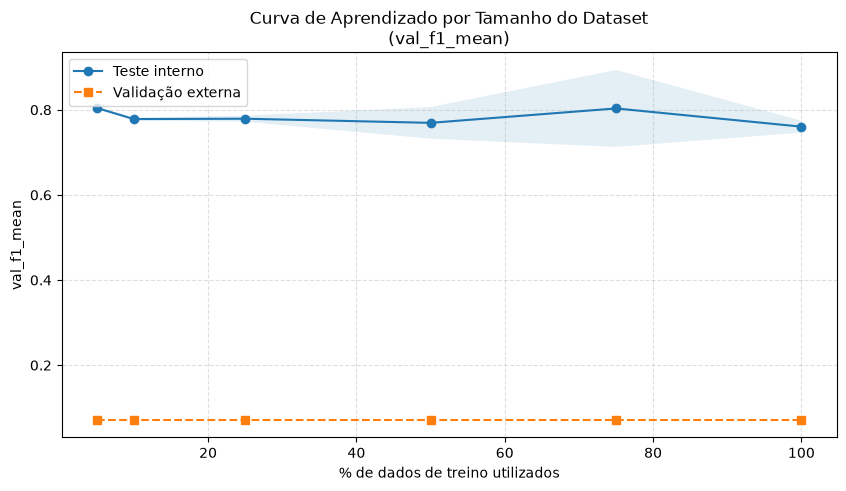

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=voyage__model_type=lunar__pca_dim=300__reducer=pca__strategy_797e5a9e/confusion_matrix_evolution.png


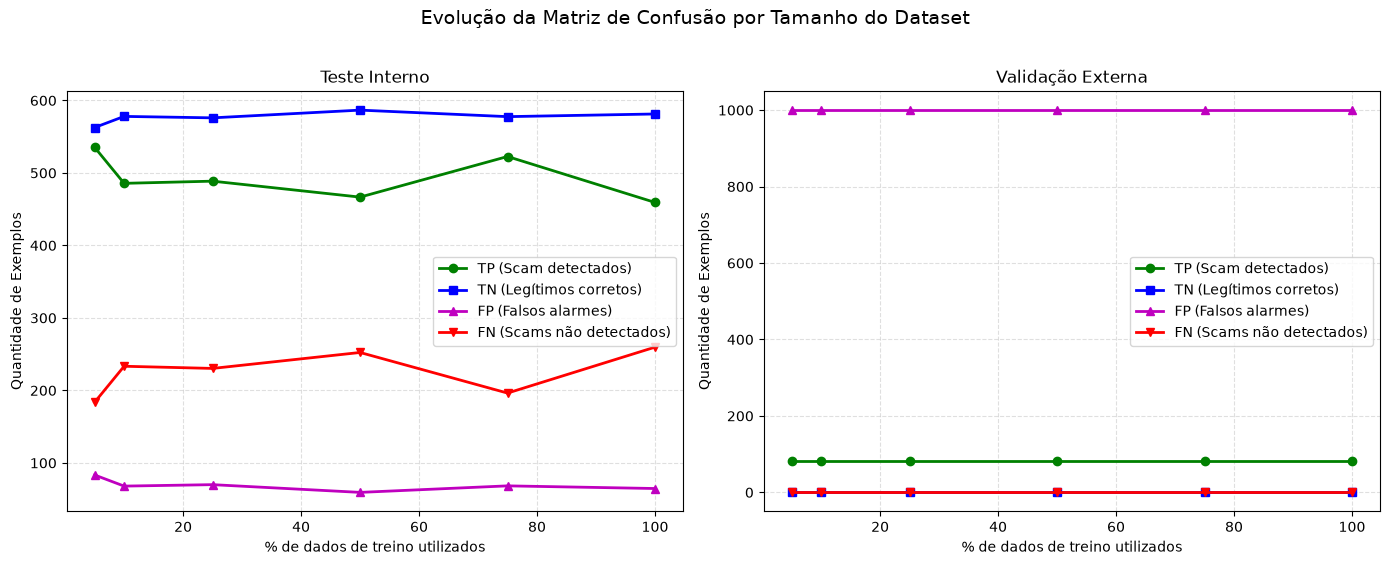

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=voyage__model_type=lunar__pca_dim=300__reducer=pca__strategy_797e5a9e/confusion_matrices_by_fraction.png


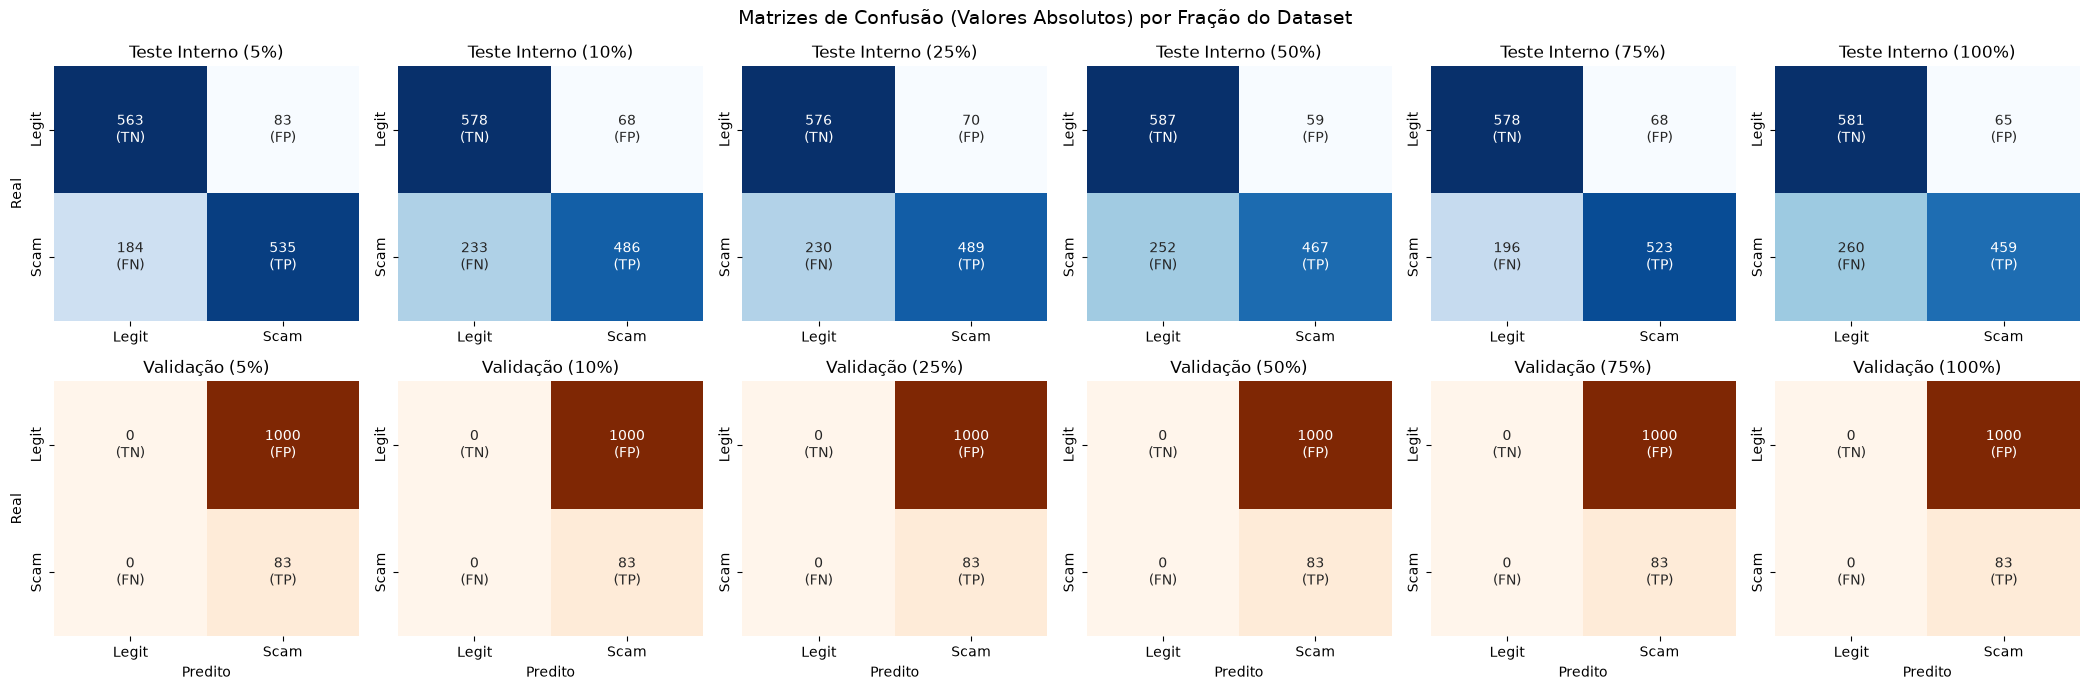


==================== LUNAR — OPENAI ====================
[unsupervised_lc] Cache hit — curva de aprendizado
  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=openai__model_type=lunar__pca_dim=300__reducer=pca__strategy_5086a317/dataset_size_curve.png


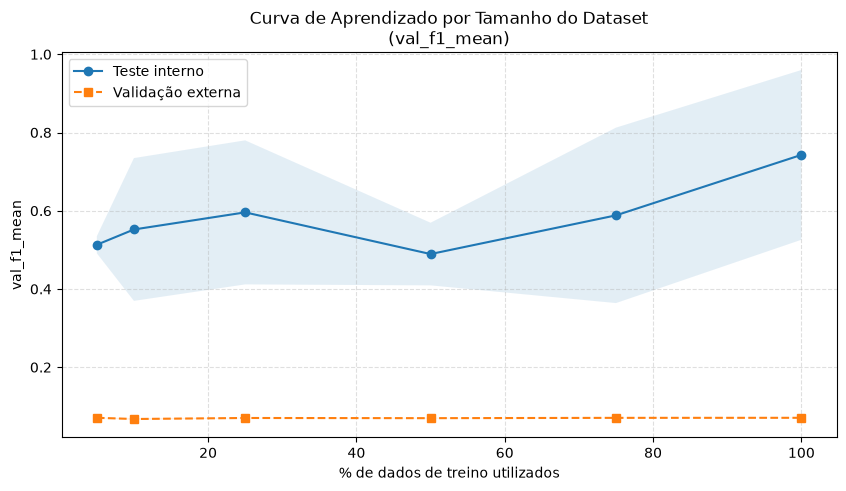

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=openai__model_type=lunar__pca_dim=300__reducer=pca__strategy_5086a317/confusion_matrix_evolution.png


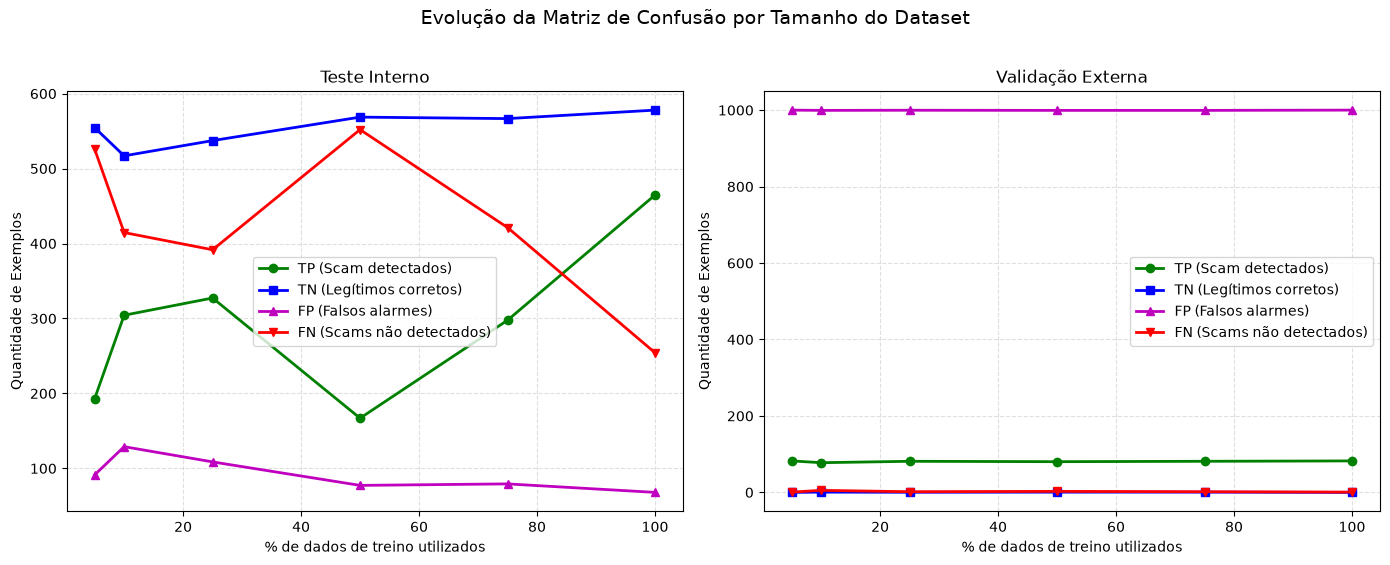

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=openai__model_type=lunar__pca_dim=300__reducer=pca__strategy_5086a317/confusion_matrices_by_fraction.png


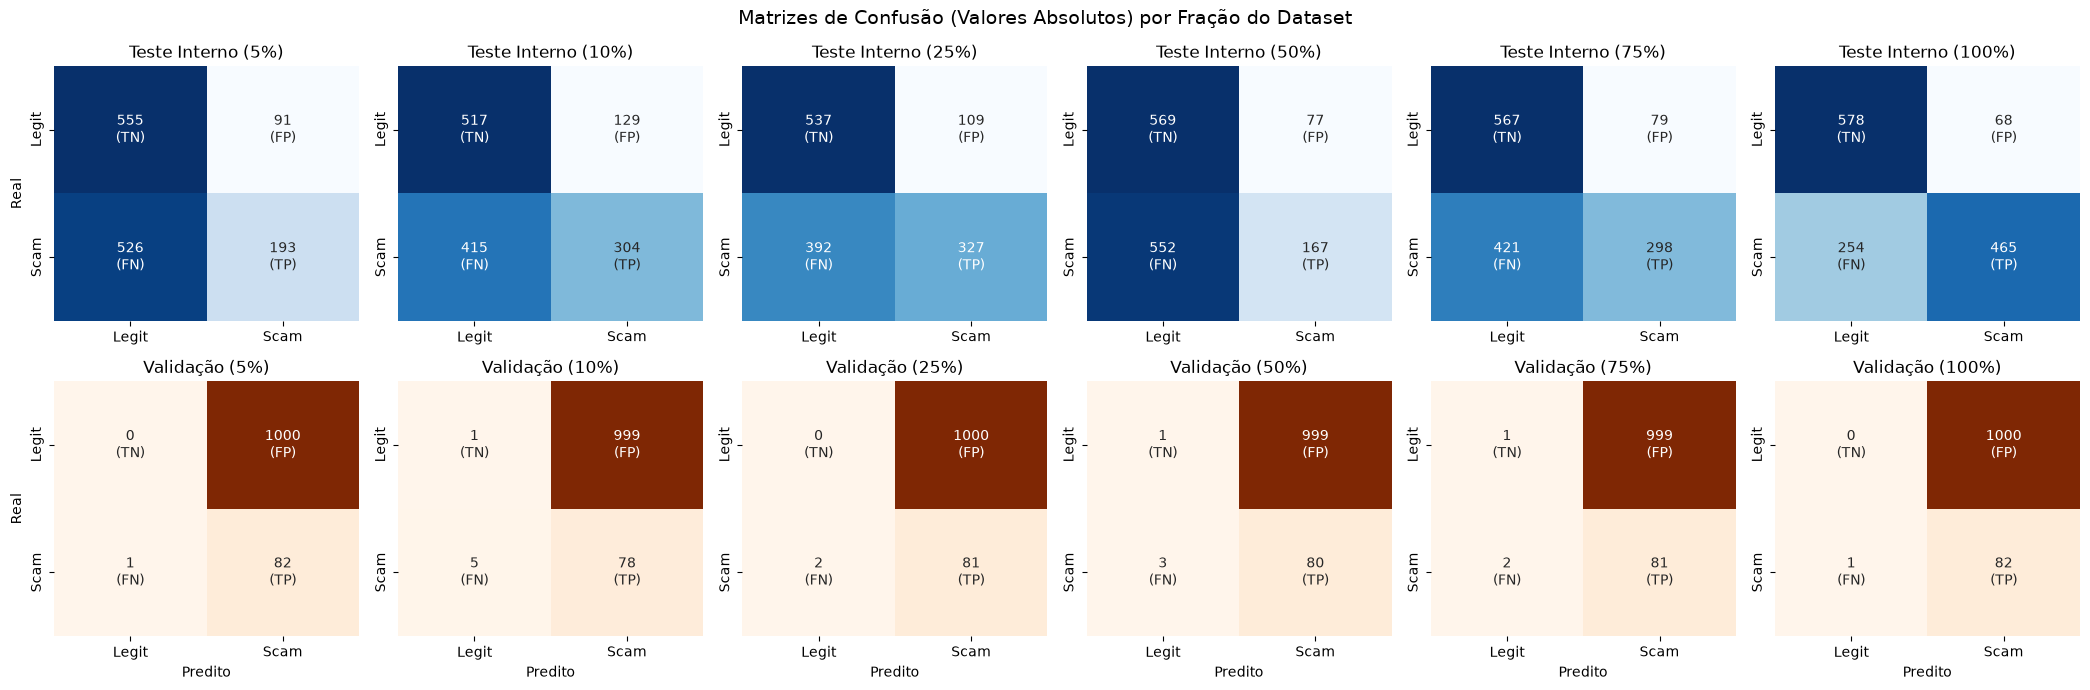


==================== LUNAR — BGE ====================
[unsupervised_lc] Cache hit — curva de aprendizado
  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=bge__model_type=lunar__pca_dim=300__reducer=pca__strategy=un_bf833634/dataset_size_curve.png


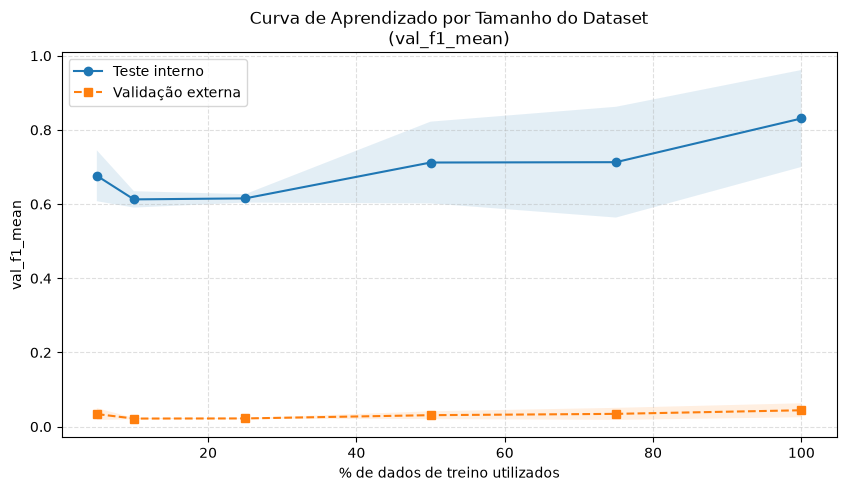

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=bge__model_type=lunar__pca_dim=300__reducer=pca__strategy=un_bf833634/confusion_matrix_evolution.png


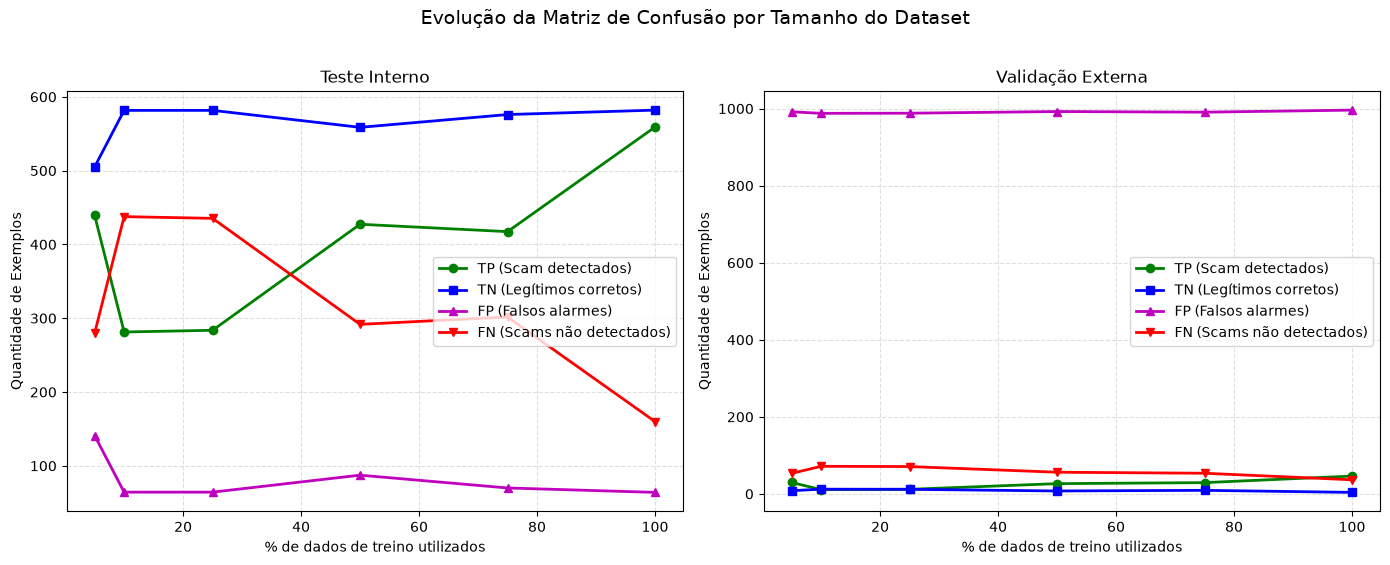

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=bge__model_type=lunar__pca_dim=300__reducer=pca__strategy=un_bf833634/confusion_matrices_by_fraction.png


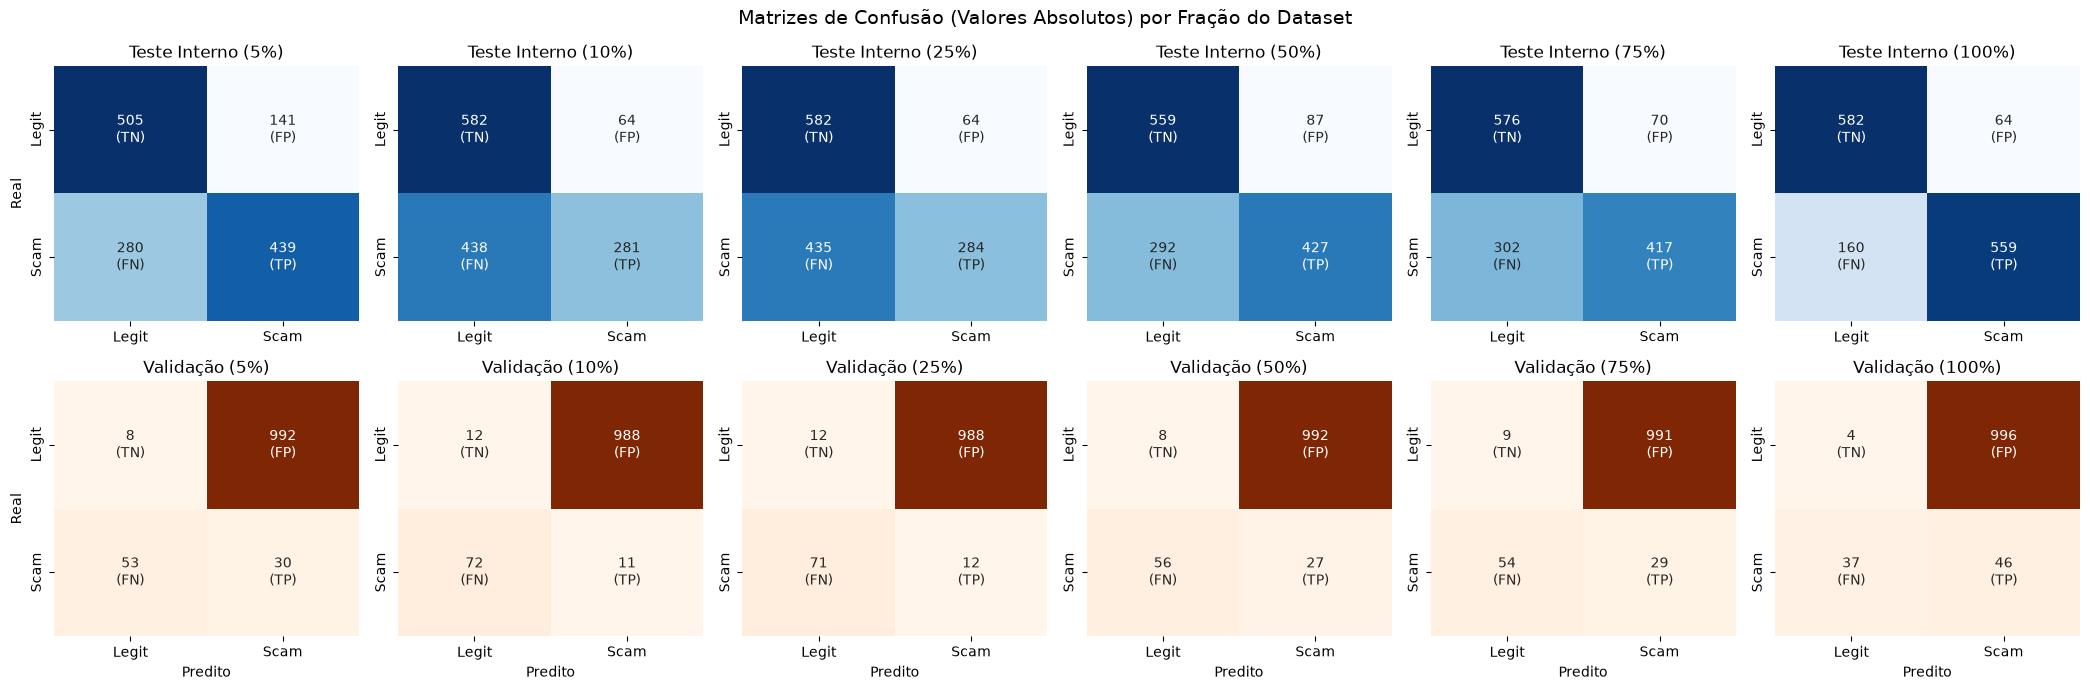


==================== LUNAR — E5 ====================
[unsupervised_lc] Cache hit — curva de aprendizado
  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=e5__model_type=lunar__pca_dim=300__reducer=pca__strategy=uns_07c9b323/dataset_size_curve.png


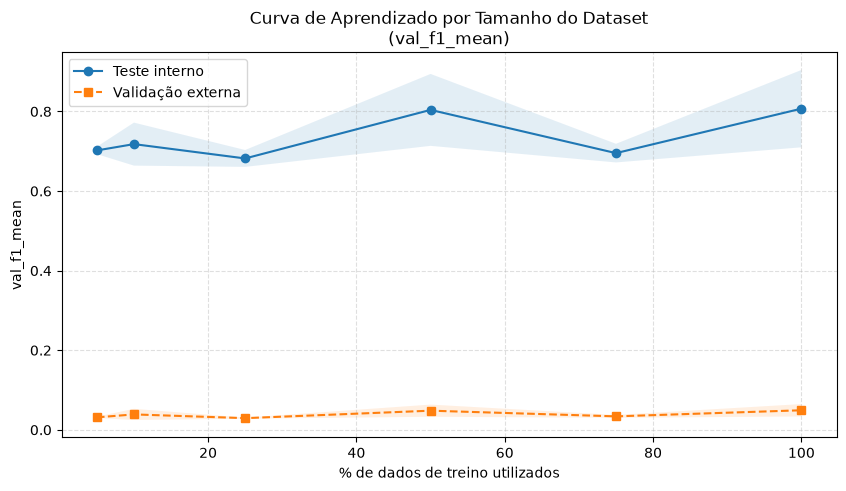

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=e5__model_type=lunar__pca_dim=300__reducer=pca__strategy=uns_07c9b323/confusion_matrix_evolution.png


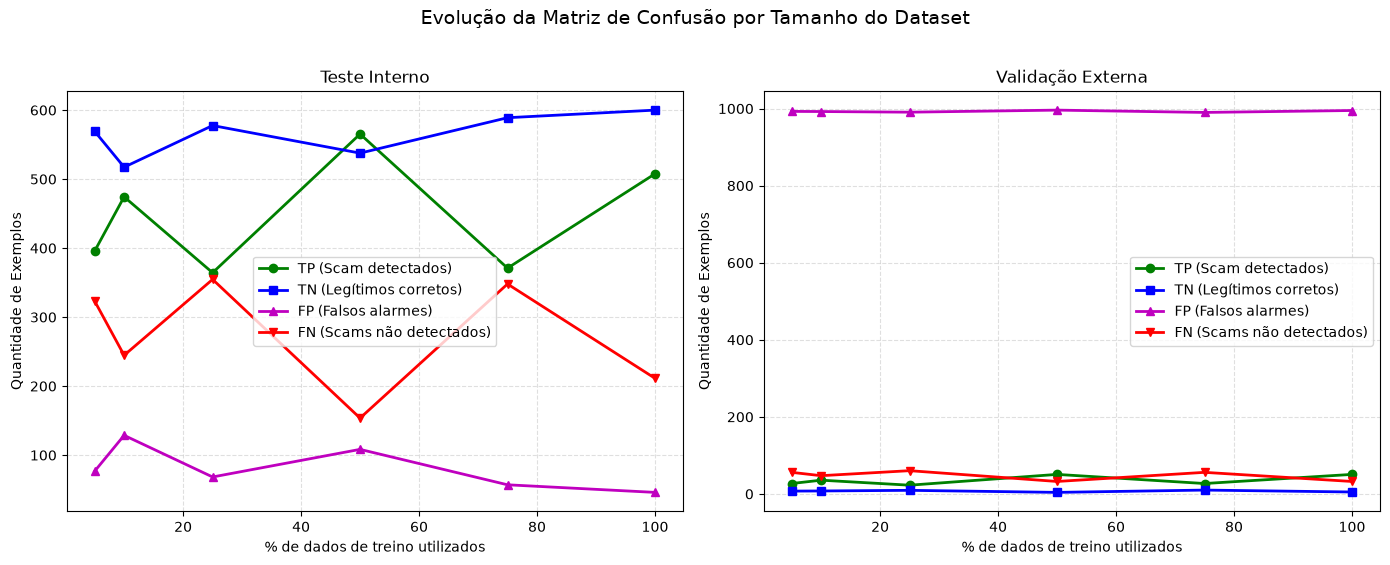

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=e5__model_type=lunar__pca_dim=300__reducer=pca__strategy=uns_07c9b323/confusion_matrices_by_fraction.png


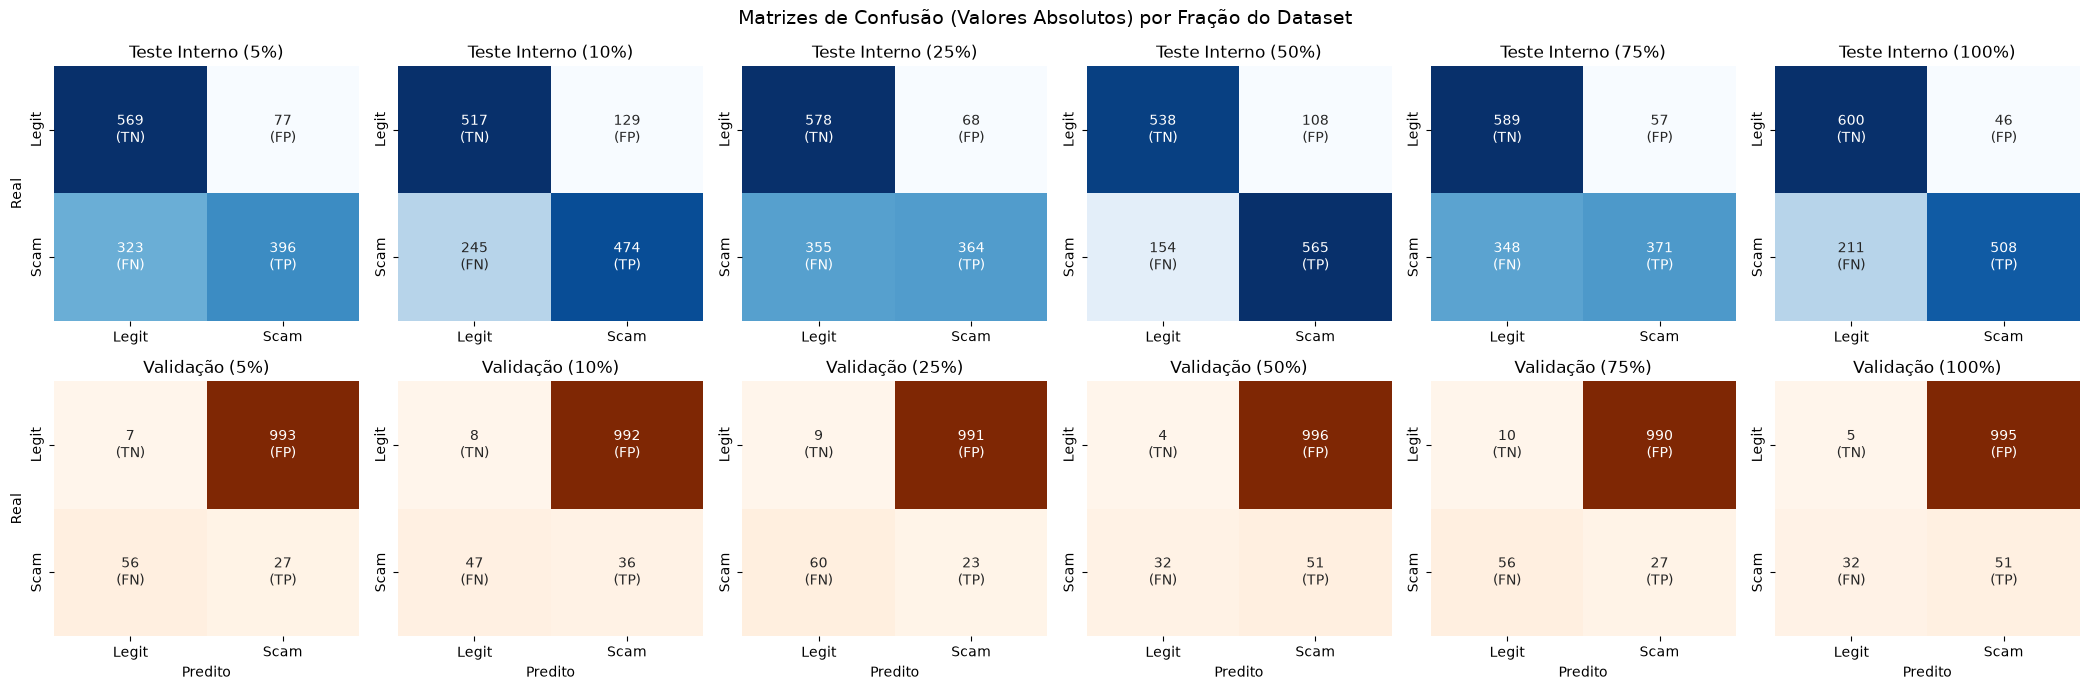


==================== LUNAR — MINILM ====================
[unsupervised_lc] Cache hit — curva de aprendizado
  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=minilm__model_type=lunar__pca_dim=300__reducer=pca__strategy_97041052/dataset_size_curve.png


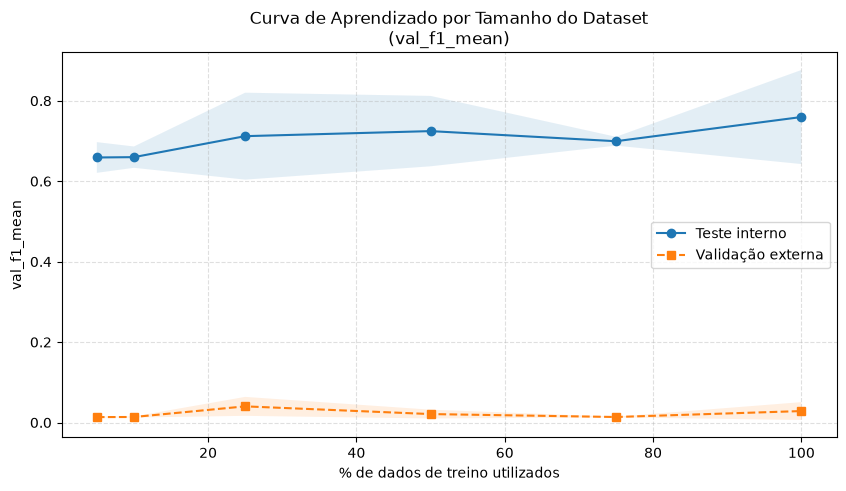

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=minilm__model_type=lunar__pca_dim=300__reducer=pca__strategy_97041052/confusion_matrix_evolution.png


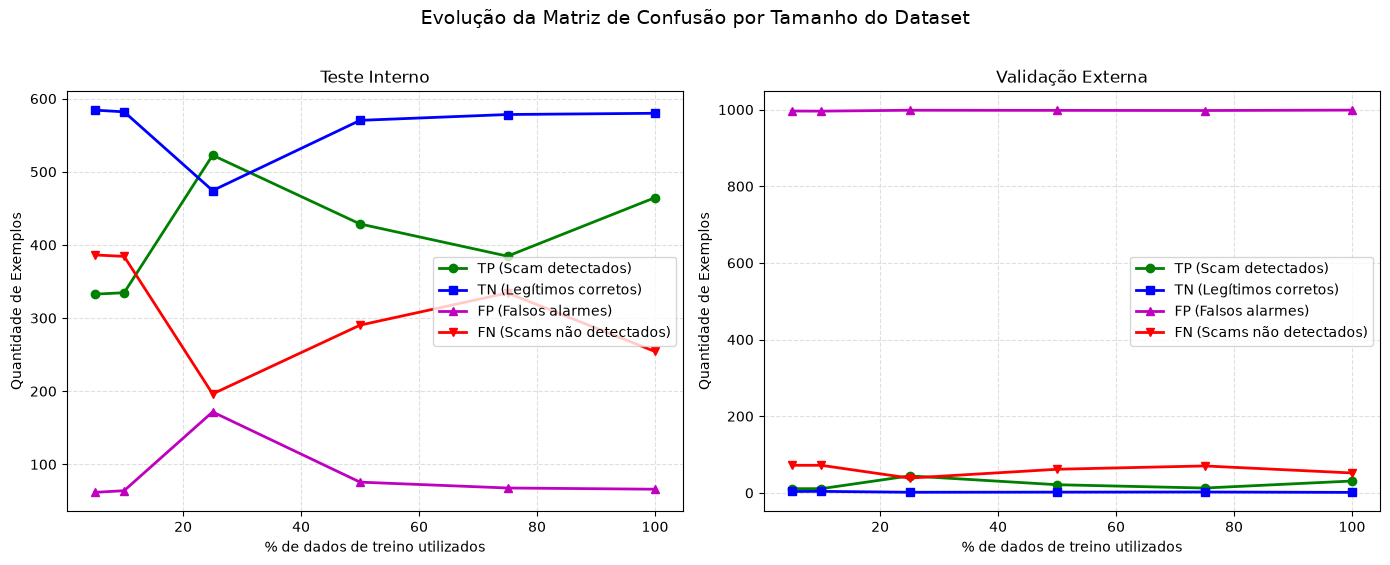

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=minilm__model_type=lunar__pca_dim=300__reducer=pca__strategy_97041052/confusion_matrices_by_fraction.png


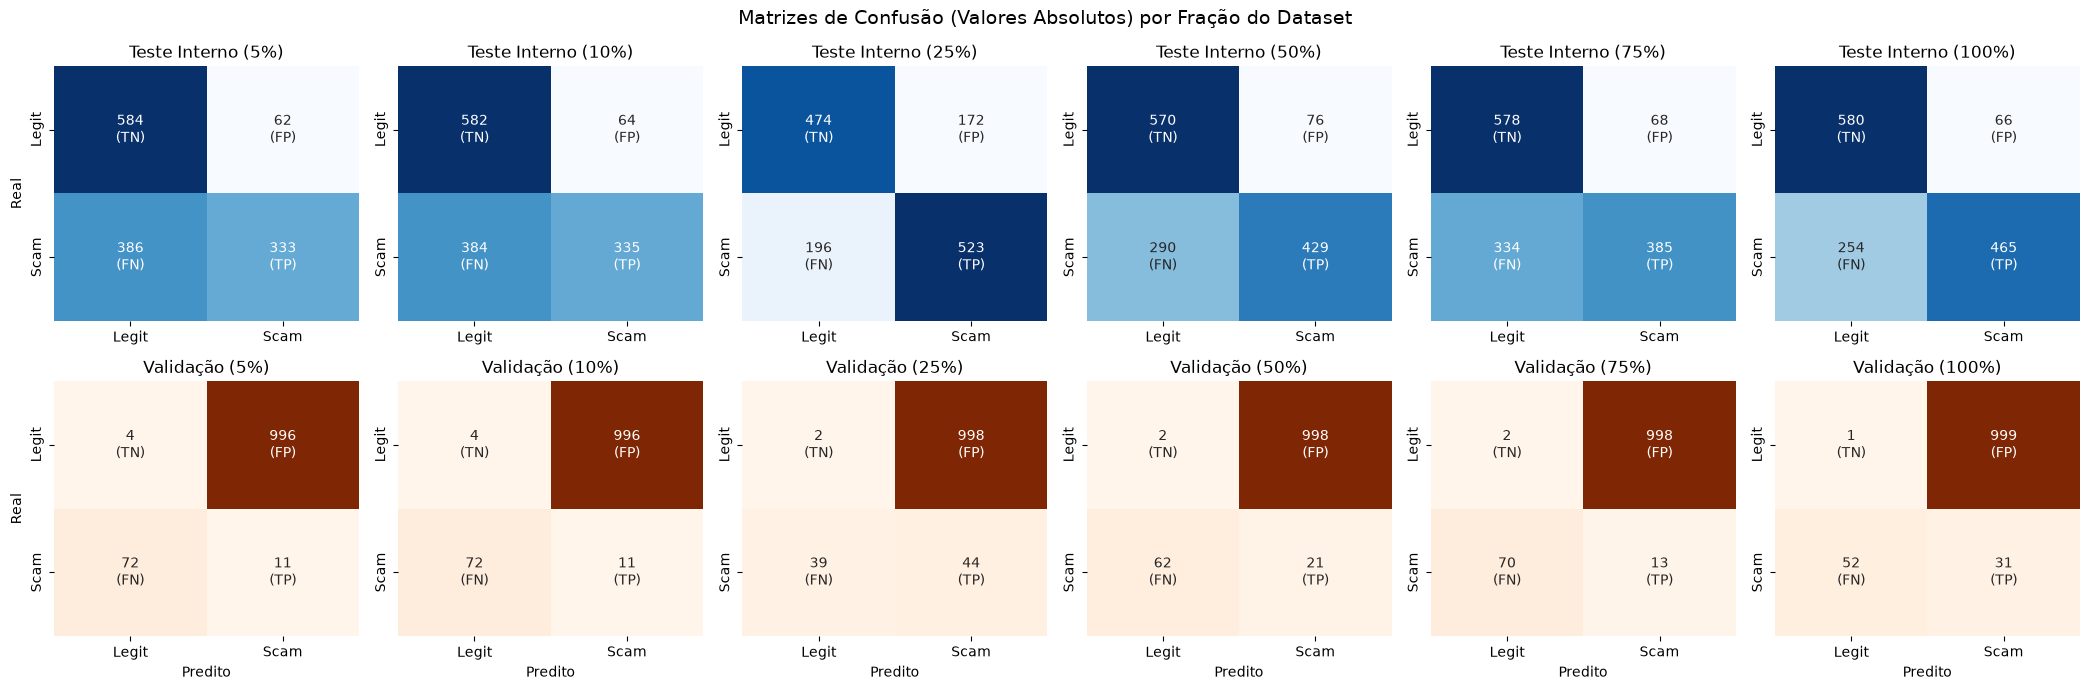

In [21]:
# Curva de aprendizado LUNAR para todos os embeddings
for emb in EMBEDDINGS:
    print(f"\n==================== LUNAR — {emb.upper()} ====================")
    lc = learning_curve_anomaly(
        embedding=emb,
        model_type="lunar",
        pca_dim=300,
        train_sizes=[0.05, 0.10, 0.25, 0.50, 0.75, 1.00],
        n_repeats=3,
    )
    lc.plot_dataset_size_curve(metric="val_f1_mean")
    lc.plot_confusion_matrix_evolution()
    lc.plot_confusion_matrices_by_fraction()


## 9. Deep SVDD — Support Vector Data Description Profunda

Encoder (MLP em PyTorch) que mapeia embeddings Ham para uma hiperesfera compacta no espaço latente (variante *soft-boundary*, `svdd_torch.py`). Ver README seção 2.5.

### 9.1 Grid Search de hiperparâmetros (validação interna)


In [22]:
# Grid Search de hiperparâmetros SVDD no embedding bge (validação interna escolhe o melhor combo)
gs_svdd = grid_search_anomaly(
    embedding="bge",
    model_type="svdd",
    pca_dim=300,
    param_grid={
        "nu": [0.05, 0.10, 0.15, 0.20],
        "latent_dim": [16, 32, 64],
        "lr": [1e-3, 5e-4],
    },
    force_recompute=FORCE_GRID_SEARCH,
)
display(gs_svdd.df_history.sort_values("internal_val_f1", ascending=False).head(10))


[unsupervised_gs] Cache hit — grid search


,nu,latent_dim,lr,internal_val_f1,internal_val_recall_scam,internal_val_roc_auc,internal_val_pr_auc,test_f1,test_recall_scam,test_roc_auc,test_pr_auc,external_val_f1,external_val_recall_scam,external_val_roc_auc,external_val_pr_auc
0,0.05,16,0.0010,0.7712,0.7694,0.8460,0.8603,0.7506,0.7441,0.8208,0.8532,0.4265,0.9759,0.9419,0.6945
1,0.05,64,0.0010,0.7657,0.7278,0.8397,0.8611,0.7406,0.7093,0.8390,0.8618,0.3624,0.9277,0.6596,0.1168
2,0.05,32,0.0010,0.7248,0.9194,0.8655,0.8741,0.6993,0.9068,0.8393,0.8630,0.2032,0.9639,0.7771,0.2335
3,0.10,16,0.0010,0.7184,0.9278,0.8574,0.8747,0.6845,0.9096,0.8435,0.8719,0.1913,0.9639,0.7733,0.3091
4,0.10,64,0.0010,0.7067,0.9333,0.8533,0.8737,0.6803,0.9124,0.8286,0.8489,0.1496,1.0000,0.7113,0.1649
5,0.10,32,0.0010,0.7018,0.9306,0.8516,0.8625,0.6732,0.9207,0.8275,0.8505,0.1731,0.9759,0.7987,0.2835
6,0.05,64,0.0005,0.6879,0.9361,0.8147,0.8236,0.6634,0.8999,0.7971,0.8179,0.1240,0.9880,0.6837,0.1648
7,0.15,32,0.0010,0.6662,0.8861,0.8137,0.8359,0.6598,0.9040,0.8086,0.8379,0.1587,0.9759,0.7930,0.2250
8,0.05,32,0.0005,0.6563,0.9333,0.8336,0.8450,0.6278,0.9138,0.8115,0.8372,0.1200,1.0000,0.5160,0.0747
9,0.20,32,0.0010,0.6135,0.9500,0.8358,0.8505,0.5869,0.9430,0.8092,0.8395,0.1393,1.0000,0.8150,0.3270


### 9.2 Treino em todos os embeddings (métricas de treino e validação)


In [23]:
# Treino de Deep SVDD para todos os embeddings (dim = 300), já com os melhores hiperparâmetros por embedding
df_svdd_all, results_svdd = train_all_tuned(model_type="svdd", pca_dim=300, embeddings=EMBEDDINGS, path_data=PATH_DATA)
print("=== Deep SVDD (300d, hiperparâmetros tunados) — Teste Interno (holdout) e Validação Externa (vida real) ===")
display(df_svdd_all[[
    "embedding", "best_params", "test_acc", "test_f1_macro", "test_recall_scam", "test_precision_scam", "test_roc_auc", "test_pr_auc",
    "val_acc", "val_f1_macro", "val_recall_scam", "val_precision_scam", "val_roc_auc", "val_pr_auc",
]])


[unsupervised_gs] Cache hit — grid search
[unsupervised] Cache hit: voyage_svdd_300 (params=e93479e8)
[cache] Carregando SVDD + PCA (300d): voyage
[unsupervised_gs] Cache hit — grid search
[unsupervised] Cache hit: openai_svdd_300 (params=5561614b)
[cache] Carregando SVDD + PCA (300d): openai
[unsupervised_gs] Cache hit — grid search
[unsupervised] Cache hit: bge_svdd_300 (params=e93479e8)
[cache] Carregando SVDD + PCA (300d): bge
[unsupervised_gs] Cache hit — grid search
[unsupervised] Cache hit: e5_svdd_300 (params=79ac23d4)
[cache] Carregando SVDD + PCA (300d): e5
[unsupervised_gs] Cache hit — grid search
[unsupervised] Cache hit: minilm_svdd_300 (params=e93479e8)
[cache] Carregando SVDD + PCA (300d): minilm
=== Deep SVDD (300d, hiperparâmetros tunados) — Teste Interno (holdout) e Validação Externa (vida real) ===


,embedding,best_params,test_acc,test_f1_macro,test_recall_scam,test_precision_scam,test_roc_auc,test_pr_auc,val_acc,val_f1_macro,val_recall_scam,val_precision_scam,val_roc_auc,val_pr_auc
0,voyage,"{'nu': 0.05, 'latent_dim': 16, 'lr': 0.001}",0.7443,0.7443,0.6926,0.7955,0.8284,0.8674,0.0803,0.0754,1.0000,0.0769,0.5055,0.0740
1,openai,"{'nu': 0.05, 'latent_dim': 64, 'lr': 0.001}",0.7949,0.7918,0.8693,0.7707,0.8815,0.9044,0.0757,0.0704,0.9880,0.0758,0.4876,0.0965
2,bge,"{'nu': 0.05, 'latent_dim': 16, 'lr': 0.001}",0.7509,0.7506,0.7441,0.7742,0.8208,0.8532,0.4949,0.4265,0.9759,0.1294,0.9419,0.6945
3,e5,"{'nu': 0.1, 'latent_dim': 32, 'lr': 0.001}",0.6806,0.6758,0.7608,0.6745,0.7756,0.8141,0.0785,0.0754,0.8916,0.0696,0.1167,0.0425
4,minilm,"{'nu': 0.05, 'latent_dim': 16, 'lr': 0.001}",0.6967,0.6962,0.7010,0.7169,0.7672,0.8031,0.1801,0.1794,0.9880,0.0846,0.7351,0.1805


In [24]:
# Melhor embedding para Deep SVDD (por val_f1_macro) — reusa o resultado (e o cache) já calculado acima
best_emb_svdd = df_svdd_all.sort_values("val_f1_macro", ascending=False).iloc[0]["embedding"]
print(f"Melhor embedding para Deep SVDD: {best_emb_svdd}")

res_svdd = results_svdd[best_emb_svdd]
res_svdd.print_metrics()
res_svdd.plot_confusion_matrix(title=f"Deep SVDD ({best_emb_svdd}) — Validação Externa")
res_svdd.plot_roc_curve()
res_svdd.plot_precision_recall_curve()


Melhor embedding para Deep SVDD: bge
model_name        dataset_name  accuracy  f1_macro  f1_scam  recall_scam  precision_scam  roc_auc  pr_auc   TP   TN  FP  FN
  SVDD_bge               train    0.8232    0.8221   0.8084       0.7078          0.9423   0.9137  0.9352 1780 2150 109 735
  SVDD_bge                 val    0.7716    0.7712   0.7803       0.7694          0.7914   0.8460  0.8603  277  250  73  83
  SVDD_bge                test    0.7509    0.7506   0.7589       0.7441          0.7742   0.8208  0.8532  535  490 156 184
  SVDD_bge validation_external    0.4949    0.4265   0.2285       0.9759          0.1294   0.9419  0.6945   81  455 545   2
Sem predições para plotar.
Sem probabilidades para plotar curva ROC.
Sem probabilidades para plotar curva PR.



==================== Deep SVDD — VOYAGE ====================
[unsupervised_lc] Cache hit — curva de aprendizado
  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=voyage__model_type=svdd__pca_dim=300__reducer=pca__strategy=_b280edec/dataset_size_curve.png


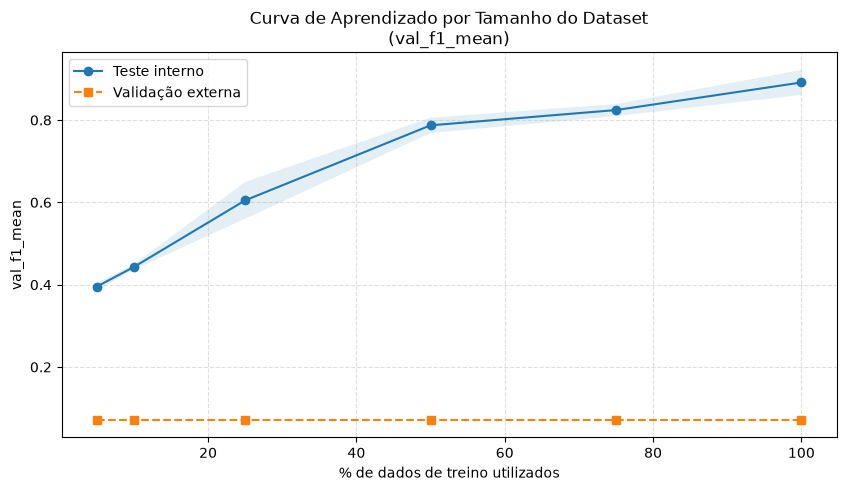

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=voyage__model_type=svdd__pca_dim=300__reducer=pca__strategy=_b280edec/confusion_matrix_evolution.png


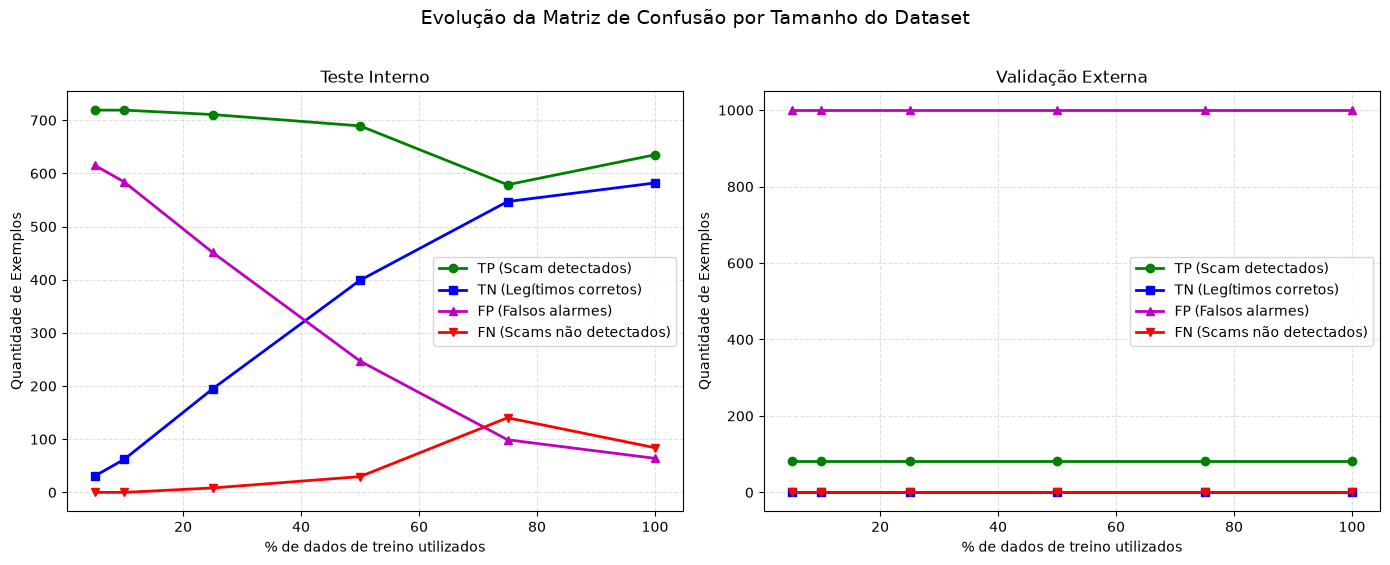

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=voyage__model_type=svdd__pca_dim=300__reducer=pca__strategy=_b280edec/confusion_matrices_by_fraction.png


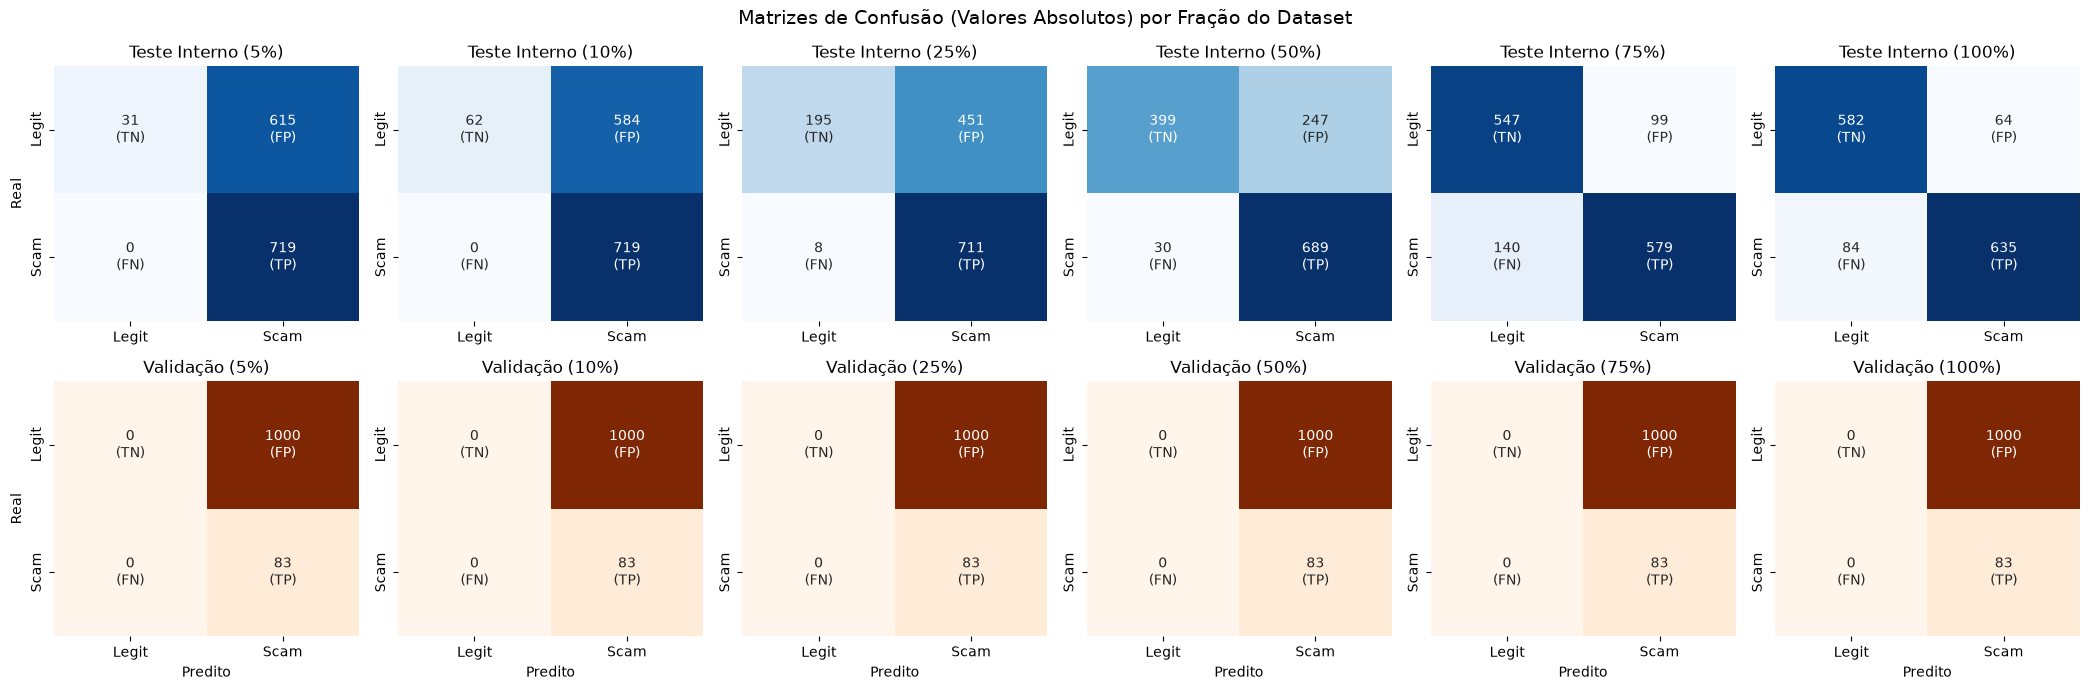


==================== Deep SVDD — OPENAI ====================
[unsupervised_lc] Cache hit — curva de aprendizado
  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=openai__model_type=svdd__pca_dim=300__reducer=pca__strategy=_a37fd142/dataset_size_curve.png


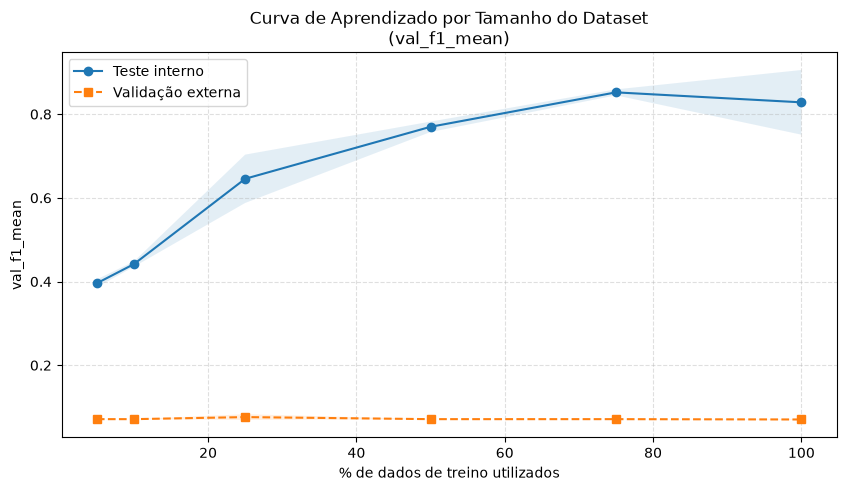

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=openai__model_type=svdd__pca_dim=300__reducer=pca__strategy=_a37fd142/confusion_matrix_evolution.png


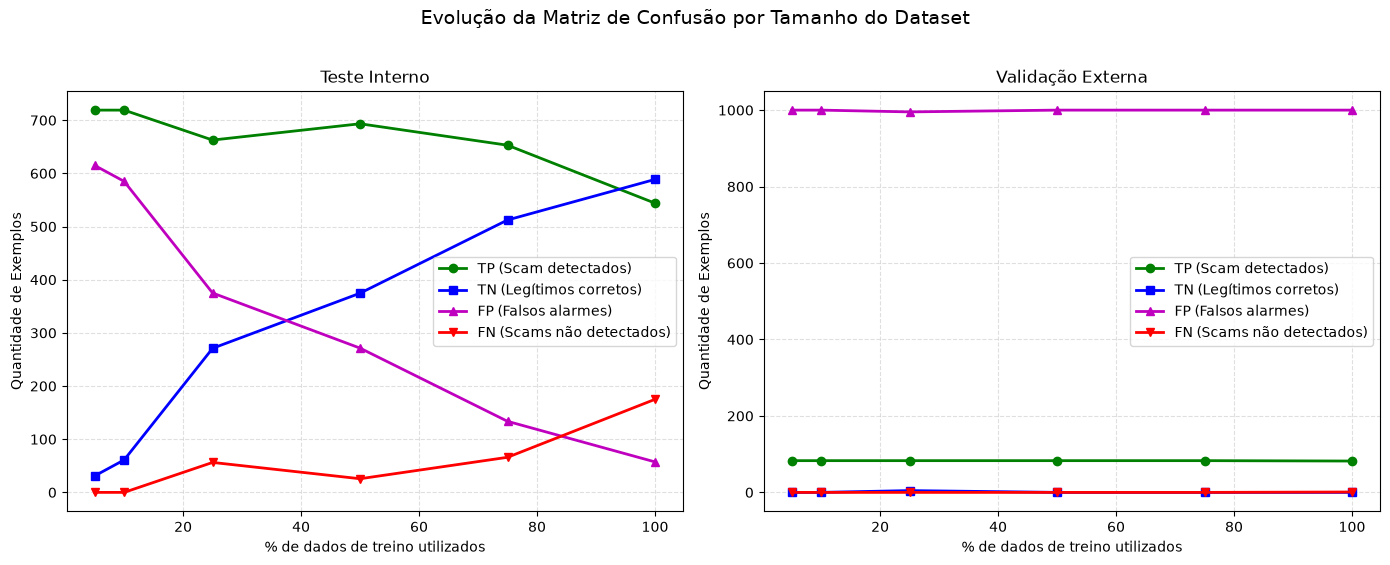

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=openai__model_type=svdd__pca_dim=300__reducer=pca__strategy=_a37fd142/confusion_matrices_by_fraction.png


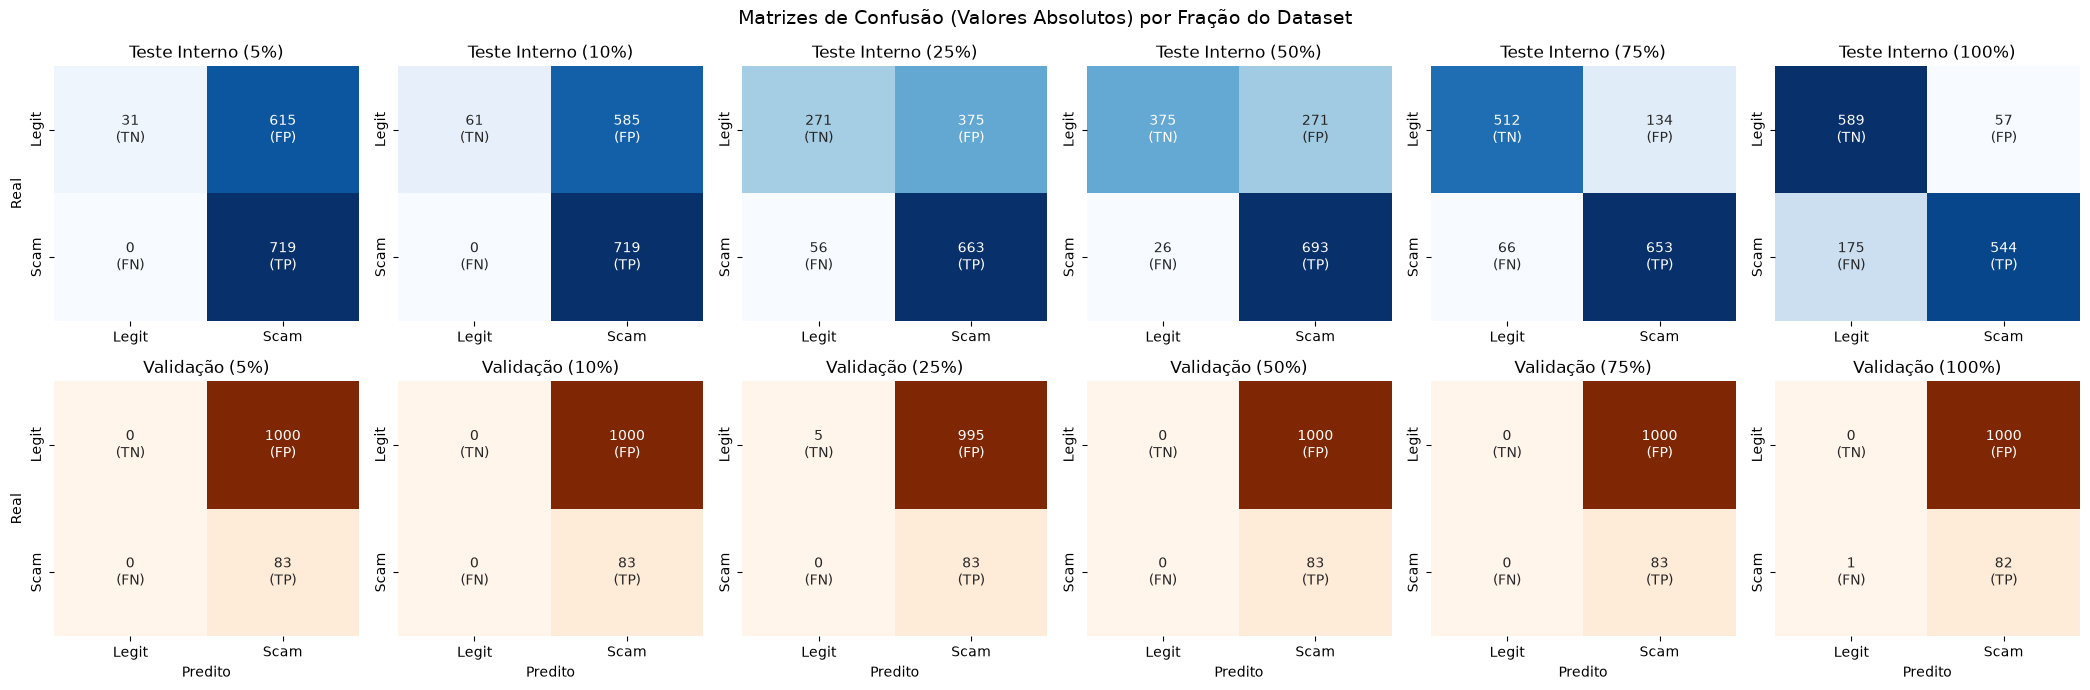


==================== Deep SVDD — BGE ====================
[unsupervised_lc] Cache hit — curva de aprendizado
  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=bge__model_type=svdd__pca_dim=300__reducer=pca__strategy=uns_9e65e905/dataset_size_curve.png


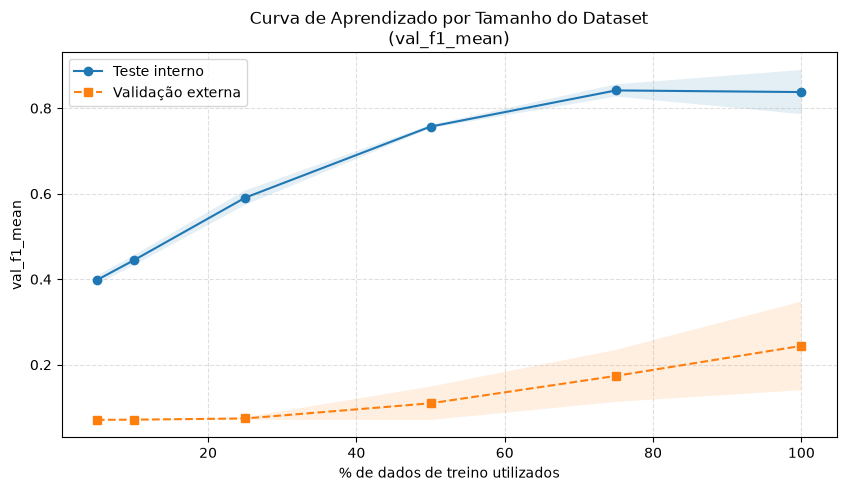

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=bge__model_type=svdd__pca_dim=300__reducer=pca__strategy=uns_9e65e905/confusion_matrix_evolution.png


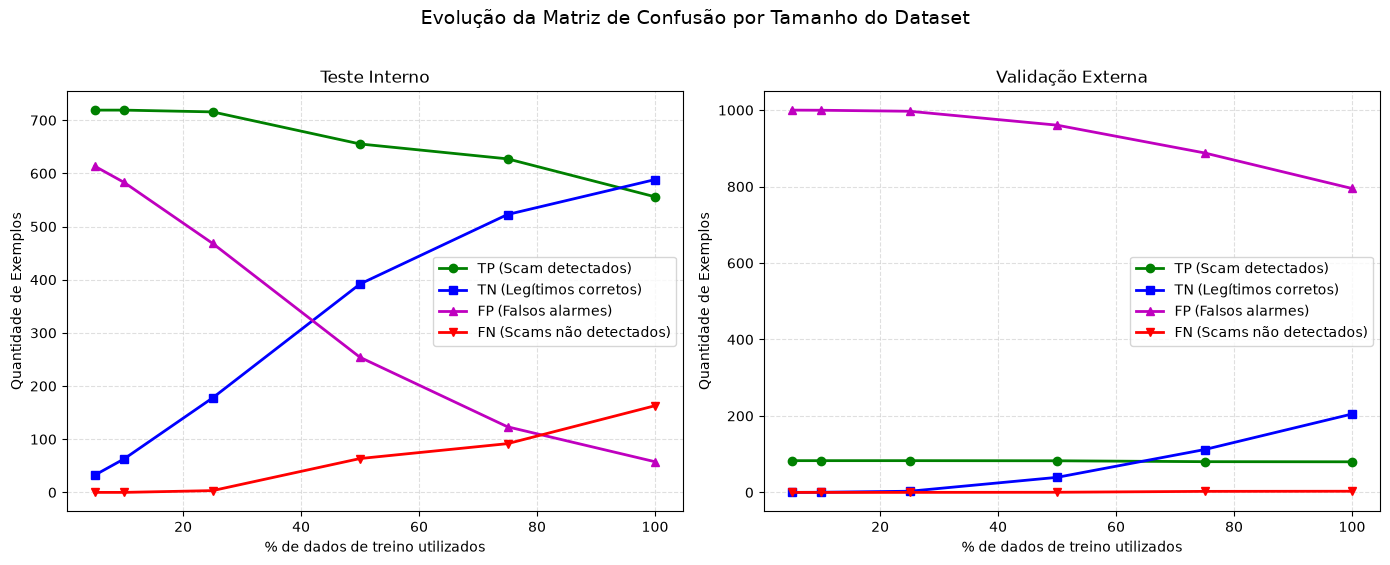

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=bge__model_type=svdd__pca_dim=300__reducer=pca__strategy=uns_9e65e905/confusion_matrices_by_fraction.png


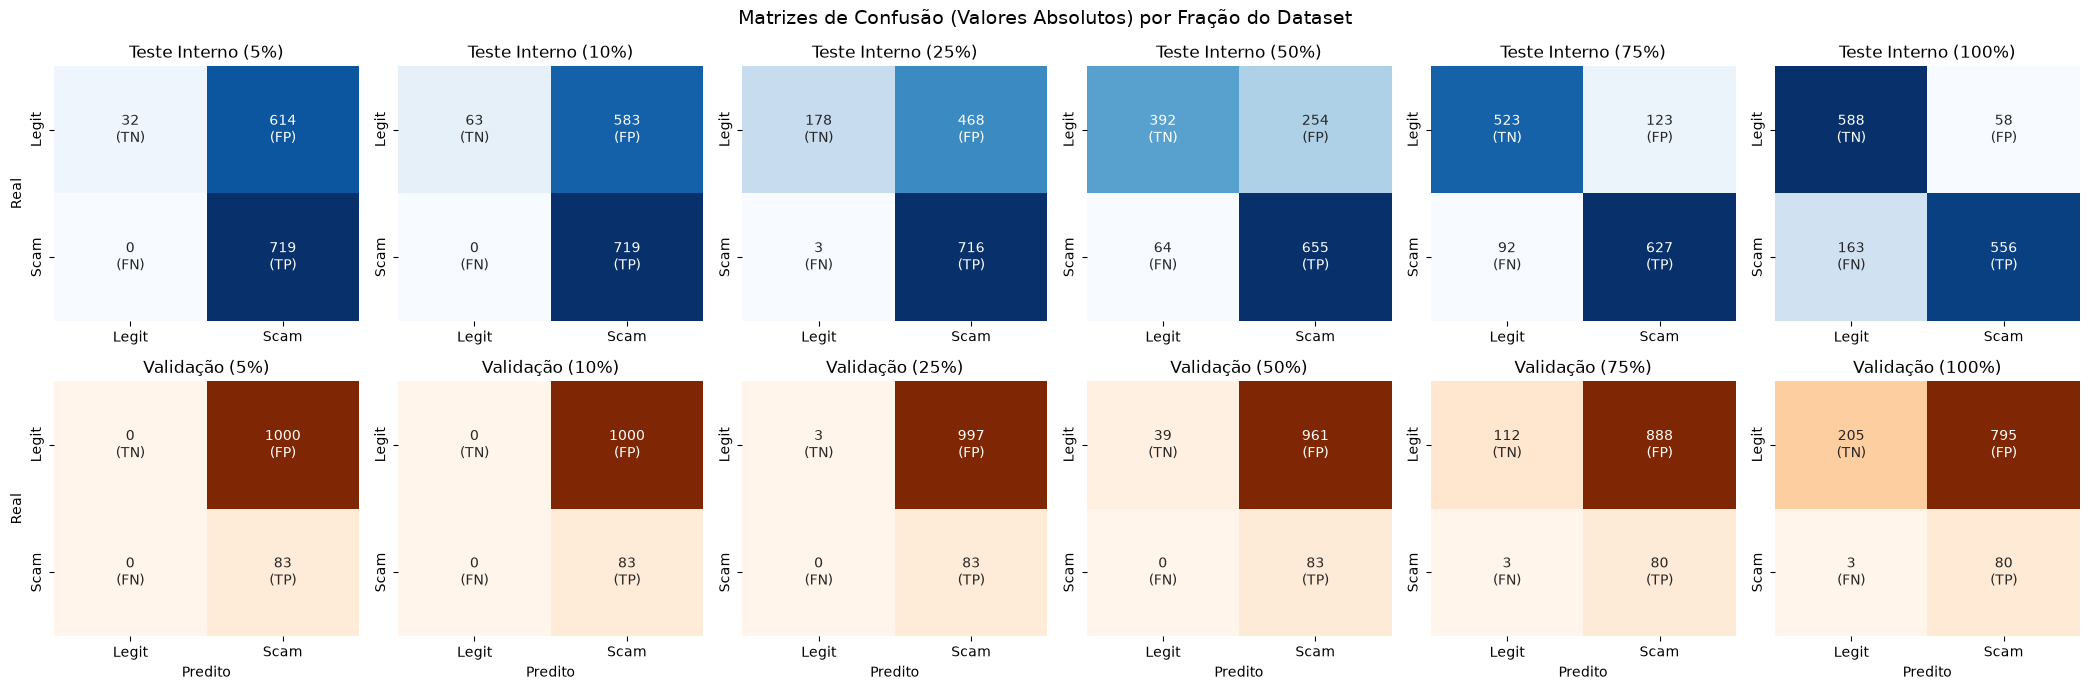


==================== Deep SVDD — E5 ====================
[unsupervised_lc] Cache hit — curva de aprendizado
  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=e5__model_type=svdd__pca_dim=300__reducer=pca__strategy=unsu_91f1ee44/dataset_size_curve.png


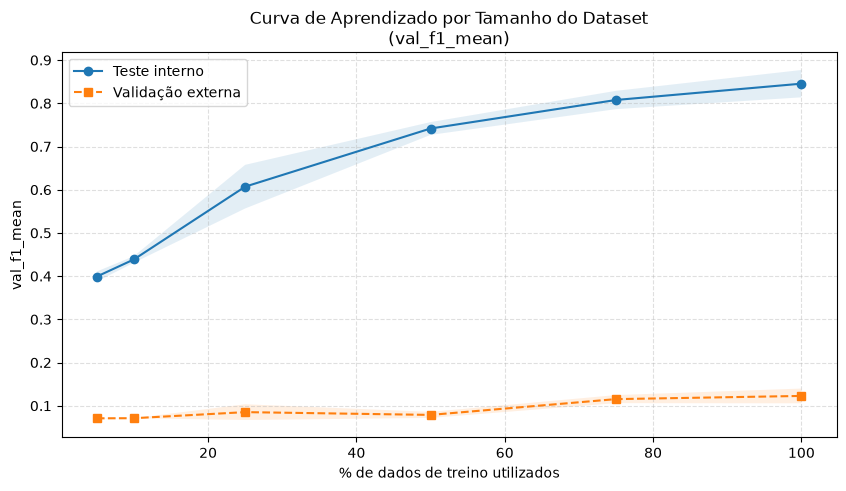

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=e5__model_type=svdd__pca_dim=300__reducer=pca__strategy=unsu_91f1ee44/confusion_matrix_evolution.png


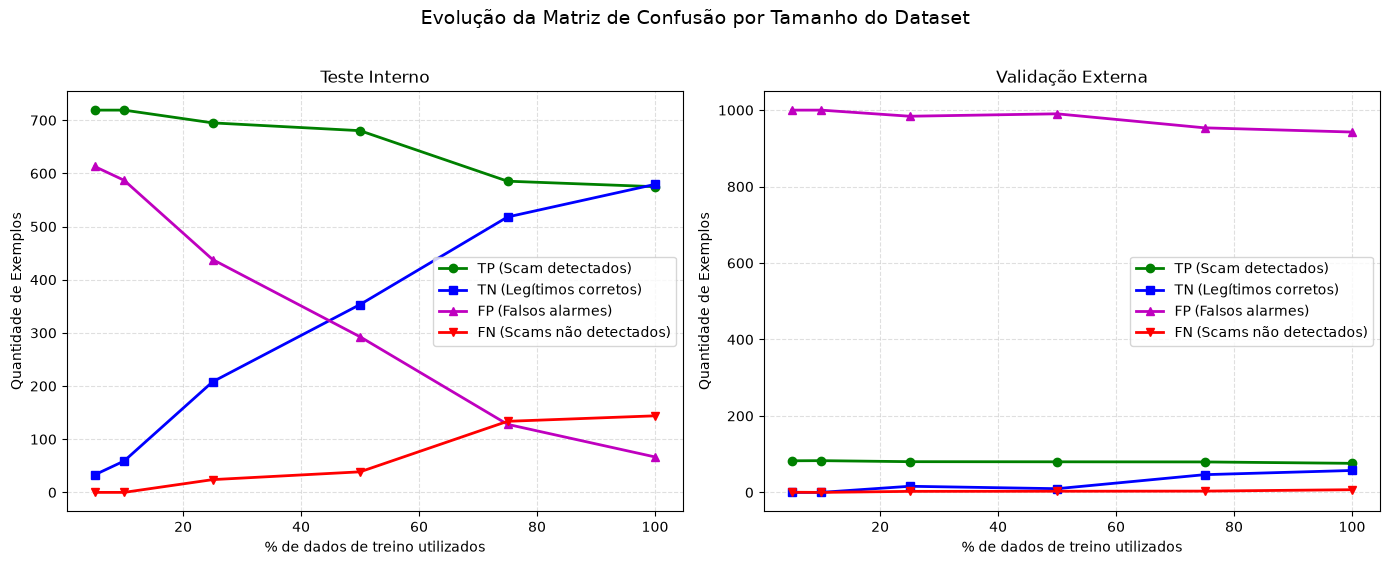

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=e5__model_type=svdd__pca_dim=300__reducer=pca__strategy=unsu_91f1ee44/confusion_matrices_by_fraction.png


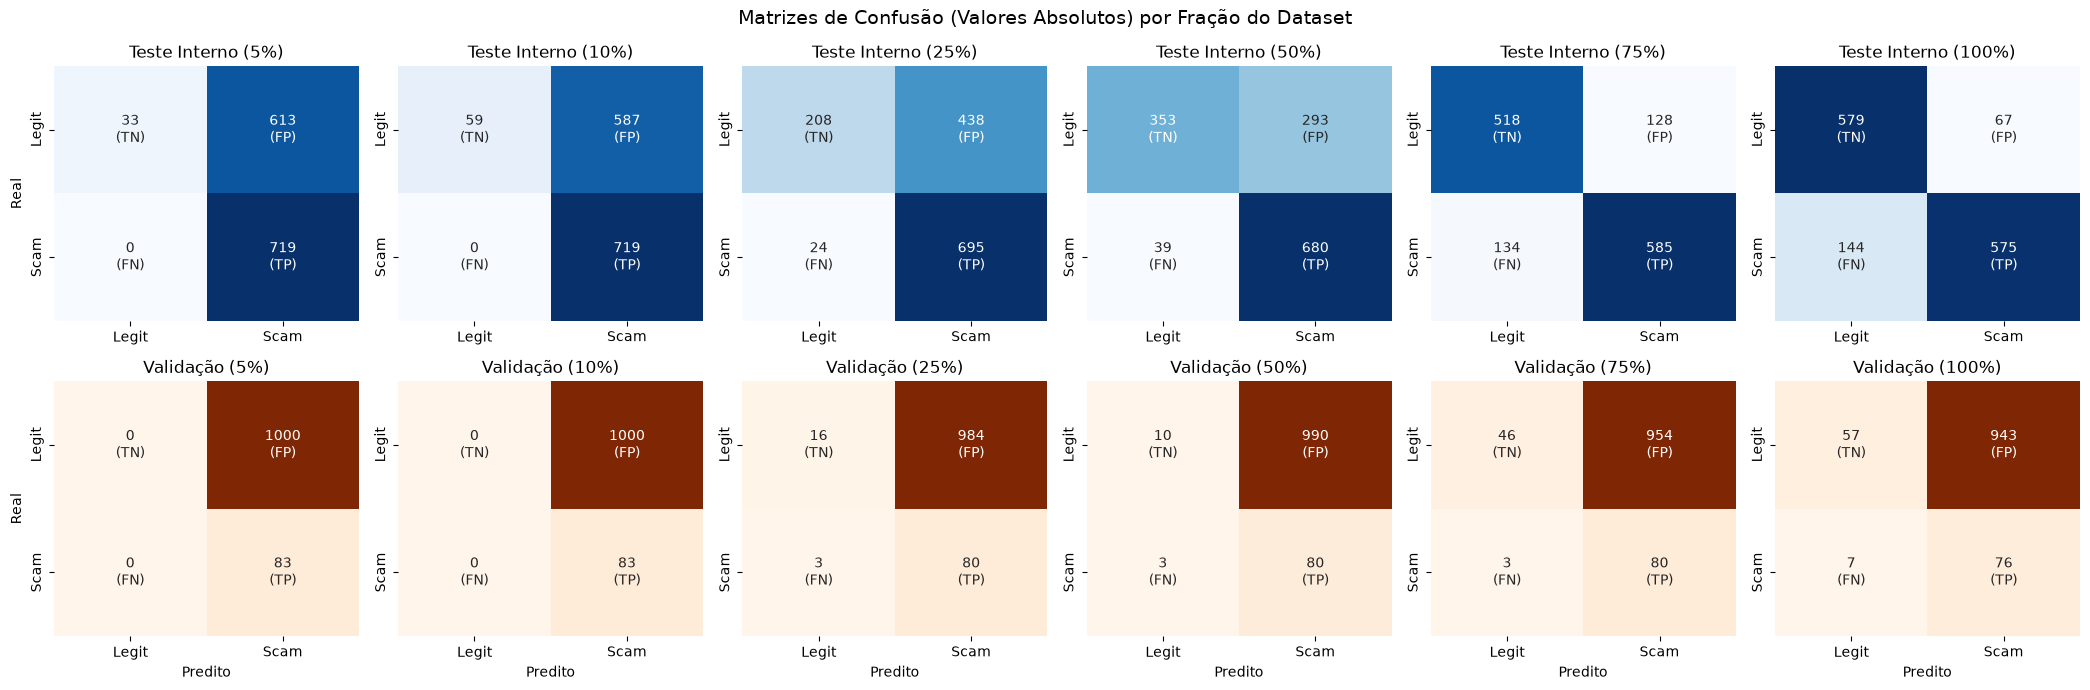


==================== Deep SVDD — MINILM ====================
[unsupervised_lc] Cache hit — curva de aprendizado
  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=minilm__model_type=svdd__pca_dim=300__reducer=pca__strategy=_d88a4fa3/dataset_size_curve.png


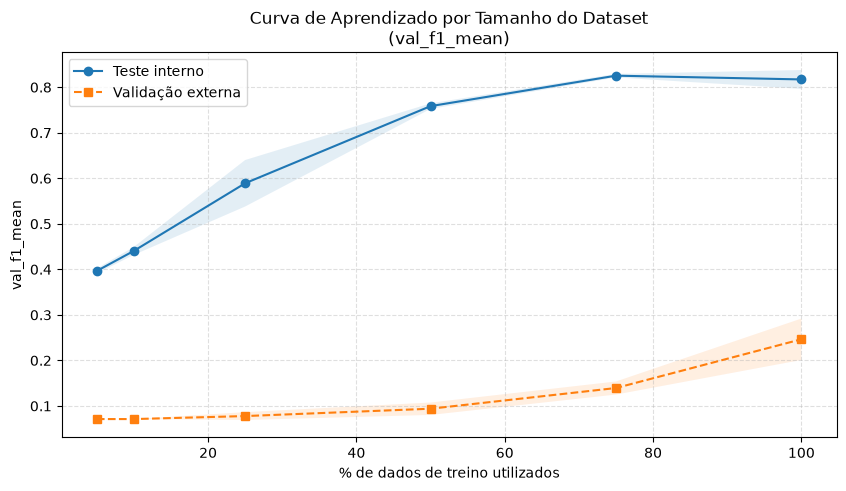

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=minilm__model_type=svdd__pca_dim=300__reducer=pca__strategy=_d88a4fa3/confusion_matrix_evolution.png


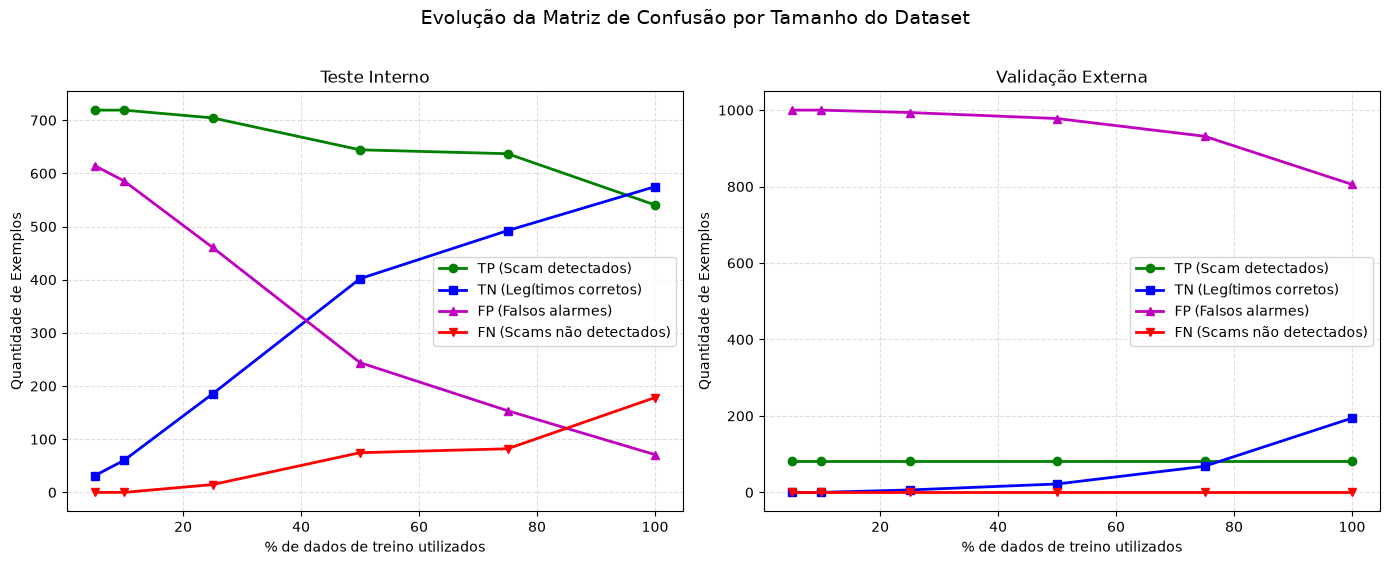

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/lc_embedding=minilm__model_type=svdd__pca_dim=300__reducer=pca__strategy=_d88a4fa3/confusion_matrices_by_fraction.png


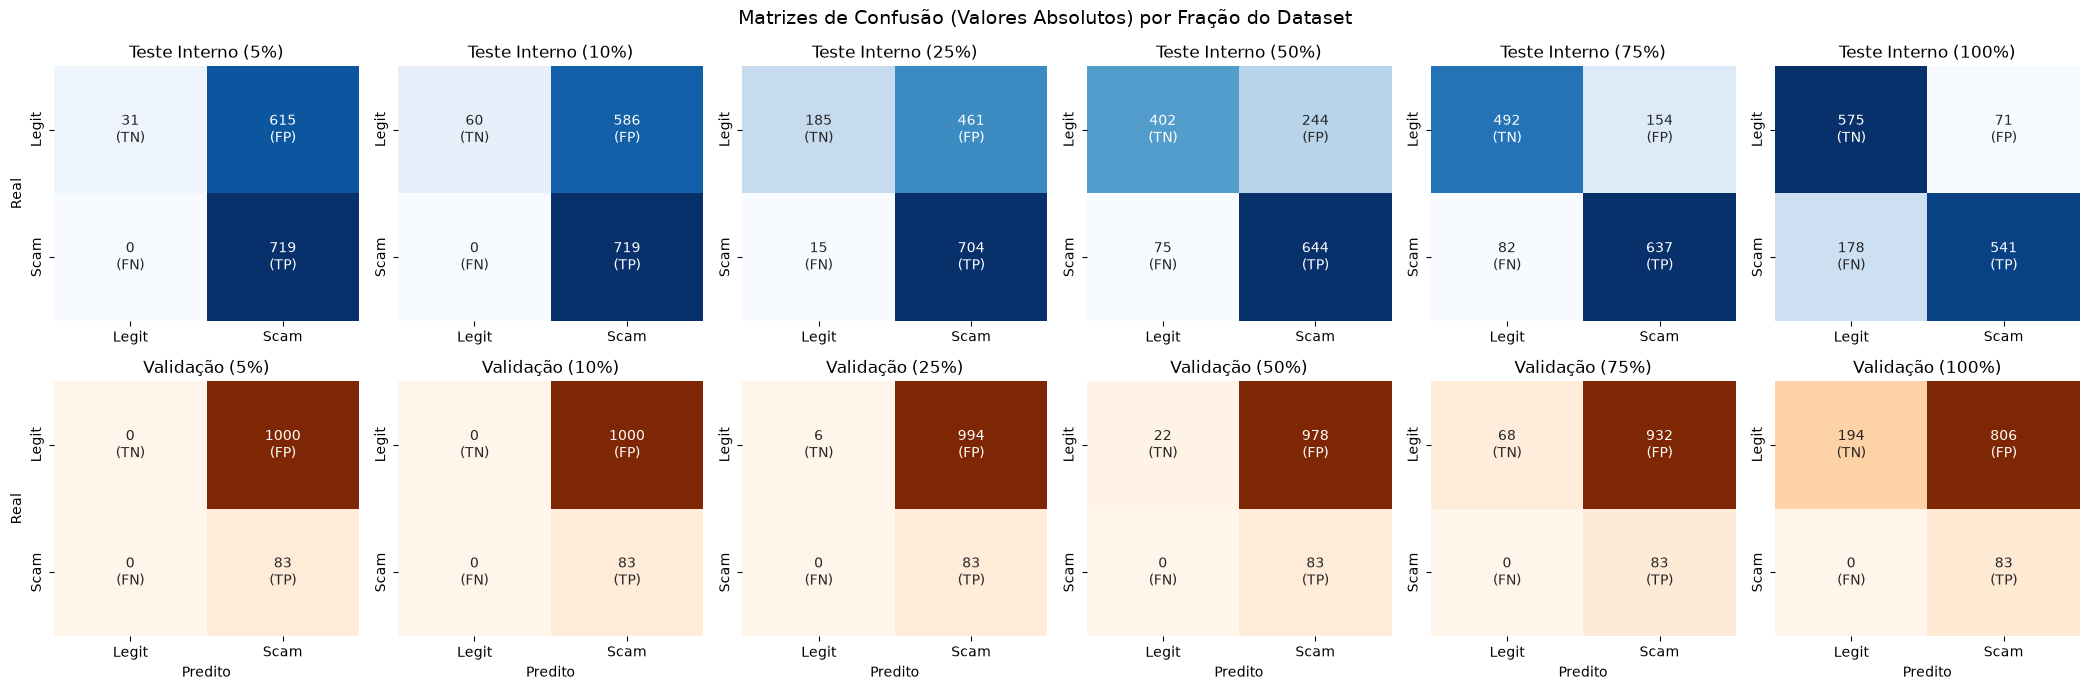

In [25]:
# Curva de aprendizado Deep SVDD para todos os embeddings (mais lento — treina uma rede por fração/repetição)
for emb in EMBEDDINGS:
    print(f"\n==================== Deep SVDD — {emb.upper()} ====================")
    lc = learning_curve_anomaly(
        embedding=emb,
        model_type="svdd",
        pca_dim=300,
        train_sizes=[0.05, 0.10, 0.25, 0.50, 0.75, 1.00],
        n_repeats=3,
    )
    lc.plot_dataset_size_curve(metric="val_f1_mean")
    lc.plot_confusion_matrix_evolution()
    lc.plot_confusion_matrices_by_fraction()


## 10. CVDD


[unsupervised/text] Cache hit: cvdd_bge (params=8455d102)
[cache] Carregando CVDD (texto): bge


/home/andrei.pinto/miniconda3/envs/env_py_3_12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 391/391 [00:00<00:00, 7218.70it/s]


  [text_data] validation: 1083 amostras carregadas de datasets/dataset_validation/raw/all_data.csv
[cache] Métricas salvas: experiment_results/unsupervised/embedding=bge__model_type=cvdd__params=attention_hidden=150_lambda_ort_3814d027/metrics.json
[cache] Predições (validation_external) salvas: experiment_results/unsupervised/embedding=bge__model_type=cvdd__params=attention_hidden=150_lambda_ort_3814d027/predictions_validation_external.npz
=== CVDD (bge, texto bruto) — Métricas train/val/test/validação externa ===


,dataset_name,accuracy,f1_macro,f1_scam,precision_scam,recall_scam,roc_auc,pr_auc,TP,TN,FP,FN
0,validation_external,0.7488,0.4521,0.049,0.0345,0.0843,0.3283,0.0548,7,804,196,76


  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/embedding=bge__model_type=cvdd__params=attention_hidden=150_lambda_ort_3814d027/confusion_matrix.png


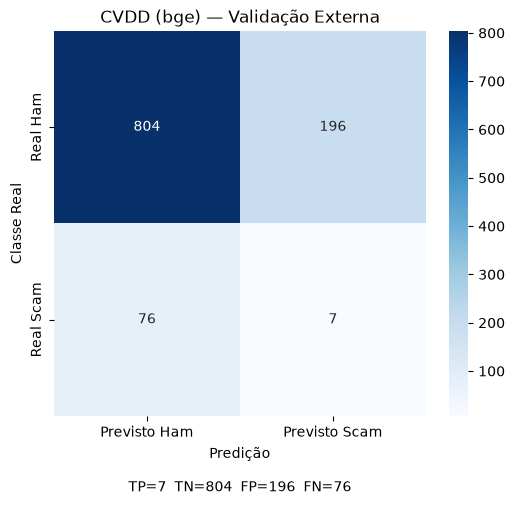

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/embedding=bge__model_type=cvdd__params=attention_hidden=150_lambda_ort_3814d027/roc_curve.png


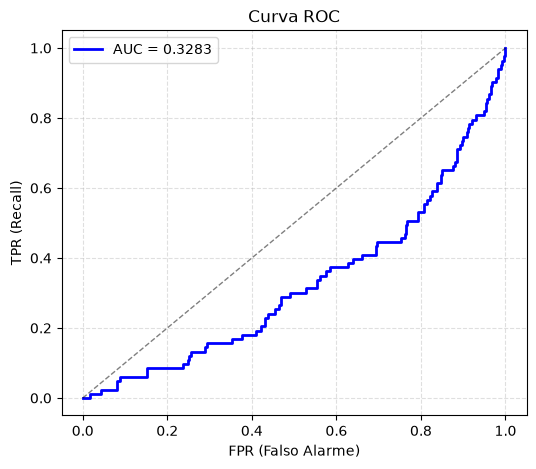

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/unsupervised/embedding=bge__model_type=cvdd__params=attention_hidden=150_lambda_ort_3814d027/pr_curve.png


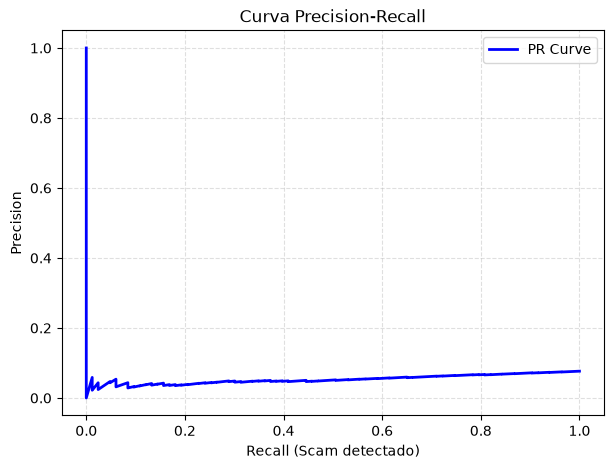

In [2]:
# Treino de CVDD (texto bruto, BGE) — split 3-way (train/val/test) + validação externa
res_cvdd = train_cvdd(n_contexts=10, attention_hidden=150, lambda_ortho=1.0, n_epochs=20, force_retrain=FORCE_RETRAIN)
print("=== CVDD (bge, texto bruto) — Métricas train/val/test/validação externa ===")
display(res_cvdd.df_metrics[[
    "dataset_name", "accuracy", "f1_macro", "f1_scam", "precision_scam", "recall_scam",
    "roc_auc", "pr_auc", "TP", "TN", "FP", "FN",
]])
res_cvdd.plot_confusion_matrix(title="CVDD (bge) — Validação Externa")
res_cvdd.plot_roc_curve()
res_cvdd.plot_precision_recall_curve()


## 11. DATE — Detecting Anomalies via Self-Supervision of Transformers (texto bruto + BGE)

Treina uma tarefa pretexto (classificar qual transformação foi aplicada ao texto) e usa distância de Mahalanobis entre a representação do texto original e as Gaussianas por classe pretexto como score de anomalia (`date_model.py`). Também usa **somente** `bge`. Ver README seção 3.2.

> ⚠️ Mesma limitação do CVDD: sem `grid_search`/`learning_curve` automatizados no momento.


In [3]:
# Treino de DATE (texto bruto, BGE) — split 3-way (train/val/test) + validação externa
res_date = train_date(n_pretext_transforms=5, unfreeze_last_n_layers=2, n_epochs=5, force_retrain=FORCE_RETRAIN)
print("=== DATE (bge, texto bruto) — Métricas train/val/test/validação externa ===")
display(res_date.df_metrics[[
    "dataset_name", "accuracy", "f1_macro", "f1_scam", "precision_scam", "recall_scam",
    "roc_auc", "pr_auc", "TP", "TN", "FP", "FN",
]])
res_date.plot_confusion_matrix(title="DATE (bge) — Validação Externa")
res_date.plot_roc_curve()
res_date.plot_precision_recall_curve()


[unsupervised/text] Cache hit: date_bge (params=825b498f)
[cache] Carregando DATE (texto): bge


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray._reconstruct was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray._reconstruct])` or the `torch.serialization.safe_globals([numpy._core.multiarray._reconstruct])` context manager to allowlist this global if you trust this class/function.

Check the documentation of to

## 12. Comparação Final — Todos os Modelos Unsupervised

Ranking único com os 7 modelos (cada um no seu melhor embedding, exceto CVDD/DATE que usam somente `bge`), usando as métricas na **validação externa** (`dataset_validation` — comportamento esperado em produção/vida real): `accuracy`, `f1_macro`, `f1_scam`, `precision_scam`, `recall_scam`, `roc_auc`, `pr_auc`, `TP`/`TN`/`FP`/`FN`.


In [ ]:
# Monta o leaderboard final: 1 linha por modelo, com a partição "validation_external" de cada `res_*`
_METRIC_COLS = [
    "accuracy", "f1_macro", "f1_scam", "precision_scam", "recall_scam",
    "roc_auc", "pr_auc", "TP", "TN", "FP", "FN",
]

def _external_val_row(result, model_name, embedding):
    row = result.df_metrics[result.df_metrics["dataset_name"] == "validation_external"].iloc[0]
    return {"model": model_name, "embedding": embedding, **{c: row[c] for c in _METRIC_COLS}}

leaderboard = pd.DataFrame([
    _external_val_row(res_ocsvm, "OCSVM", best_emb_ocsvm),
    _external_val_row(res_iforest, "Isolation Forest", best_emb_iforest),
    _external_val_row(res_lof, "LOF", best_emb_lof),
    _external_val_row(res_lunar, "LUNAR", best_emb_lunar),
    _external_val_row(res_svdd, "Deep SVDD", best_emb_svdd),
    _external_val_row(res_cvdd, "CVDD", "bge"),
    _external_val_row(res_date, "DATE", "bge"),
]).sort_values("pr_auc", ascending=False).reset_index(drop=True)

print("=== Leaderboard final (Validação Externa — vida real), ordenado por PR-AUC ===")
display(leaderboard)

In [ ]:
# Comparação visual (barras) das métricas principais entre os 7 modelos, na Validação Externa
fig, axes = plt.subplots(2, 3, figsize=(19, 9.5))
bar_metrics = ["accuracy", "f1_macro", "recall_scam", "precision_scam", "roc_auc", "pr_auc"]
lb_sorted = leaderboard.sort_values("pr_auc", ascending=False)
labels = [f"{m}\n({e})" for m, e in zip(lb_sorted["model"], lb_sorted["embedding"])]

for ax, metric in zip(axes.flat, bar_metrics):
    ax.bar(labels, lb_sorted[metric], color="steelblue")
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)

fig.suptitle("Comparação Final — Modelos Unsupervised (Validação Externa)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Matriz de confusão (contagens absolutas) lado a lado
fig, axes = plt.subplots(1, len(lb_sorted), figsize=(3.5 * len(lb_sorted), 3.5))
for ax, (_, row) in zip(axes, lb_sorted.iterrows()):
    cm = np.array([[row["TN"], row["FP"]], [row["FN"], row["TP"]]])
    im = ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred Ham", "Pred Scam"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Real Ham", "Real Scam"])
    ax.set_title(f"{row['model']}\n({row['embedding']})", fontsize=10)
plt.tight_layout()
plt.show()
